In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections.abc import Callable
import seaborn
from functools import reduce
from contextlib import contextmanager
from operator import getitem
from functools import wraps
from utils.color_palettes import make_alternate_versions as make_color_palettes
from inspect import signature as sig
seaborn.set_style('whitegrid')

# Always run from repo root regardless of notebook location
# _REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
if os.path.basename(os.getcwd()) == "analysis":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from utils.checkpoint_info import get_token_count

@contextmanager
def disable(obj, attr_name):
    temp = getattr(obj, attr_name)
    setattr(obj, attr_name, lambda *a, **kw: None)
    yield
    setattr(obj, attr_name, temp)

@contextmanager
def disable_show():
    temp = plt.show
    plt.show = lambda *a, **kw: None
    yield
    plt.show = temp

def flatten(lst: list):
    return [x for inner in lst for x in inner]

In [2]:
FINEWEB_PADDED = "rankme_fineweb_padded"
TRAINSET_PACKED_UNC_ONLY = "rankme_trainset_packed_unc"
# TRAINSET_PACKED = "rankme_trainset_packed_40M"
TRAINSET_PACKED = "rankme_trainset_packed_4MT"
KF_ARXIV = "kfac_small_arxiv"
KF_SMALL = "kfac_small_shuffled"


In [ ]:
res_cache = {}
res_step_cache = {}
hook_cache = {}

def load_results(dataset_name: str, model_name: str):
    path = os.path.join('results', dataset_name, f'results_{model_name}.npy')
    if path in res_cache:
        return res_cache[path]
    try:
        res = np.load(path, allow_pickle=True).item()
    except FileNotFoundError as e:
        print(f"skipped: {path}", file=sys.stderr)
        return None, None
    step_nums = sorted(res.keys())
    # print(res)
    res_cache[path] = (res, step_nums)
    return res, step_nums

def make_histogram(
    vals: np.ndarray,
    bins: int = 512,
    log_bins: bool = False,
    normalise_as_pdf: bool = True,
) -> np.ndarray:
    edges = (np.logspace(-10, np.log10(vals.max()), bins + 1) if log_bins
             else np.linspace(0, vals.max(), bins + 1))
    h, _ = np.histogram(vals, bins=edges)
    return h / (h.sum() * np.diff(edges)) if normalise_as_pdf else h

def rebin_hist(hist: np.ndarray, bins=None, normalise_as_pdf=True):
    if bins is not None:
        assert not hist.size % bins, "old histogram bincount must be divisible by new histogram bincount"
        hist = hist.reshape(-1,hist.size//bins)
        hist = hist.mean(axis=1) if normalise_as_pdf else hist.sum(axis=1)
    return hist

adjust_hook = {
    "histogram": lambda hist, bins=None: rebin_hist(hist, bins=bins),
    "loghistogram": lambda hist, bins=None: rebin_hist(hist, bins=bins),
}

virtual_hooks = {
    "peak_eigval": (("eigenspectrum", "trace"), (lambda evs, tr: evs[0].item()*tr)),
    "eigvals": (("eigenspectrum", "trace"), (lambda evs, tr: evs*tr)),
    "histogram":    (("eigvals"), (lambda evs, bins=512: make_histogram(evs, bins))),
    "loghistogram": (("eigvals"), (lambda evs, bins=512: make_histogram(evs, bins, log_bins=True))),
}

def get_ys(source_file, model_name, hook, yvar, yvar_kwargs={}):
    hookpath = (*hook, yvar)
    step_nums = None

    cache_id = '\\'.join((source_file, model_name, *hookpath, *yvar_kwargs.keys(), *yvar_kwargs.values()))
    if cache_id in hook_cache:
        return hook_cache[cache_id]

    try:
        res, step_nums = load_results(source_file, model_name)
        if step_nums is None:
            return None, None
        ys = [reduce(getitem, hookpath, res[s]) for s in step_nums]

    except (TypeError, KeyError) as e:
        if step_nums is None: raise e
        if yvar not in virtual_hooks:
            print("broken hook:", hookpath, file=sys.stderr)
            raise e

        required_yvars, hook_transform = virtual_hooks[yvar]
        operands = [get_ys(source_file, model_name, hook, required_yvar)[0] for required_yvar in required_yvars]
        if None in operands:
            return None, None
        ys = [hook_transform(*operands_per_step, **yvar_kwargs) for operands_per_step in zip(*operands)]

    hook_cache[cache_id] = (ys, step_nums)
    return ys, step_nums

# get y but abstracted for only one step, not faster lol, I'm lazy
def get_y(source_file, model_name, hook, yvar, step_num, yvar_kwargs={}):
    ys, step_nums = get_ys(source_file, model_name, hook, yvar, yvar_kwargs)
    if ys is None or step_nums is None: return None
    return ys[step_num] if step_num is not None else ys[step_nums[-1]]

def get_xs_steps(model_name, step_nums):
    return step_nums

def get_xs_tokens(model_name, step_nums):
    return [get_token_count(model_name.split('_')[0], s) for s in step_nums]


def _parse_param_count(model_name):
    """Extract parameter count from model name (e.g. 'pythia-70m' -> 70e6, 'OLMo-2-0425-1B' -> 1e9)."""
    name = model_name.lower()
    if 'pythia' in name:
        size_str = model_name.split('pythia-')[-1].split('-deduped')[0]
    elif 'olmo' in name:
        size_str = model_name.split('-')[-1]
    else:
        raise ValueError(f"Cannot extract param count from {model_name}")
    multiplier = 1e6 if size_str[-1].lower() == 'm' else 1e9
    return float(size_str[:-1]) * multiplier


def get_xs_flops(model_name, step_nums):
    num_params = _parse_param_count(model_name)
    return [num_params * s for s in step_nums]


XVAR_FNS = {
    'steps': get_xs_steps,
    'tokens': get_xs_tokens,
    'flops': get_xs_flops,
}

XVAR_LABELS = {
    'steps': 'Steps',
    'tokens': 'Pretraining tokens',
    'flops': 'Flops',
    'isoflops': 'Parameters',
}

YVAR_LABELS = {
    'alpha': r'$\alpha$',
    'rankme': 'RankMe',
}

base_colors = [
    'turquoise', 'turquoise',
    'cornflowerblue', 'cornflowerblue',
    'lime', 'lime',
    'darkgreen', 'darkgreen',
    'gold', 'gold',
    'dodgerblue', 'dodgerblue',
    'magenta', 'magenta',
    'deeppink', 'deeppink',
    'purple', 'purple',
    'brown', 'brown',
    'blue',
    'red',
]

model_name_options = [
    'pythia-14m', 'pythia-14m-deduped',
    'pythia-31m', 'pythia-31m-deduped',
    'pythia-70m', 'pythia-70m-deduped',
    'pythia-160m', 'pythia-160m-deduped',
    'pythia-410m', 'pythia-410m-deduped',
    'pythia-1b', 'pythia-1b-deduped',
    'pythia-1.4b', 'pythia-1.4b-deduped',
    'pythia-2.8b', 'pythia-2.8b-deduped',
    'pythia-6.9b', 'pythia-6.9b-deduped',
    'pythia-12b', 'pythia-12b-deduped',
    'OLMo-2-0425-1B',
    'OLMo-2-1124-7B',
]

# def get_ls(model_name: str, xvar=None):
#     if xvar == 'isoflops':
#         return '*' if 'deduped' in model_name else 's'

#     ls_exceptions = {'_': '-.', 'deduped': '--'}
#     for substring, ls in ls_exceptions.items():
#         if substring in model_name:
#             return ls
#     return '-'
def get_ls(label: str, xvar: str = None, exceptions: dict = {}):
    ls_exceptions = {'_': '-.', 'uncentered': '--'} | exceptions
    for substring, ls in ls_exceptions.items():
        if substring.lower() in label.lower():
            return ls
    return '-'

def get_model_label(model_name: str):
    parts = model_name.replace('_','-').split('-')

    if parts[0] == 'pythia':
        if len(parts) > 2:
            if parts[2] == 'deduped':
                parts.pop(2)
                parts[1] += 'd'
        parts = [parts[0].capitalize(), parts[1].upper(), *parts[2:]]

    if parts[0] == 'OLMo' and parts[1] == '2':
        parts = ['OLMo-2', parts[3], *parts[4:]]

    return ' '.join(parts)

def make_label(model_name, source_label, label_model, label_source):
    return (
        f'{get_model_label(model_name)}' * label_model
      + f' - '                           * label_model * label_source
      + f'{source_label}'                * label_source
    )


In [ ]:
def plot_model_training(model_name: str, source: tuple[str], xvar: str = 'tokens',
                        yvar: str = 'alpha', color: str = 'k', marker: str = '',
                        label_source: bool = False, label_model: bool = True,
                        alternates: list[str] = [], ls_exceptions: dict = {},
                        yvar_kwargs: dict = {}):
    source_file, hook, source_label, *custom_yvar = source
    if custom_yvar:
        yvar = custom_yvar[0]
    if not isinstance(yvar, str):
        yvar, yvar_kwargs = yvar

    for model_name in [model_name, *(model_name+f'_{alt}' for alt in alternates)]:

        ys, step_nums = get_ys(source_file, model_name, hook, yvar, yvar_kwargs)
        if ys is None:
            continue
        xs = XVAR_FNS[xvar](model_name, step_nums)
        ls = get_ls(source_label+model_name, exceptions=ls_exceptions)

        label = make_label(model_name, source_label, label_model, label_source)
        plt.plot(xs, ys, marker=marker, color=color, ls=ls, lw=3, label=label)

def get_series_y(data_source, model_name, yvar, step, labels):
    yvar_kwargs = {}
    source_file, hook, source_label, *custom_yvar = data_source
    if custom_yvar:
        yvar = custom_yvar[0]
    if not isinstance(yvar, str):
        yvar, yvar_kwargs = yvar
    label = make_label(model_name, source_label, *labels)
    return get_y(source_file, model_name, hook, yvar, step, yvar_kwargs=yvar_kwargs), label

def plot_spectrum_series(series: list[tuple], mode: str = 'line',
                         max_ev: int = None, hist_bins: int = 256,
                         log_bins=False, input_is_bins=False):
    is_hist = mode in ('hist', 'histogram')

    if is_hist and input_is_bins:
        # Already-binned data: plot counts directly against bin indices.
        # No concatenation needed — bins are fixed by the virtual hook.
        for arr, color, label in series:
            plt.bar(np.arange(len(arr)), arr, color=color, label=label, alpha=0.6)
        return

    if is_hist:
        all_vals = np.concatenate([s[0] for s in series])
        if log_bins:
            pos = all_vals[all_vals > 0]
            bin_edges = np.logspace(np.log10(pos.min()), np.log10(pos.max()), hist_bins + 1)
        else:
            bin_edges = np.linspace(all_vals.min(), all_vals.max(), hist_bins + 1)

        for arr, color, label in series:
            plt.hist(arr, bins=bin_edges, color=color, label=label, alpha=0.6)
        return

    for i, (arr, color, label) in enumerate(series):
        xs = np.arange(len(arr))
        if mode == 'line':
            plt.plot(xs, arr, color=color, lw=2, label=label)
        elif mode == 'bar':
            width = 0.8 / len(series)
            offset = (i - len(series) / 2 + 0.5) * width
            plt.bar(xs + offset, arr, width=width, color=color, label=label, alpha=0.8)

_grid = None

def grid_start(ncols=2, figsize=None, title=None, **kwargs):
    global _grid
    _grid = dict(ncols=ncols, figsize=figsize, title=title, extra_kwargs=kwargs, calls=[])

def grid_show():
    global _grid
    calls = _grid['calls']
    ncols = _grid['ncols']
    nrows = (len(calls) + ncols - 1) // ncols
    figsize = _grid['figsize'] or (7 * ncols, 5 * nrows)
    title = _grid['title']
    extra_kwargs = _grid['extra_kwargs']
    _grid = None

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).flatten()
    for i, (func, args, kwargs) in enumerate(calls):
        func(*args, _ax=axes[i], **(extra_kwargs | kwargs))
    for ax in axes[len(calls):]:
        ax.set_visible(False)
    plt.tight_layout()
    if title is not None:
        plt.suptitle(title)
        # fig.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.subplots_adjust(top= 0.984 - (0.10 / nrows))
    # else:
    plt.show()


def griddable(func: Callable):

    @wraps(func)
    def _grid_aux(*args, _ax=None, **kwargs):
        if _ax is None and _grid is not None:
            return _grid['calls'].append((_grid_aux, args, kwargs))
        if _ax is None:
            return func(*args, **kwargs)
        plt.sca(_ax)
        with disable(plt, 'show'):
            return func(*args, **kwargs)

    return _grid_aux

@griddable
def plot_group(
    yvar: str | tuple,
    data_sources: list[str],
    model_names: list[str],
    xvar: str = "tokens",
    xlog: bool = True,
    ylog: bool = False,
    title: str | None = None,
    color_palette: str = "hue_shift",
    color_kwargs: dict = {},
    disable_didx: list = [],
    **kwargs
):
    if color_palette == "hue_shift":
        color_kwargs = dict(shift=0.80/len(data_sources), light_base=0.85) | color_kwargs
    palettes = make_color_palettes(
        base_colors, len(data_sources), method=color_palette, **color_kwargs
    )

    yvarname = yvar if isinstance(yvar, str) else yvar[0]

    for midx, model_name in enumerate(model_names):
        for didx, data_source in enumerate(data_sources):
            if didx in disable_didx:
                continue
            if get_ls(data_source[2]) == '-':
                color = palettes[didx][model_name_options.index(model_name)]
            plot_model_training(model_name, data_source,
                                xvar=xvar, yvar=yvar,
                                color=color,
                                label_source=len(data_sources)>1 or len(model_names) <= 1,
                                label_model=len(model_names)>1,
                                **kwargs)

    if xlog: plt.xscale('log')
    if ylog: plt.yscale('log')
    if title is not None: plt.title(title)
    plt.xlabel(XVAR_LABELS[xvar], fontsize=14)
    plt.ylabel(YVAR_LABELS.get(yvarname, yvarname), fontsize=14)
    plt.legend()


@griddable
def plot_spectrum(
    yvar: str | tuple,
    data_sources: list[str],
    model_names: list[str],
    xlog: bool = False,
    ylog: bool = False,
    mode: str = 'line',
    step: int = None,
    title: str | None = None,
    color_palette: str = "hue_shift",
    color_kwargs: dict = {},
    disable_didx: list = [],
    **kwargs
):
    if color_palette == "hue_shift":
        color_kwargs = dict(shift=0.80/len(data_sources), light_base=0.85) | color_kwargs
    palettes = make_color_palettes(
        base_colors, len(data_sources), method=color_palette, **color_kwargs
    )

    yvarname = yvar if isinstance(yvar, str) else yvar[0]
    labels = len(model_names) > 1, len(data_sources) > 1 or len(model_names) <= 1

    series = []
    for midx, model_name in enumerate(model_names):
        for didx, data_source in enumerate(data_sources):
            if didx in disable_didx: continue
            arr, label = get_series_y(data_source, model_name, yvar, step, labels)
            if arr is None: continue
            color = palettes[didx][model_name_options.index(model_name)]
            series.append((arr, color, label))

    plot_spectrum_series(series, mode=mode, log_bins=xlog, **kwargs)

    if xlog: plt.xscale('log')
    if ylog: plt.yscale('log')
    if title is not None: plt.title(title)
    plt.xlabel('Component index', fontsize=14)
    plt.ylabel(YVAR_LABELS.get(yvarname, yvarname), fontsize=14)
    plt.legend()
    plt.show()


In [11]:
# Collapse this cell

AFN_AC = 'after_final_norm', 'A_centered'
AFN_AU = 'after_final_norm', 'A'
AFN_BC = 'after_final_norm', 'B_centered'
AFN_BU = 'after_final_norm', 'B'
AFN_GC = 'after_final_norm', 'G_centered'
AFN_GU = 'after_final_norm', 'G'
AFN_KF = 'after_final_norm', 'kfac'
BFN_AC = 'before_final_norm', 'A_centered'
BFN_AU = 'before_final_norm', 'A'
BFN_BC = 'before_final_norm', 'B_centered'
BFN_BU = 'before_final_norm', 'B'
BFN_GC = 'before_final_norm', 'G_centered'
BFN_GU = 'before_final_norm', 'G'
BFN_KF = 'before_final_norm', 'kfac'
U0_AC = 'blk0.up', 'A_centered'
U0_AU = 'blk0.up', 'A'
U0_BC = 'blk0.up', 'B_centered'
U0_BU = 'blk0.up', 'B'
U0_GC = 'blk0.up', 'G_centered'
U0_GU = 'blk0.up', 'G'
U0_KF = 'blk0.up', 'kfac'
D0_AC = 'blk0.down', 'A_centered'
D0_AU = 'blk0.down', 'A'
D0_BC = 'blk0.down', 'B_centered'
D0_BU = 'blk0.down', 'B'
D0_GC = 'blk0.down', 'G_centered'
D0_GU = 'blk0.down', 'G'
D0_KF = 'blk0.down', 'kfac'
G0_AC = 'blk0.gate', 'A_centered'
G0_AU = 'blk0.gate', 'A'
G0_BC = 'blk0.gate', 'B_centered'
G0_BU = 'blk0.gate', 'B'
G0_GC = 'blk0.gate', 'G_centered'
G0_GU = 'blk0.gate', 'G'
G0_KF = 'blk0.gate', 'kfac'
L0_AC = 'blk0.layer', 'A_centered'
L0_AU = 'blk0.layer', 'A'
L0_BC = 'blk0.layer', 'B_centered'
L0_BU = 'blk0.layer', 'B'
L0_GC = 'blk0.layer', 'G_centered'
L0_GU = 'blk0.layer', 'G'
L0_KF = 'blk0.layer', 'kfac'
U1_AC = 'blk1.up', 'A_centered'
U1_AU = 'blk1.up', 'A'
U1_BC = 'blk1.up', 'B_centered'
U1_BU = 'blk1.up', 'B'
U1_GC = 'blk1.up', 'G_centered'
U1_GU = 'blk1.up', 'G'
U1_KF = 'blk1.up', 'kfac'
D1_AC = 'blk1.down', 'A_centered'
D1_AU = 'blk1.down', 'A'
D1_BC = 'blk1.down', 'B_centered'
D1_BU = 'blk1.down', 'B'
D1_GC = 'blk1.down', 'G_centered'
D1_GU = 'blk1.down', 'G'
D1_KF = 'blk1.down', 'kfac'
G1_AC = 'blk1.gate', 'A_centered'
G1_AU = 'blk1.gate', 'A'
G1_BC = 'blk1.gate', 'B_centered'
G1_BU = 'blk1.gate', 'B'
G1_GC = 'blk1.gate', 'G_centered'
G1_GU = 'blk1.gate', 'G'
G1_KF = 'blk1.gate', 'kfac'
L1_AC = 'blk1.layer', 'A_centered'
L1_AU = 'blk1.layer', 'A'
L1_BC = 'blk1.layer', 'B_centered'
L1_BU = 'blk1.layer', 'B'
L1_GC = 'blk1.layer', 'G_centered'
L1_GU = 'blk1.layer', 'G'
L1_KF = 'blk1.layer', 'kfac'
U2_AC = 'blk2.up', 'A_centered'
U2_AU = 'blk2.up', 'A'
U2_BC = 'blk2.up', 'B_centered'
U2_BU = 'blk2.up', 'B'
U2_GC = 'blk2.up', 'G_centered'
U2_GU = 'blk2.up', 'G'
U2_KF = 'blk2.up', 'kfac'
D2_AC = 'blk2.down', 'A_centered'
D2_AU = 'blk2.down', 'A'
D2_BC = 'blk2.down', 'B_centered'
D2_BU = 'blk2.down', 'B'
D2_GC = 'blk2.down', 'G_centered'
D2_GU = 'blk2.down', 'G'
D2_KF = 'blk2.down', 'kfac'
G2_AC = 'blk2.gate', 'A_centered'
G2_AU = 'blk2.gate', 'A'
G2_BC = 'blk2.gate', 'B_centered'
G2_BU = 'blk2.gate', 'B'
G2_GC = 'blk2.gate', 'G_centered'
G2_GU = 'blk2.gate', 'G'
G2_KF = 'blk2.gate', 'kfac'
L2_AC = 'blk2.layer', 'A_centered'
L2_AU = 'blk2.layer', 'A'
L2_BC = 'blk2.layer', 'B_centered'
L2_BU = 'blk2.layer', 'B'
L2_GC = 'blk2.layer', 'G_centered'
L2_GU = 'blk2.layer', 'G'
L2_KF = 'blk2.layer', 'kfac'
U3_AC = 'blk3.up', 'A_centered'
U3_AU = 'blk3.up', 'A'
U3_BC = 'blk3.up', 'B_centered'
U3_BU = 'blk3.up', 'B'
U3_GC = 'blk3.up', 'G_centered'
U3_GU = 'blk3.up', 'G'
U3_KF = 'blk3.up', 'kfac'
D3_AC = 'blk3.down', 'A_centered'
D3_AU = 'blk3.down', 'A'
D3_BC = 'blk3.down', 'B_centered'
D3_BU = 'blk3.down', 'B'
D3_GC = 'blk3.down', 'G_centered'
D3_GU = 'blk3.down', 'G'
D3_KF = 'blk3.down', 'kfac'
G3_AC = 'blk3.gate', 'A_centered'
G3_AU = 'blk3.gate', 'A'
G3_BC = 'blk3.gate', 'B_centered'
G3_BU = 'blk3.gate', 'B'
G3_GC = 'blk3.gate', 'G_centered'
G3_GU = 'blk3.gate', 'G'
G3_KF = 'blk3.gate', 'kfac'
L3_AC = 'blk3.layer', 'A_centered'
L3_AU = 'blk3.layer', 'A'
L3_BC = 'blk3.layer', 'B_centered'
L3_BU = 'blk3.layer', 'B'
L3_GC = 'blk3.layer', 'G_centered'
L3_GU = 'blk3.layer', 'G'
L3_KF = 'blk3.layer', 'kfac'
U4_AC = 'blk4.up', 'A_centered'
U4_AU = 'blk4.up', 'A'
U4_BC = 'blk4.up', 'B_centered'
U4_BU = 'blk4.up', 'B'
U4_GC = 'blk4.up', 'G_centered'
U4_GU = 'blk4.up', 'G'
U4_KF = 'blk4.up', 'kfac'
D4_AC = 'blk4.down', 'A_centered'
D4_AU = 'blk4.down', 'A'
D4_BC = 'blk4.down', 'B_centered'
D4_BU = 'blk4.down', 'B'
D4_GC = 'blk4.down', 'G_centered'
D4_GU = 'blk4.down', 'G'
D4_KF = 'blk4.down', 'kfac'
G4_AC = 'blk4.gate', 'A_centered'
G4_AU = 'blk4.gate', 'A'
G4_BC = 'blk4.gate', 'B_centered'
G4_BU = 'blk4.gate', 'B'
G4_GC = 'blk4.gate', 'G_centered'
G4_GU = 'blk4.gate', 'G'
G4_KF = 'blk4.gate', 'kfac'
L4_AC = 'blk4.layer', 'A_centered'
L4_AU = 'blk4.layer', 'A'
L4_BC = 'blk4.layer', 'B_centered'
L4_BU = 'blk4.layer', 'B'
L4_GC = 'blk4.layer', 'G_centered'
L4_GU = 'blk4.layer', 'G'
L4_KF = 'blk4.layer', 'kfac'
U5_AC = 'blk5.up', 'A_centered'
U5_AU = 'blk5.up', 'A'
U5_BC = 'blk5.up', 'B_centered'
U5_BU = 'blk5.up', 'B'
U5_GC = 'blk5.up', 'G_centered'
U5_GU = 'blk5.up', 'G'
U5_KF = 'blk5.up', 'kfac'
D5_AC = 'blk5.down', 'A_centered'
D5_AU = 'blk5.down', 'A'
D5_BC = 'blk5.down', 'B_centered'
D5_BU = 'blk5.down', 'B'
D5_GC = 'blk5.down', 'G_centered'
D5_GU = 'blk5.down', 'G'
D5_KF = 'blk5.down', 'kfac'
G5_AC = 'blk5.gate', 'A_centered'
G5_AU = 'blk5.gate', 'A'
G5_BC = 'blk5.gate', 'B_centered'
G5_BU = 'blk5.gate', 'B'
G5_GC = 'blk5.gate', 'G_centered'
G5_GU = 'blk5.gate', 'G'
G5_KF = 'blk5.gate', 'kfac'
L5_AC = 'blk5.layer', 'A_centered'
L5_AU = 'blk5.layer', 'A'
L5_BC = 'blk5.layer', 'B_centered'
L5_BU = 'blk5.layer', 'B'
L5_GC = 'blk5.layer', 'G_centered'
L5_GU = 'blk5.layer', 'G'
L5_KF = 'blk5.layer', 'kfac'
U6_AC = 'blk6.up', 'A_centered'
U6_AU = 'blk6.up', 'A'
U6_BC = 'blk6.up', 'B_centered'
U6_BU = 'blk6.up', 'B'
U6_GC = 'blk6.up', 'G_centered'
U6_GU = 'blk6.up', 'G'
U6_KF = 'blk6.up', 'kfac'
D6_AC = 'blk6.down', 'A_centered'
D6_AU = 'blk6.down', 'A'
D6_BC = 'blk6.down', 'B_centered'
D6_BU = 'blk6.down', 'B'
D6_GC = 'blk6.down', 'G_centered'
D6_GU = 'blk6.down', 'G'
D6_KF = 'blk6.down', 'kfac'
G6_AC = 'blk6.gate', 'A_centered'
G6_AU = 'blk6.gate', 'A'
G6_BC = 'blk6.gate', 'B_centered'
G6_BU = 'blk6.gate', 'B'
G6_GC = 'blk6.gate', 'G_centered'
G6_GU = 'blk6.gate', 'G'
G6_KF = 'blk6.gate', 'kfac'
L6_AC = 'blk6.layer', 'A_centered'
L6_AU = 'blk6.layer', 'A'
L6_BC = 'blk6.layer', 'B_centered'
L6_BU = 'blk6.layer', 'B'
L6_GC = 'blk6.layer', 'G_centered'
L6_GU = 'blk6.layer', 'G'
L6_KF = 'blk6.layer', 'kfac'
U7_AC = 'blk7.up', 'A_centered'
U7_AU = 'blk7.up', 'A'
U7_BC = 'blk7.up', 'B_centered'
U7_BU = 'blk7.up', 'B'
U7_GC = 'blk7.up', 'G_centered'
U7_GU = 'blk7.up', 'G'
U7_KF = 'blk7.up', 'kfac'
D7_AC = 'blk7.down', 'A_centered'
D7_AU = 'blk7.down', 'A'
D7_BC = 'blk7.down', 'B_centered'
D7_BU = 'blk7.down', 'B'
D7_GC = 'blk7.down', 'G_centered'
D7_GU = 'blk7.down', 'G'
D7_KF = 'blk7.down', 'kfac'
G7_AC = 'blk7.gate', 'A_centered'
G7_AU = 'blk7.gate', 'A'
G7_BC = 'blk7.gate', 'B_centered'
G7_BU = 'blk7.gate', 'B'
G7_GC = 'blk7.gate', 'G_centered'
G7_GU = 'blk7.gate', 'G'
G7_KF = 'blk7.gate', 'kfac'
L7_AC = 'blk7.layer', 'A_centered'
L7_AU = 'blk7.layer', 'A'
L7_BC = 'blk7.layer', 'B_centered'
L7_BU = 'blk7.layer', 'B'
L7_GC = 'blk7.layer', 'G_centered'
L7_GU = 'blk7.layer', 'G'
L7_KF = 'blk7.layer', 'kfac'
U8_AC = 'blk8.up', 'A_centered'
U8_AU = 'blk8.up', 'A'
U8_BC = 'blk8.up', 'B_centered'
U8_BU = 'blk8.up', 'B'
U8_GC = 'blk8.up', 'G_centered'
U8_GU = 'blk8.up', 'G'
U8_KF = 'blk8.up', 'kfac'
D8_AC = 'blk8.down', 'A_centered'
D8_AU = 'blk8.down', 'A'
D8_BC = 'blk8.down', 'B_centered'
D8_BU = 'blk8.down', 'B'
D8_GC = 'blk8.down', 'G_centered'
D8_GU = 'blk8.down', 'G'
D8_KF = 'blk8.down', 'kfac'
G8_AC = 'blk8.gate', 'A_centered'
G8_AU = 'blk8.gate', 'A'
G8_BC = 'blk8.gate', 'B_centered'
G8_BU = 'blk8.gate', 'B'
G8_GC = 'blk8.gate', 'G_centered'
G8_GU = 'blk8.gate', 'G'
G8_KF = 'blk8.gate', 'kfac'
L8_AC = 'blk8.layer', 'A_centered'
L8_AU = 'blk8.layer', 'A'
L8_BC = 'blk8.layer', 'B_centered'
L8_BU = 'blk8.layer', 'B'
L8_GC = 'blk8.layer', 'G_centered'
L8_GU = 'blk8.layer', 'G'
L8_KF = 'blk8.layer', 'kfac'
U9_AC = 'blk9.up', 'A_centered'
U9_AU = 'blk9.up', 'A'
U9_BC = 'blk9.up', 'B_centered'
U9_BU = 'blk9.up', 'B'
U9_GC = 'blk9.up', 'G_centered'
U9_GU = 'blk9.up', 'G'
U9_KF = 'blk9.up', 'kfac'
D9_AC = 'blk9.down', 'A_centered'
D9_AU = 'blk9.down', 'A'
D9_BC = 'blk9.down', 'B_centered'
D9_BU = 'blk9.down', 'B'
D9_GC = 'blk9.down', 'G_centered'
D9_GU = 'blk9.down', 'G'
D9_KF = 'blk9.down', 'kfac'
G9_AC = 'blk9.gate', 'A_centered'
G9_AU = 'blk9.gate', 'A'
G9_BC = 'blk9.gate', 'B_centered'
G9_BU = 'blk9.gate', 'B'
G9_GC = 'blk9.gate', 'G_centered'
G9_GU = 'blk9.gate', 'G'
G9_KF = 'blk9.gate', 'kfac'
L9_AC = 'blk9.layer', 'A_centered'
L9_AU = 'blk9.layer', 'A'
L9_BC = 'blk9.layer', 'B_centered'
L9_BU = 'blk9.layer', 'B'
L9_GC = 'blk9.layer', 'G_centered'
L9_GU = 'blk9.layer', 'G'
L9_KF = 'blk9.layer', 'kfac'
U10_AC = 'blk10.up', 'A_centered'
U10_AU = 'blk10.up', 'A'
U10_BC = 'blk10.up', 'B_centered'
U10_BU = 'blk10.up', 'B'
U10_GC = 'blk10.up', 'G_centered'
U10_GU = 'blk10.up', 'G'
U10_KF = 'blk10.up', 'kfac'
D10_AC = 'blk10.down', 'A_centered'
D10_AU = 'blk10.down', 'A'
D10_BC = 'blk10.down', 'B_centered'
D10_BU = 'blk10.down', 'B'
D10_GC = 'blk10.down', 'G_centered'
D10_GU = 'blk10.down', 'G'
D10_KF = 'blk10.down', 'kfac'
G10_AC = 'blk10.gate', 'A_centered'
G10_AU = 'blk10.gate', 'A'
G10_BC = 'blk10.gate', 'B_centered'
G10_BU = 'blk10.gate', 'B'
G10_GC = 'blk10.gate', 'G_centered'
G10_GU = 'blk10.gate', 'G'
G10_KF = 'blk10.gate', 'kfac'
L10_AC = 'blk10.layer', 'A_centered'
L10_AU = 'blk10.layer', 'A'
L10_BC = 'blk10.layer', 'B_centered'
L10_BU = 'blk10.layer', 'B'
L10_GC = 'blk10.layer', 'G_centered'
L10_GU = 'blk10.layer', 'G'
L10_KF = 'blk10.layer', 'kfac'
U11_AC = 'blk11.up', 'A_centered'
U11_AU = 'blk11.up', 'A'
U11_BC = 'blk11.up', 'B_centered'
U11_BU = 'blk11.up', 'B'
U11_GC = 'blk11.up', 'G_centered'
U11_GU = 'blk11.up', 'G'
U11_KF = 'blk11.up', 'kfac'
D11_AC = 'blk11.down', 'A_centered'
D11_AU = 'blk11.down', 'A'
D11_BC = 'blk11.down', 'B_centered'
D11_BU = 'blk11.down', 'B'
D11_GC = 'blk11.down', 'G_centered'
D11_GU = 'blk11.down', 'G'
D11_KF = 'blk11.down', 'kfac'
G11_AC = 'blk11.gate', 'A_centered'
G11_AU = 'blk11.gate', 'A'
G11_BC = 'blk11.gate', 'B_centered'
G11_BU = 'blk11.gate', 'B'
G11_GC = 'blk11.gate', 'G_centered'
G11_GU = 'blk11.gate', 'G'
G11_KF = 'blk11.gate', 'kfac'
L11_AC = 'blk11.layer', 'A_centered'
L11_AU = 'blk11.layer', 'A'
L11_BC = 'blk11.layer', 'B_centered'
L11_BU = 'blk11.layer', 'B'
L11_GC = 'blk11.layer', 'G_centered'
L11_GU = 'blk11.layer', 'G'
L11_KF = 'blk11.layer', 'kfac'
U12_AC = 'blk12.up', 'A_centered'
U12_AU = 'blk12.up', 'A'
U12_BC = 'blk12.up', 'B_centered'
U12_BU = 'blk12.up', 'B'
U12_GC = 'blk12.up', 'G_centered'
U12_GU = 'blk12.up', 'G'
U12_KF = 'blk12.up', 'kfac'
D12_AC = 'blk12.down', 'A_centered'
D12_AU = 'blk12.down', 'A'
D12_BC = 'blk12.down', 'B_centered'
D12_BU = 'blk12.down', 'B'
D12_GC = 'blk12.down', 'G_centered'
D12_GU = 'blk12.down', 'G'
D12_KF = 'blk12.down', 'kfac'
G12_AC = 'blk12.gate', 'A_centered'
G12_AU = 'blk12.gate', 'A'
G12_BC = 'blk12.gate', 'B_centered'
G12_BU = 'blk12.gate', 'B'
G12_GC = 'blk12.gate', 'G_centered'
G12_GU = 'blk12.gate', 'G'
G12_KF = 'blk12.gate', 'kfac'
L12_AC = 'blk12.layer', 'A_centered'
L12_AU = 'blk12.layer', 'A'
L12_BC = 'blk12.layer', 'B_centered'
L12_BU = 'blk12.layer', 'B'
L12_GC = 'blk12.layer', 'G_centered'
L12_GU = 'blk12.layer', 'G'
L12_KF = 'blk12.layer', 'kfac'
U13_AC = 'blk13.up', 'A_centered'
U13_AU = 'blk13.up', 'A'
U13_BC = 'blk13.up', 'B_centered'
U13_BU = 'blk13.up', 'B'
U13_GC = 'blk13.up', 'G_centered'
U13_GU = 'blk13.up', 'G'
U13_KF = 'blk13.up', 'kfac'
D13_AC = 'blk13.down', 'A_centered'
D13_AU = 'blk13.down', 'A'
D13_BC = 'blk13.down', 'B_centered'
D13_BU = 'blk13.down', 'B'
D13_GC = 'blk13.down', 'G_centered'
D13_GU = 'blk13.down', 'G'
D13_KF = 'blk13.down', 'kfac'
G13_AC = 'blk13.gate', 'A_centered'
G13_AU = 'blk13.gate', 'A'
G13_BC = 'blk13.gate', 'B_centered'
G13_BU = 'blk13.gate', 'B'
G13_GC = 'blk13.gate', 'G_centered'
G13_GU = 'blk13.gate', 'G'
G13_KF = 'blk13.gate', 'kfac'
L13_AC = 'blk13.layer', 'A_centered'
L13_AU = 'blk13.layer', 'A'
L13_BC = 'blk13.layer', 'B_centered'
L13_BU = 'blk13.layer', 'B'
L13_GC = 'blk13.layer', 'G_centered'
L13_GU = 'blk13.layer', 'G'
L13_KF = 'blk13.layer', 'kfac'
U14_AC = 'blk14.up', 'A_centered'
U14_AU = 'blk14.up', 'A'
U14_BC = 'blk14.up', 'B_centered'
U14_BU = 'blk14.up', 'B'
U14_GC = 'blk14.up', 'G_centered'
U14_GU = 'blk14.up', 'G'
U14_KF = 'blk14.up', 'kfac'
D14_AC = 'blk14.down', 'A_centered'
D14_AU = 'blk14.down', 'A'
D14_BC = 'blk14.down', 'B_centered'
D14_BU = 'blk14.down', 'B'
D14_GC = 'blk14.down', 'G_centered'
D14_GU = 'blk14.down', 'G'
D14_KF = 'blk14.down', 'kfac'
G14_AC = 'blk14.gate', 'A_centered'
G14_AU = 'blk14.gate', 'A'
G14_BC = 'blk14.gate', 'B_centered'
G14_BU = 'blk14.gate', 'B'
G14_GC = 'blk14.gate', 'G_centered'
G14_GU = 'blk14.gate', 'G'
G14_KF = 'blk14.gate', 'kfac'
L14_AC = 'blk14.layer', 'A_centered'
L14_AU = 'blk14.layer', 'A'
L14_BC = 'blk14.layer', 'B_centered'
L14_BU = 'blk14.layer', 'B'
L14_GC = 'blk14.layer', 'G_centered'
L14_GU = 'blk14.layer', 'G'
L14_KF = 'blk14.layer', 'kfac'
U15_AC = 'blk15.up', 'A_centered'
U15_AU = 'blk15.up', 'A'
U15_BC = 'blk15.up', 'B_centered'
U15_BU = 'blk15.up', 'B'
U15_GC = 'blk15.up', 'G_centered'
U15_GU = 'blk15.up', 'G'
U15_KF = 'blk15.up', 'kfac'
D15_AC = 'blk15.down', 'A_centered'
D15_AU = 'blk15.down', 'A'
D15_BC = 'blk15.down', 'B_centered'
D15_BU = 'blk15.down', 'B'
D15_GC = 'blk15.down', 'G_centered'
D15_GU = 'blk15.down', 'G'
D15_KF = 'blk15.down', 'kfac'
G15_AC = 'blk15.gate', 'A_centered'
G15_AU = 'blk15.gate', 'A'
G15_BC = 'blk15.gate', 'B_centered'
G15_BU = 'blk15.gate', 'B'
G15_GC = 'blk15.gate', 'G_centered'
G15_GU = 'blk15.gate', 'G'
G15_KF = 'blk15.gate', 'kfac'
L15_AC = 'blk15.layer', 'A_centered'
L15_AU = 'blk15.layer', 'A'
L15_BC = 'blk15.layer', 'B_centered'
L15_BU = 'blk15.layer', 'B'
L15_GC = 'blk15.layer', 'G_centered'
L15_GU = 'blk15.layer', 'G'
L15_KF = 'blk15.layer', 'kfac'
U16_AC = 'blk16.up', 'A_centered'
U16_AU = 'blk16.up', 'A'
U16_BC = 'blk16.up', 'B_centered'
U16_BU = 'blk16.up', 'B'
U16_GC = 'blk16.up', 'G_centered'
U16_GU = 'blk16.up', 'G'
U16_KF = 'blk16.up', 'kfac'
D16_AC = 'blk16.down', 'A_centered'
D16_AU = 'blk16.down', 'A'
D16_BC = 'blk16.down', 'B_centered'
D16_BU = 'blk16.down', 'B'
D16_GC = 'blk16.down', 'G_centered'
D16_GU = 'blk16.down', 'G'
D16_KF = 'blk16.down', 'kfac'
G16_AC = 'blk16.gate', 'A_centered'
G16_AU = 'blk16.gate', 'A'
G16_BC = 'blk16.gate', 'B_centered'
G16_BU = 'blk16.gate', 'B'
G16_GC = 'blk16.gate', 'G_centered'
G16_GU = 'blk16.gate', 'G'
G16_KF = 'blk16.gate', 'kfac'
L16_AC = 'blk16.layer', 'A_centered'
L16_AU = 'blk16.layer', 'A'
L16_BC = 'blk16.layer', 'B_centered'
L16_BU = 'blk16.layer', 'B'
L16_GC = 'blk16.layer', 'G_centered'
L16_GU = 'blk16.layer', 'G'
L16_KF = 'blk16.layer', 'kfac'
U17_AC = 'blk17.up', 'A_centered'
U17_AU = 'blk17.up', 'A'
U17_BC = 'blk17.up', 'B_centered'
U17_BU = 'blk17.up', 'B'
U17_GC = 'blk17.up', 'G_centered'
U17_GU = 'blk17.up', 'G'
U17_KF = 'blk17.up', 'kfac'
D17_AC = 'blk17.down', 'A_centered'
D17_AU = 'blk17.down', 'A'
D17_BC = 'blk17.down', 'B_centered'
D17_BU = 'blk17.down', 'B'
D17_GC = 'blk17.down', 'G_centered'
D17_GU = 'blk17.down', 'G'
D17_KF = 'blk17.down', 'kfac'
G17_AC = 'blk17.gate', 'A_centered'
G17_AU = 'blk17.gate', 'A'
G17_BC = 'blk17.gate', 'B_centered'
G17_BU = 'blk17.gate', 'B'
G17_GC = 'blk17.gate', 'G_centered'
G17_GU = 'blk17.gate', 'G'
G17_KF = 'blk17.gate', 'kfac'
L17_AC = 'blk17.layer', 'A_centered'
L17_AU = 'blk17.layer', 'A'
L17_BC = 'blk17.layer', 'B_centered'
L17_BU = 'blk17.layer', 'B'
L17_GC = 'blk17.layer', 'G_centered'
L17_GU = 'blk17.layer', 'G'
L17_KF = 'blk17.layer', 'kfac'
U18_AC = 'blk18.up', 'A_centered'
U18_AU = 'blk18.up', 'A'
U18_BC = 'blk18.up', 'B_centered'
U18_BU = 'blk18.up', 'B'
U18_GC = 'blk18.up', 'G_centered'
U18_GU = 'blk18.up', 'G'
U18_KF = 'blk18.up', 'kfac'
D18_AC = 'blk18.down', 'A_centered'
D18_AU = 'blk18.down', 'A'
D18_BC = 'blk18.down', 'B_centered'
D18_BU = 'blk18.down', 'B'
D18_GC = 'blk18.down', 'G_centered'
D18_GU = 'blk18.down', 'G'
D18_KF = 'blk18.down', 'kfac'
G18_AC = 'blk18.gate', 'A_centered'
G18_AU = 'blk18.gate', 'A'
G18_BC = 'blk18.gate', 'B_centered'
G18_BU = 'blk18.gate', 'B'
G18_GC = 'blk18.gate', 'G_centered'
G18_GU = 'blk18.gate', 'G'
G18_KF = 'blk18.gate', 'kfac'
L18_AC = 'blk18.layer', 'A_centered'
L18_AU = 'blk18.layer', 'A'
L18_BC = 'blk18.layer', 'B_centered'
L18_BU = 'blk18.layer', 'B'
L18_GC = 'blk18.layer', 'G_centered'
L18_GU = 'blk18.layer', 'G'
L18_KF = 'blk18.layer', 'kfac'
U19_AC = 'blk19.up', 'A_centered'
U19_AU = 'blk19.up', 'A'
U19_BC = 'blk19.up', 'B_centered'
U19_BU = 'blk19.up', 'B'
U19_GC = 'blk19.up', 'G_centered'
U19_GU = 'blk19.up', 'G'
U19_KF = 'blk19.up', 'kfac'
D19_AC = 'blk19.down', 'A_centered'
D19_AU = 'blk19.down', 'A'
D19_BC = 'blk19.down', 'B_centered'
D19_BU = 'blk19.down', 'B'
D19_GC = 'blk19.down', 'G_centered'
D19_GU = 'blk19.down', 'G'
D19_KF = 'blk19.down', 'kfac'
G19_AC = 'blk19.gate', 'A_centered'
G19_AU = 'blk19.gate', 'A'
G19_BC = 'blk19.gate', 'B_centered'
G19_BU = 'blk19.gate', 'B'
G19_GC = 'blk19.gate', 'G_centered'
G19_GU = 'blk19.gate', 'G'
G19_KF = 'blk19.gate', 'kfac'
L19_AC = 'blk19.layer', 'A_centered'
L19_AU = 'blk19.layer', 'A'
L19_BC = 'blk19.layer', 'B_centered'
L19_BU = 'blk19.layer', 'B'
L19_GC = 'blk19.layer', 'G_centered'
L19_GU = 'blk19.layer', 'G'
L19_KF = 'blk19.layer', 'kfac'
U20_AC = 'blk20.up', 'A_centered'
U20_AU = 'blk20.up', 'A'
U20_BC = 'blk20.up', 'B_centered'
U20_BU = 'blk20.up', 'B'
U20_GC = 'blk20.up', 'G_centered'
U20_GU = 'blk20.up', 'G'
U20_KF = 'blk20.up', 'kfac'
D20_AC = 'blk20.down', 'A_centered'
D20_AU = 'blk20.down', 'A'
D20_BC = 'blk20.down', 'B_centered'
D20_BU = 'blk20.down', 'B'
D20_GC = 'blk20.down', 'G_centered'
D20_GU = 'blk20.down', 'G'
D20_KF = 'blk20.down', 'kfac'
G20_AC = 'blk20.gate', 'A_centered'
G20_AU = 'blk20.gate', 'A'
G20_BC = 'blk20.gate', 'B_centered'
G20_BU = 'blk20.gate', 'B'
G20_GC = 'blk20.gate', 'G_centered'
G20_GU = 'blk20.gate', 'G'
G20_KF = 'blk20.gate', 'kfac'
L20_AC = 'blk20.layer', 'A_centered'
L20_AU = 'blk20.layer', 'A'
L20_BC = 'blk20.layer', 'B_centered'
L20_BU = 'blk20.layer', 'B'
L20_GC = 'blk20.layer', 'G_centered'
L20_GU = 'blk20.layer', 'G'
L20_KF = 'blk20.layer', 'kfac'
U21_AC = 'blk21.up', 'A_centered'
U21_AU = 'blk21.up', 'A'
U21_BC = 'blk21.up', 'B_centered'
U21_BU = 'blk21.up', 'B'
U21_GC = 'blk21.up', 'G_centered'
U21_GU = 'blk21.up', 'G'
U21_KF = 'blk21.up', 'kfac'
D21_AC = 'blk21.down', 'A_centered'
D21_AU = 'blk21.down', 'A'
D21_BC = 'blk21.down', 'B_centered'
D21_BU = 'blk21.down', 'B'
D21_GC = 'blk21.down', 'G_centered'
D21_GU = 'blk21.down', 'G'
D21_KF = 'blk21.down', 'kfac'
G21_AC = 'blk21.gate', 'A_centered'
G21_AU = 'blk21.gate', 'A'
G21_BC = 'blk21.gate', 'B_centered'
G21_BU = 'blk21.gate', 'B'
G21_GC = 'blk21.gate', 'G_centered'
G21_GU = 'blk21.gate', 'G'
G21_KF = 'blk21.gate', 'kfac'
L21_AC = 'blk21.layer', 'A_centered'
L21_AU = 'blk21.layer', 'A'
L21_BC = 'blk21.layer', 'B_centered'
L21_BU = 'blk21.layer', 'B'
L21_GC = 'blk21.layer', 'G_centered'
L21_GU = 'blk21.layer', 'G'
L21_KF = 'blk21.layer', 'kfac'
U22_AC = 'blk22.up', 'A_centered'
U22_AU = 'blk22.up', 'A'
U22_BC = 'blk22.up', 'B_centered'
U22_BU = 'blk22.up', 'B'
U22_GC = 'blk22.up', 'G_centered'
U22_GU = 'blk22.up', 'G'
U22_KF = 'blk22.up', 'kfac'
D22_AC = 'blk22.down', 'A_centered'
D22_AU = 'blk22.down', 'A'
D22_BC = 'blk22.down', 'B_centered'
D22_BU = 'blk22.down', 'B'
D22_GC = 'blk22.down', 'G_centered'
D22_GU = 'blk22.down', 'G'
D22_KF = 'blk22.down', 'kfac'
G22_AC = 'blk22.gate', 'A_centered'
G22_AU = 'blk22.gate', 'A'
G22_BC = 'blk22.gate', 'B_centered'
G22_BU = 'blk22.gate', 'B'
G22_GC = 'blk22.gate', 'G_centered'
G22_GU = 'blk22.gate', 'G'
G22_KF = 'blk22.gate', 'kfac'
L22_AC = 'blk22.layer', 'A_centered'
L22_AU = 'blk22.layer', 'A'
L22_BC = 'blk22.layer', 'B_centered'
L22_BU = 'blk22.layer', 'B'
L22_GC = 'blk22.layer', 'G_centered'
L22_GU = 'blk22.layer', 'G'
L22_KF = 'blk22.layer', 'kfac'
U23_AC = 'blk23.up', 'A_centered'
U23_AU = 'blk23.up', 'A'
U23_BC = 'blk23.up', 'B_centered'
U23_BU = 'blk23.up', 'B'
U23_GC = 'blk23.up', 'G_centered'
U23_GU = 'blk23.up', 'G'
U23_KF = 'blk23.up', 'kfac'
D23_AC = 'blk23.down', 'A_centered'
D23_AU = 'blk23.down', 'A'
D23_BC = 'blk23.down', 'B_centered'
D23_BU = 'blk23.down', 'B'
D23_GC = 'blk23.down', 'G_centered'
D23_GU = 'blk23.down', 'G'
D23_KF = 'blk23.down', 'kfac'
G23_AC = 'blk23.gate', 'A_centered'
G23_AU = 'blk23.gate', 'A'
G23_BC = 'blk23.gate', 'B_centered'
G23_BU = 'blk23.gate', 'B'
G23_GC = 'blk23.gate', 'G_centered'
G23_GU = 'blk23.gate', 'G'
G23_KF = 'blk23.gate', 'kfac'
L23_AC = 'blk23.layer', 'A_centered'
L23_AU = 'blk23.layer', 'A'
L23_BC = 'blk23.layer', 'B_centered'
L23_BU = 'blk23.layer', 'B'
L23_GC = 'blk23.layer', 'G_centered'
L23_GU = 'blk23.layer', 'G'
L23_KF = 'blk23.layer', 'kfac'
U24_AC = 'blk24.up', 'A_centered'
U24_AU = 'blk24.up', 'A'
U24_BC = 'blk24.up', 'B_centered'
U24_BU = 'blk24.up', 'B'
U24_GC = 'blk24.up', 'G_centered'
U24_GU = 'blk24.up', 'G'
U24_KF = 'blk24.up', 'kfac'
D24_AC = 'blk24.down', 'A_centered'
D24_AU = 'blk24.down', 'A'
D24_BC = 'blk24.down', 'B_centered'
D24_BU = 'blk24.down', 'B'
D24_GC = 'blk24.down', 'G_centered'
D24_GU = 'blk24.down', 'G'
D24_KF = 'blk24.down', 'kfac'
G24_AC = 'blk24.gate', 'A_centered'
G24_AU = 'blk24.gate', 'A'
G24_BC = 'blk24.gate', 'B_centered'
G24_BU = 'blk24.gate', 'B'
G24_GC = 'blk24.gate', 'G_centered'
G24_GU = 'blk24.gate', 'G'
G24_KF = 'blk24.gate', 'kfac'
L24_AC = 'blk24.layer', 'A_centered'
L24_AU = 'blk24.layer', 'A'
L24_BC = 'blk24.layer', 'B_centered'
L24_BU = 'blk24.layer', 'B'
L24_GC = 'blk24.layer', 'G_centered'
L24_GU = 'blk24.layer', 'G'
L24_KF = 'blk24.layer', 'kfac'
U25_AC = 'blk25.up', 'A_centered'
U25_AU = 'blk25.up', 'A'
U25_BC = 'blk25.up', 'B_centered'
U25_BU = 'blk25.up', 'B'
U25_GC = 'blk25.up', 'G_centered'
U25_GU = 'blk25.up', 'G'
U25_KF = 'blk25.up', 'kfac'
D25_AC = 'blk25.down', 'A_centered'
D25_AU = 'blk25.down', 'A'
D25_BC = 'blk25.down', 'B_centered'
D25_BU = 'blk25.down', 'B'
D25_GC = 'blk25.down', 'G_centered'
D25_GU = 'blk25.down', 'G'
D25_KF = 'blk25.down', 'kfac'
G25_AC = 'blk25.gate', 'A_centered'
G25_AU = 'blk25.gate', 'A'
G25_BC = 'blk25.gate', 'B_centered'
G25_BU = 'blk25.gate', 'B'
G25_GC = 'blk25.gate', 'G_centered'
G25_GU = 'blk25.gate', 'G'
G25_KF = 'blk25.gate', 'kfac'
L25_AC = 'blk25.layer', 'A_centered'
L25_AU = 'blk25.layer', 'A'
L25_BC = 'blk25.layer', 'B_centered'
L25_BU = 'blk25.layer', 'B'
L25_GC = 'blk25.layer', 'G_centered'
L25_GU = 'blk25.layer', 'G'
L25_KF = 'blk25.layer', 'kfac'
U26_AC = 'blk26.up', 'A_centered'
U26_AU = 'blk26.up', 'A'
U26_BC = 'blk26.up', 'B_centered'
U26_BU = 'blk26.up', 'B'
U26_GC = 'blk26.up', 'G_centered'
U26_GU = 'blk26.up', 'G'
U26_KF = 'blk26.up', 'kfac'
D26_AC = 'blk26.down', 'A_centered'
D26_AU = 'blk26.down', 'A'
D26_BC = 'blk26.down', 'B_centered'
D26_BU = 'blk26.down', 'B'
D26_GC = 'blk26.down', 'G_centered'
D26_GU = 'blk26.down', 'G'
D26_KF = 'blk26.down', 'kfac'
G26_AC = 'blk26.gate', 'A_centered'
G26_AU = 'blk26.gate', 'A'
G26_BC = 'blk26.gate', 'B_centered'
G26_BU = 'blk26.gate', 'B'
G26_GC = 'blk26.gate', 'G_centered'
G26_GU = 'blk26.gate', 'G'
G26_KF = 'blk26.gate', 'kfac'
L26_AC = 'blk26.layer', 'A_centered'
L26_AU = 'blk26.layer', 'A'
L26_BC = 'blk26.layer', 'B_centered'
L26_BU = 'blk26.layer', 'B'
L26_GC = 'blk26.layer', 'G_centered'
L26_GU = 'blk26.layer', 'G'
L26_KF = 'blk26.layer', 'kfac'
U27_AC = 'blk27.up', 'A_centered'
U27_AU = 'blk27.up', 'A'
U27_BC = 'blk27.up', 'B_centered'
U27_BU = 'blk27.up', 'B'
U27_GC = 'blk27.up', 'G_centered'
U27_GU = 'blk27.up', 'G'
U27_KF = 'blk27.up', 'kfac'
D27_AC = 'blk27.down', 'A_centered'
D27_AU = 'blk27.down', 'A'
D27_BC = 'blk27.down', 'B_centered'
D27_BU = 'blk27.down', 'B'
D27_GC = 'blk27.down', 'G_centered'
D27_GU = 'blk27.down', 'G'
D27_KF = 'blk27.down', 'kfac'
G27_AC = 'blk27.gate', 'A_centered'
G27_AU = 'blk27.gate', 'A'
G27_BC = 'blk27.gate', 'B_centered'
G27_BU = 'blk27.gate', 'B'
G27_GC = 'blk27.gate', 'G_centered'
G27_GU = 'blk27.gate', 'G'
G27_KF = 'blk27.gate', 'kfac'
L27_AC = 'blk27.layer', 'A_centered'
L27_AU = 'blk27.layer', 'A'
L27_BC = 'blk27.layer', 'B_centered'
L27_BU = 'blk27.layer', 'B'
L27_GC = 'blk27.layer', 'G_centered'
L27_GU = 'blk27.layer', 'G'
L27_KF = 'blk27.layer', 'kfac'
U28_AC = 'blk28.up', 'A_centered'
U28_AU = 'blk28.up', 'A'
U28_BC = 'blk28.up', 'B_centered'
U28_BU = 'blk28.up', 'B'
U28_GC = 'blk28.up', 'G_centered'
U28_GU = 'blk28.up', 'G'
U28_KF = 'blk28.up', 'kfac'
D28_AC = 'blk28.down', 'A_centered'
D28_AU = 'blk28.down', 'A'
D28_BC = 'blk28.down', 'B_centered'
D28_BU = 'blk28.down', 'B'
D28_GC = 'blk28.down', 'G_centered'
D28_GU = 'blk28.down', 'G'
D28_KF = 'blk28.down', 'kfac'
G28_AC = 'blk28.gate', 'A_centered'
G28_AU = 'blk28.gate', 'A'
G28_BC = 'blk28.gate', 'B_centered'
G28_BU = 'blk28.gate', 'B'
G28_GC = 'blk28.gate', 'G_centered'
G28_GU = 'blk28.gate', 'G'
G28_KF = 'blk28.gate', 'kfac'
L28_AC = 'blk28.layer', 'A_centered'
L28_AU = 'blk28.layer', 'A'
L28_BC = 'blk28.layer', 'B_centered'
L28_BU = 'blk28.layer', 'B'
L28_GC = 'blk28.layer', 'G_centered'
L28_GU = 'blk28.layer', 'G'
L28_KF = 'blk28.layer', 'kfac'
U29_AC = 'blk29.up', 'A_centered'
U29_AU = 'blk29.up', 'A'
U29_BC = 'blk29.up', 'B_centered'
U29_BU = 'blk29.up', 'B'
U29_GC = 'blk29.up', 'G_centered'
U29_GU = 'blk29.up', 'G'
U29_KF = 'blk29.up', 'kfac'
D29_AC = 'blk29.down', 'A_centered'
D29_AU = 'blk29.down', 'A'
D29_BC = 'blk29.down', 'B_centered'
D29_BU = 'blk29.down', 'B'
D29_GC = 'blk29.down', 'G_centered'
D29_GU = 'blk29.down', 'G'
D29_KF = 'blk29.down', 'kfac'
G29_AC = 'blk29.gate', 'A_centered'
G29_AU = 'blk29.gate', 'A'
G29_BC = 'blk29.gate', 'B_centered'
G29_BU = 'blk29.gate', 'B'
G29_GC = 'blk29.gate', 'G_centered'
G29_GU = 'blk29.gate', 'G'
G29_KF = 'blk29.gate', 'kfac'
L29_AC = 'blk29.layer', 'A_centered'
L29_AU = 'blk29.layer', 'A'
L29_BC = 'blk29.layer', 'B_centered'
L29_BU = 'blk29.layer', 'B'
L29_GC = 'blk29.layer', 'G_centered'
L29_GU = 'blk29.layer', 'G'
L29_KF = 'blk29.layer', 'kfac'
U30_AC = 'blk30.up', 'A_centered'
U30_AU = 'blk30.up', 'A'
U30_BC = 'blk30.up', 'B_centered'
U30_BU = 'blk30.up', 'B'
U30_GC = 'blk30.up', 'G_centered'
U30_GU = 'blk30.up', 'G'
U30_KF = 'blk30.up', 'kfac'
D30_AC = 'blk30.down', 'A_centered'
D30_AU = 'blk30.down', 'A'
D30_BC = 'blk30.down', 'B_centered'
D30_BU = 'blk30.down', 'B'
D30_GC = 'blk30.down', 'G_centered'
D30_GU = 'blk30.down', 'G'
D30_KF = 'blk30.down', 'kfac'
G30_AC = 'blk30.gate', 'A_centered'
G30_AU = 'blk30.gate', 'A'
G30_BC = 'blk30.gate', 'B_centered'
G30_BU = 'blk30.gate', 'B'
G30_GC = 'blk30.gate', 'G_centered'
G30_GU = 'blk30.gate', 'G'
G30_KF = 'blk30.gate', 'kfac'
L30_AC = 'blk30.layer', 'A_centered'
L30_AU = 'blk30.layer', 'A'
L30_BC = 'blk30.layer', 'B_centered'
L30_BU = 'blk30.layer', 'B'
L30_GC = 'blk30.layer', 'G_centered'
L30_GU = 'blk30.layer', 'G'
L30_KF = 'blk30.layer', 'kfac'
U31_AC = 'blk31.up', 'A_centered'
U31_AU = 'blk31.up', 'A'
U31_BC = 'blk31.up', 'B_centered'
U31_BU = 'blk31.up', 'B'
U31_GC = 'blk31.up', 'G_centered'
U31_GU = 'blk31.up', 'G'
U31_KF = 'blk31.up', 'kfac'
D31_AC = 'blk31.down', 'A_centered'
D31_AU = 'blk31.down', 'A'
D31_BC = 'blk31.down', 'B_centered'
D31_BU = 'blk31.down', 'B'
D31_GC = 'blk31.down', 'G_centered'
D31_GU = 'blk31.down', 'G'
D31_KF = 'blk31.down', 'kfac'
G31_AC = 'blk31.gate', 'A_centered'
G31_AU = 'blk31.gate', 'A'
G31_BC = 'blk31.gate', 'B_centered'
G31_BU = 'blk31.gate', 'B'
G31_GC = 'blk31.gate', 'G_centered'
G31_GU = 'blk31.gate', 'G'
G31_KF = 'blk31.gate', 'kfac'
L31_AC = 'blk31.layer', 'A_centered'
L31_AU = 'blk31.layer', 'A'
L31_BC = 'blk31.layer', 'B_centered'
L31_BU = 'blk31.layer', 'B'
L31_GC = 'blk31.layer', 'G_centered'
L31_GU = 'blk31.layer', 'G'
L31_KF = 'blk31.layer', 'kfac'
U32_AC = 'blk32.up', 'A_centered'
U32_AU = 'blk32.up', 'A'
U32_BC = 'blk32.up', 'B_centered'
U32_BU = 'blk32.up', 'B'
U32_GC = 'blk32.up', 'G_centered'
U32_GU = 'blk32.up', 'G'
U32_KF = 'blk32.up', 'kfac'
D32_AC = 'blk32.down', 'A_centered'
D32_AU = 'blk32.down', 'A'
D32_BC = 'blk32.down', 'B_centered'
D32_BU = 'blk32.down', 'B'
D32_GC = 'blk32.down', 'G_centered'
D32_GU = 'blk32.down', 'G'
D32_KF = 'blk32.down', 'kfac'
G32_AC = 'blk32.gate', 'A_centered'
G32_AU = 'blk32.gate', 'A'
G32_BC = 'blk32.gate', 'B_centered'
G32_BU = 'blk32.gate', 'B'
G32_GC = 'blk32.gate', 'G_centered'
G32_GU = 'blk32.gate', 'G'
G32_KF = 'blk32.gate', 'kfac'
L32_AC = 'blk32.layer', 'A_centered'
L32_AU = 'blk32.layer', 'A'
L32_BC = 'blk32.layer', 'B_centered'
L32_BU = 'blk32.layer', 'B'
L32_GC = 'blk32.layer', 'G_centered'
L32_GU = 'blk32.layer', 'G'
L32_KF = 'blk32.layer', 'kfac'
U33_AC = 'blk33.up', 'A_centered'
U33_AU = 'blk33.up', 'A'
U33_BC = 'blk33.up', 'B_centered'
U33_BU = 'blk33.up', 'B'
U33_GC = 'blk33.up', 'G_centered'
U33_GU = 'blk33.up', 'G'
U33_KF = 'blk33.up', 'kfac'
D33_AC = 'blk33.down', 'A_centered'
D33_AU = 'blk33.down', 'A'
D33_BC = 'blk33.down', 'B_centered'
D33_BU = 'blk33.down', 'B'
D33_GC = 'blk33.down', 'G_centered'
D33_GU = 'blk33.down', 'G'
D33_KF = 'blk33.down', 'kfac'
G33_AC = 'blk33.gate', 'A_centered'
G33_AU = 'blk33.gate', 'A'
G33_BC = 'blk33.gate', 'B_centered'
G33_BU = 'blk33.gate', 'B'
G33_GC = 'blk33.gate', 'G_centered'
G33_GU = 'blk33.gate', 'G'
G33_KF = 'blk33.gate', 'kfac'
L33_AC = 'blk33.layer', 'A_centered'
L33_AU = 'blk33.layer', 'A'
L33_BC = 'blk33.layer', 'B_centered'
L33_BU = 'blk33.layer', 'B'
L33_GC = 'blk33.layer', 'G_centered'
L33_GU = 'blk33.layer', 'G'
L33_KF = 'blk33.layer', 'kfac'
U34_AC = 'blk34.up', 'A_centered'
U34_AU = 'blk34.up', 'A'
U34_BC = 'blk34.up', 'B_centered'
U34_BU = 'blk34.up', 'B'
U34_GC = 'blk34.up', 'G_centered'
U34_GU = 'blk34.up', 'G'
U34_KF = 'blk34.up', 'kfac'
D34_AC = 'blk34.down', 'A_centered'
D34_AU = 'blk34.down', 'A'
D34_BC = 'blk34.down', 'B_centered'
D34_BU = 'blk34.down', 'B'
D34_GC = 'blk34.down', 'G_centered'
D34_GU = 'blk34.down', 'G'
D34_KF = 'blk34.down', 'kfac'
G34_AC = 'blk34.gate', 'A_centered'
G34_AU = 'blk34.gate', 'A'
G34_BC = 'blk34.gate', 'B_centered'
G34_BU = 'blk34.gate', 'B'
G34_GC = 'blk34.gate', 'G_centered'
G34_GU = 'blk34.gate', 'G'
G34_KF = 'blk34.gate', 'kfac'
L34_AC = 'blk34.layer', 'A_centered'
L34_AU = 'blk34.layer', 'A'
L34_BC = 'blk34.layer', 'B_centered'
L34_BU = 'blk34.layer', 'B'
L34_GC = 'blk34.layer', 'G_centered'
L34_GU = 'blk34.layer', 'G'
L34_KF = 'blk34.layer', 'kfac'
U35_AC = 'blk35.up', 'A_centered'
U35_AU = 'blk35.up', 'A'
U35_BC = 'blk35.up', 'B_centered'
U35_BU = 'blk35.up', 'B'
U35_GC = 'blk35.up', 'G_centered'
U35_GU = 'blk35.up', 'G'
U35_KF = 'blk35.up', 'kfac'
D35_AC = 'blk35.down', 'A_centered'
D35_AU = 'blk35.down', 'A'
D35_BC = 'blk35.down', 'B_centered'
D35_BU = 'blk35.down', 'B'
D35_GC = 'blk35.down', 'G_centered'
D35_GU = 'blk35.down', 'G'
D35_KF = 'blk35.down', 'kfac'
G35_AC = 'blk35.gate', 'A_centered'
G35_AU = 'blk35.gate', 'A'
G35_BC = 'blk35.gate', 'B_centered'
G35_BU = 'blk35.gate', 'B'
G35_GC = 'blk35.gate', 'G_centered'
G35_GU = 'blk35.gate', 'G'
G35_KF = 'blk35.gate', 'kfac'
L35_AC = 'blk35.layer', 'A_centered'
L35_AU = 'blk35.layer', 'A'
L35_BC = 'blk35.layer', 'B_centered'
L35_BU = 'blk35.layer', 'B'
L35_GC = 'blk35.layer', 'G_centered'
L35_GU = 'blk35.layer', 'G'
L35_KF = 'blk35.layer', 'kfac'
U36_AC = 'blk36.up', 'A_centered'
U36_AU = 'blk36.up', 'A'
U36_BC = 'blk36.up', 'B_centered'
U36_BU = 'blk36.up', 'B'
U36_GC = 'blk36.up', 'G_centered'
U36_GU = 'blk36.up', 'G'
U36_KF = 'blk36.up', 'kfac'
D36_AC = 'blk36.down', 'A_centered'
D36_AU = 'blk36.down', 'A'
D36_BC = 'blk36.down', 'B_centered'
D36_BU = 'blk36.down', 'B'
D36_GC = 'blk36.down', 'G_centered'
D36_GU = 'blk36.down', 'G'
D36_KF = 'blk36.down', 'kfac'
G36_AC = 'blk36.gate', 'A_centered'
G36_AU = 'blk36.gate', 'A'
G36_BC = 'blk36.gate', 'B_centered'
G36_BU = 'blk36.gate', 'B'
G36_GC = 'blk36.gate', 'G_centered'
G36_GU = 'blk36.gate', 'G'
G36_KF = 'blk36.gate', 'kfac'
L36_AC = 'blk36.layer', 'A_centered'
L36_AU = 'blk36.layer', 'A'
L36_BC = 'blk36.layer', 'B_centered'
L36_BU = 'blk36.layer', 'B'
L36_GC = 'blk36.layer', 'G_centered'
L36_GU = 'blk36.layer', 'G'
L36_KF = 'blk36.layer', 'kfac'
U37_AC = 'blk37.up', 'A_centered'
U37_AU = 'blk37.up', 'A'
U37_BC = 'blk37.up', 'B_centered'
U37_BU = 'blk37.up', 'B'
U37_GC = 'blk37.up', 'G_centered'
U37_GU = 'blk37.up', 'G'
U37_KF = 'blk37.up', 'kfac'
D37_AC = 'blk37.down', 'A_centered'
D37_AU = 'blk37.down', 'A'
D37_BC = 'blk37.down', 'B_centered'
D37_BU = 'blk37.down', 'B'
D37_GC = 'blk37.down', 'G_centered'
D37_GU = 'blk37.down', 'G'
D37_KF = 'blk37.down', 'kfac'
G37_AC = 'blk37.gate', 'A_centered'
G37_AU = 'blk37.gate', 'A'
G37_BC = 'blk37.gate', 'B_centered'
G37_BU = 'blk37.gate', 'B'
G37_GC = 'blk37.gate', 'G_centered'
G37_GU = 'blk37.gate', 'G'
G37_KF = 'blk37.gate', 'kfac'
L37_AC = 'blk37.layer', 'A_centered'
L37_AU = 'blk37.layer', 'A'
L37_BC = 'blk37.layer', 'B_centered'
L37_BU = 'blk37.layer', 'B'
L37_GC = 'blk37.layer', 'G_centered'
L37_GU = 'blk37.layer', 'G'
L37_KF = 'blk37.layer', 'kfac'
U38_AC = 'blk38.up', 'A_centered'
U38_AU = 'blk38.up', 'A'
U38_BC = 'blk38.up', 'B_centered'
U38_BU = 'blk38.up', 'B'
U38_GC = 'blk38.up', 'G_centered'
U38_GU = 'blk38.up', 'G'
U38_KF = 'blk38.up', 'kfac'
D38_AC = 'blk38.down', 'A_centered'
D38_AU = 'blk38.down', 'A'
D38_BC = 'blk38.down', 'B_centered'
D38_BU = 'blk38.down', 'B'
D38_GC = 'blk38.down', 'G_centered'
D38_GU = 'blk38.down', 'G'
D38_KF = 'blk38.down', 'kfac'
G38_AC = 'blk38.gate', 'A_centered'
G38_AU = 'blk38.gate', 'A'
G38_BC = 'blk38.gate', 'B_centered'
G38_BU = 'blk38.gate', 'B'
G38_GC = 'blk38.gate', 'G_centered'
G38_GU = 'blk38.gate', 'G'
G38_KF = 'blk38.gate', 'kfac'
L38_AC = 'blk38.layer', 'A_centered'
L38_AU = 'blk38.layer', 'A'
L38_BC = 'blk38.layer', 'B_centered'
L38_BU = 'blk38.layer', 'B'
L38_GC = 'blk38.layer', 'G_centered'
L38_GU = 'blk38.layer', 'G'
L38_KF = 'blk38.layer', 'kfac'
U39_AC = 'blk39.up', 'A_centered'
U39_AU = 'blk39.up', 'A'
U39_BC = 'blk39.up', 'B_centered'
U39_BU = 'blk39.up', 'B'
U39_GC = 'blk39.up', 'G_centered'
U39_GU = 'blk39.up', 'G'
U39_KF = 'blk39.up', 'kfac'
D39_AC = 'blk39.down', 'A_centered'
D39_AU = 'blk39.down', 'A'
D39_BC = 'blk39.down', 'B_centered'
D39_BU = 'blk39.down', 'B'
D39_GC = 'blk39.down', 'G_centered'
D39_GU = 'blk39.down', 'G'
D39_KF = 'blk39.down', 'kfac'
G39_AC = 'blk39.gate', 'A_centered'
G39_AU = 'blk39.gate', 'A'
G39_BC = 'blk39.gate', 'B_centered'
G39_BU = 'blk39.gate', 'B'
G39_GC = 'blk39.gate', 'G_centered'
G39_GU = 'blk39.gate', 'G'
G39_KF = 'blk39.gate', 'kfac'
L39_AC = 'blk39.layer', 'A_centered'
L39_AU = 'blk39.layer', 'A'
L39_BC = 'blk39.layer', 'B_centered'
L39_BU = 'blk39.layer', 'B'
L39_GC = 'blk39.layer', 'G_centered'
L39_GU = 'blk39.layer', 'G'
L39_KF = 'blk39.layer', 'kfac'
U40_AC = 'blk40.up', 'A_centered'
U40_AU = 'blk40.up', 'A'
U40_BC = 'blk40.up', 'B_centered'
U40_BU = 'blk40.up', 'B'
U40_GC = 'blk40.up', 'G_centered'
U40_GU = 'blk40.up', 'G'
U40_KF = 'blk40.up', 'kfac'
D40_AC = 'blk40.down', 'A_centered'
D40_AU = 'blk40.down', 'A'
D40_BC = 'blk40.down', 'B_centered'
D40_BU = 'blk40.down', 'B'
D40_GC = 'blk40.down', 'G_centered'
D40_GU = 'blk40.down', 'G'
D40_KF = 'blk40.down', 'kfac'
G40_AC = 'blk40.gate', 'A_centered'
G40_AU = 'blk40.gate', 'A'
G40_BC = 'blk40.gate', 'B_centered'
G40_BU = 'blk40.gate', 'B'
G40_GC = 'blk40.gate', 'G_centered'
G40_GU = 'blk40.gate', 'G'
G40_KF = 'blk40.gate', 'kfac'
L40_AC = 'blk40.layer', 'A_centered'
L40_AU = 'blk40.layer', 'A'
L40_BC = 'blk40.layer', 'B_centered'
L40_BU = 'blk40.layer', 'B'
L40_GC = 'blk40.layer', 'G_centered'
L40_GU = 'blk40.layer', 'G'
L40_KF = 'blk40.layer', 'kfac'

/scratch-local/75231/ipykernel_878632/2361301969.py:72: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(nrows, ncols, figsize=figsize)


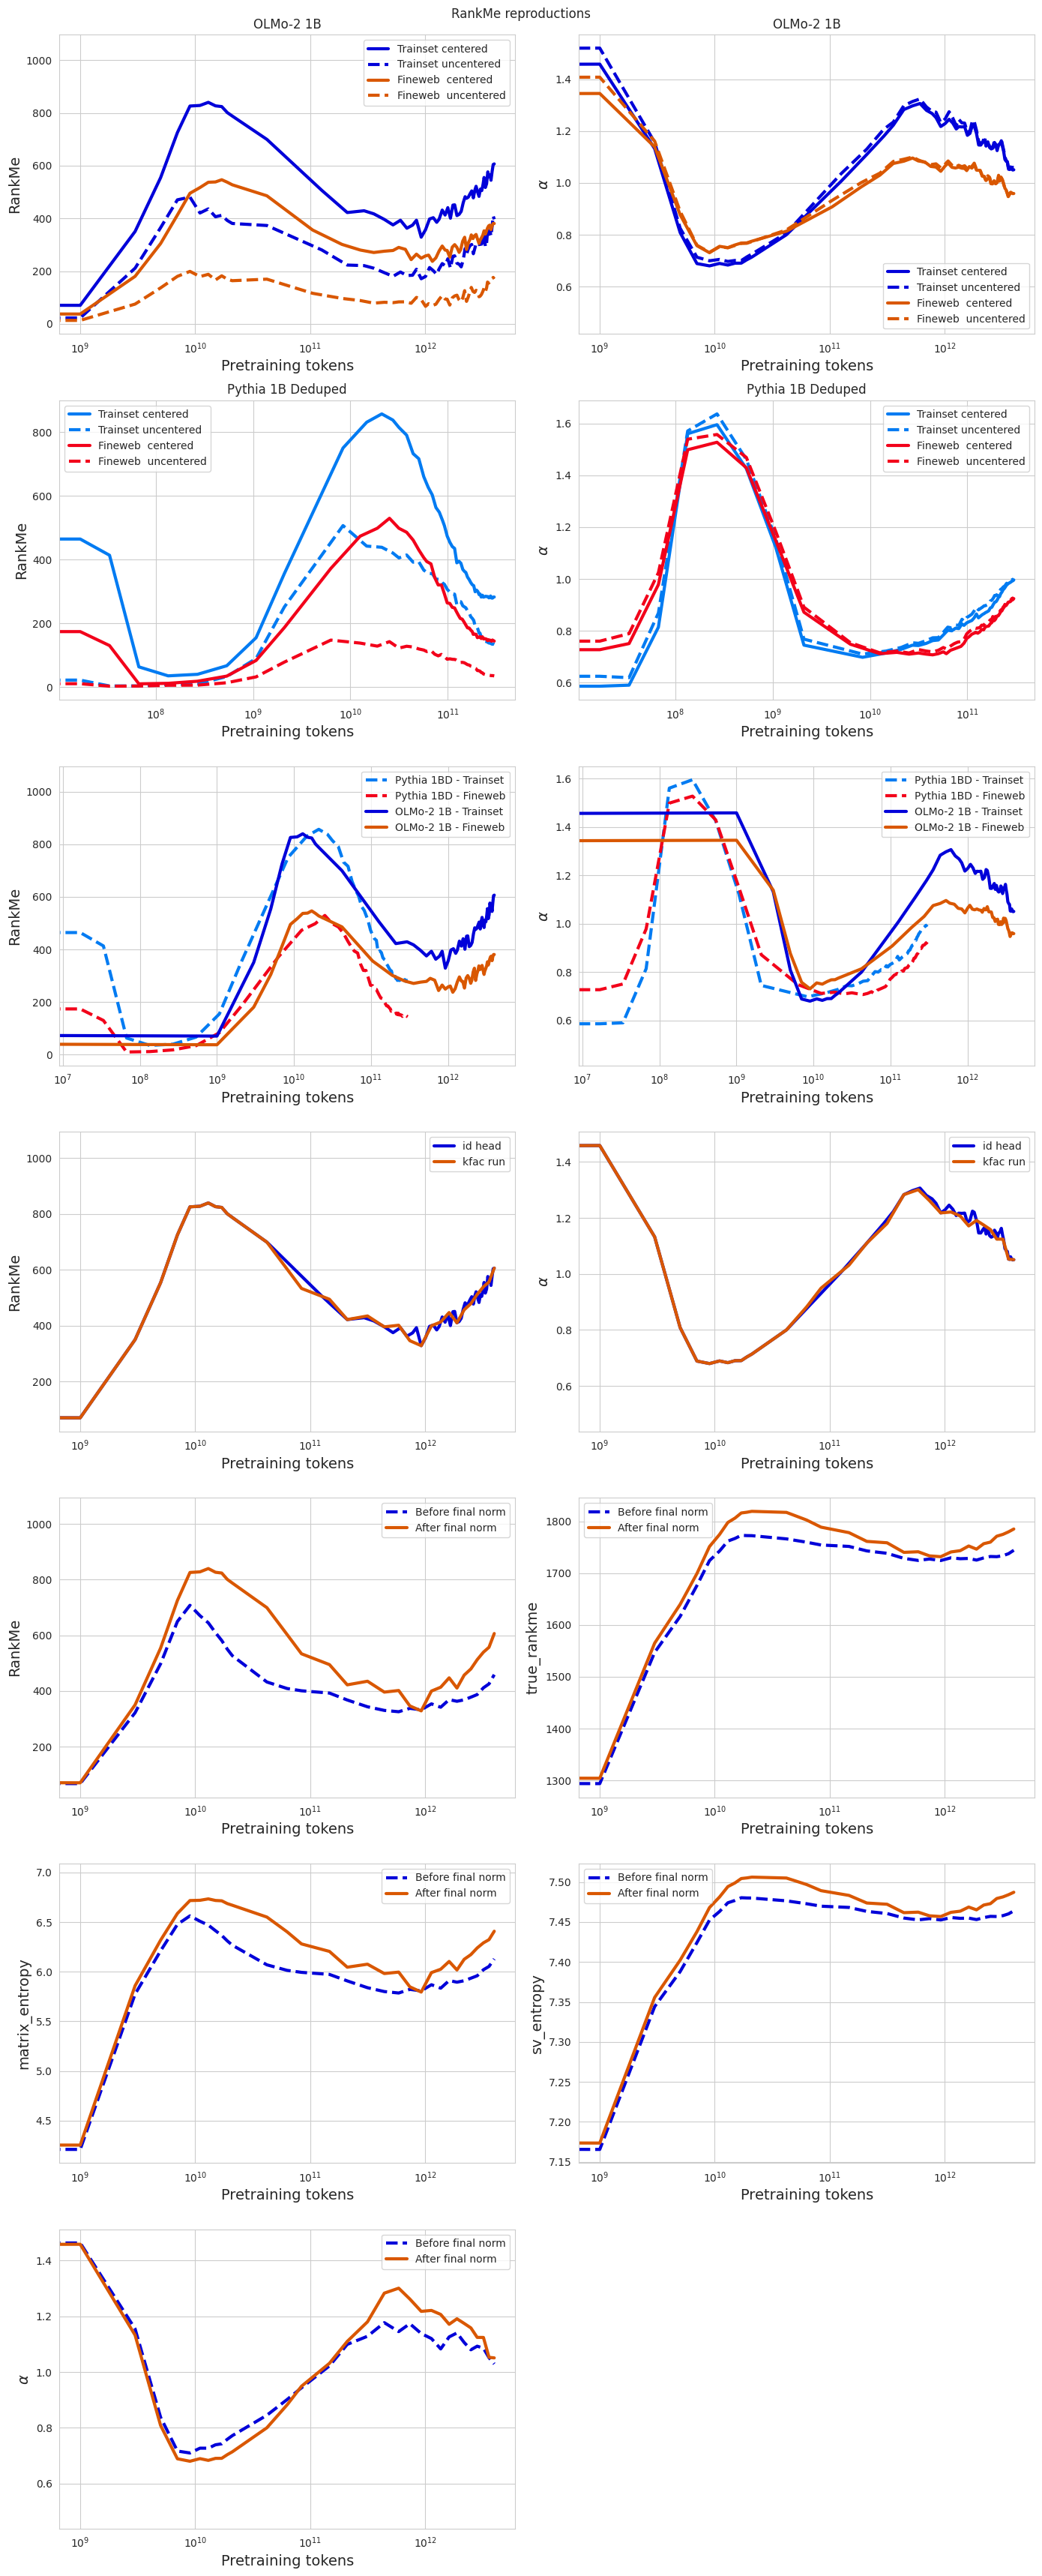

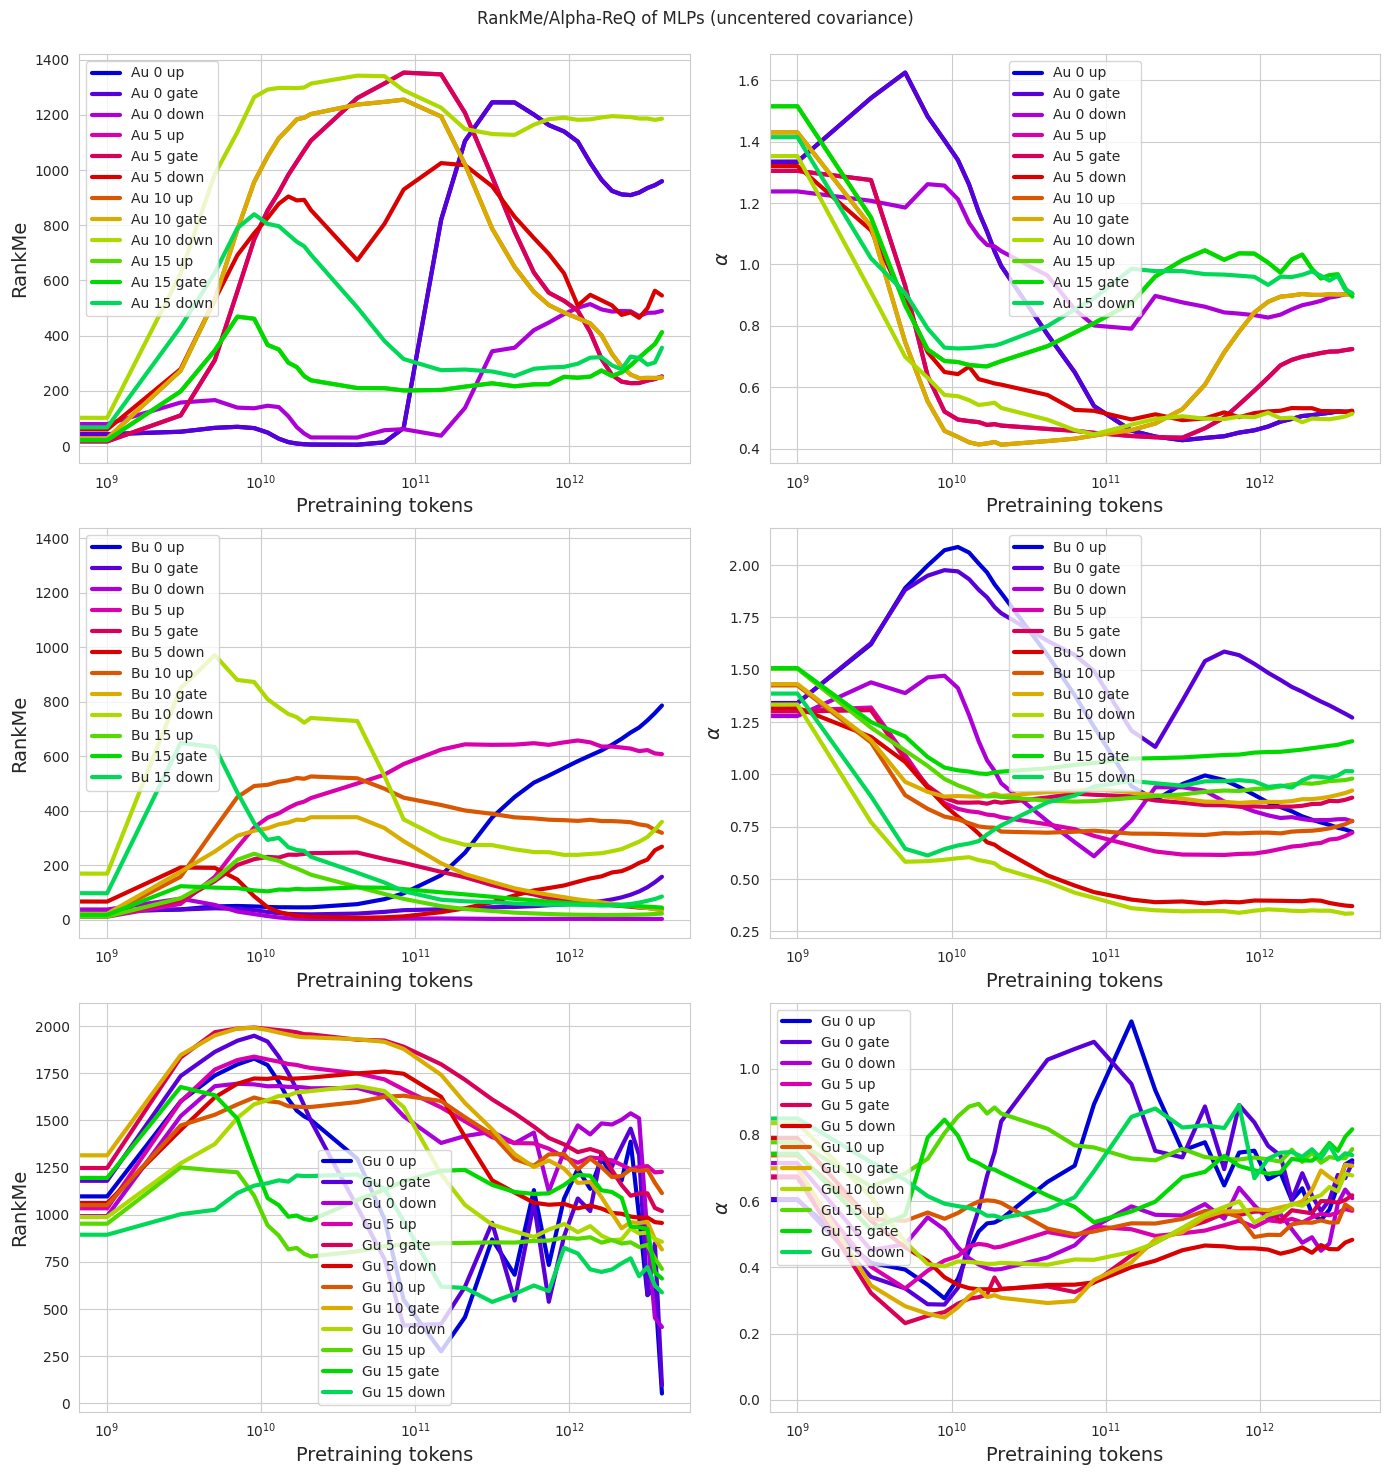

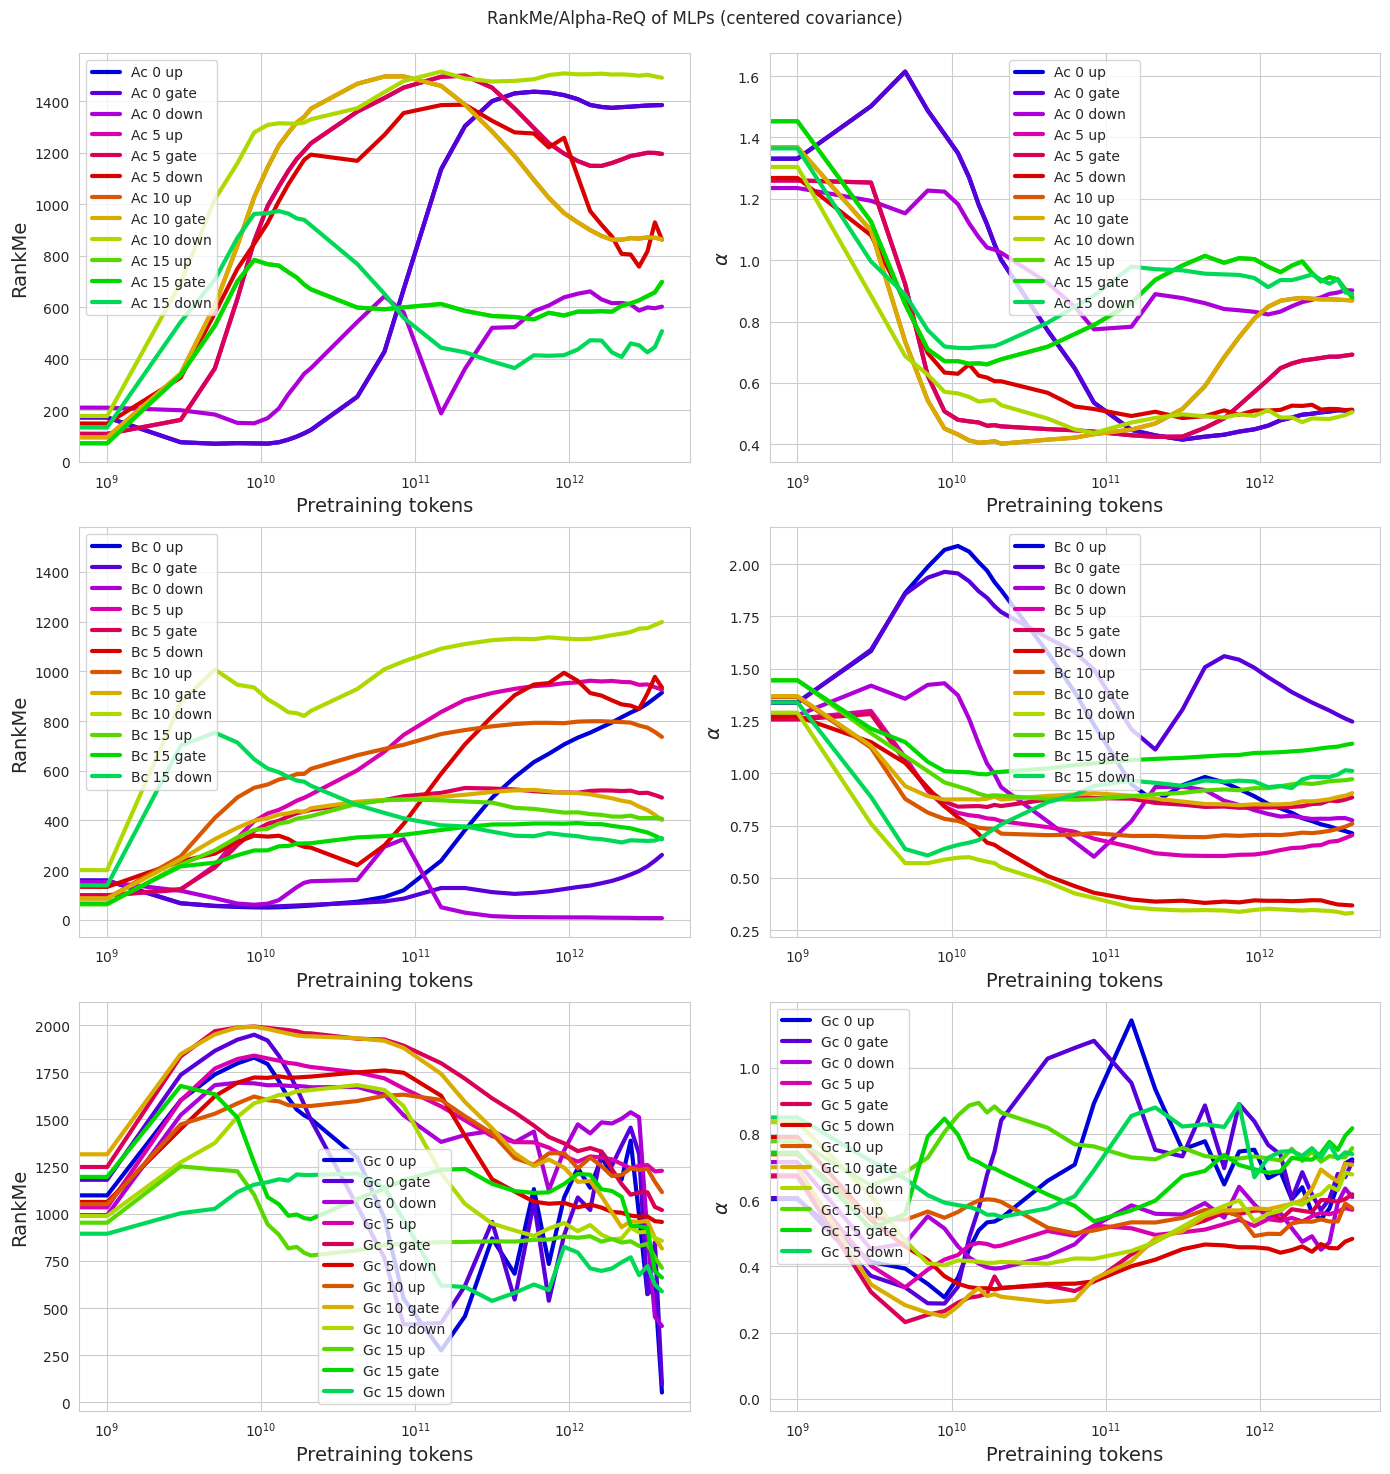

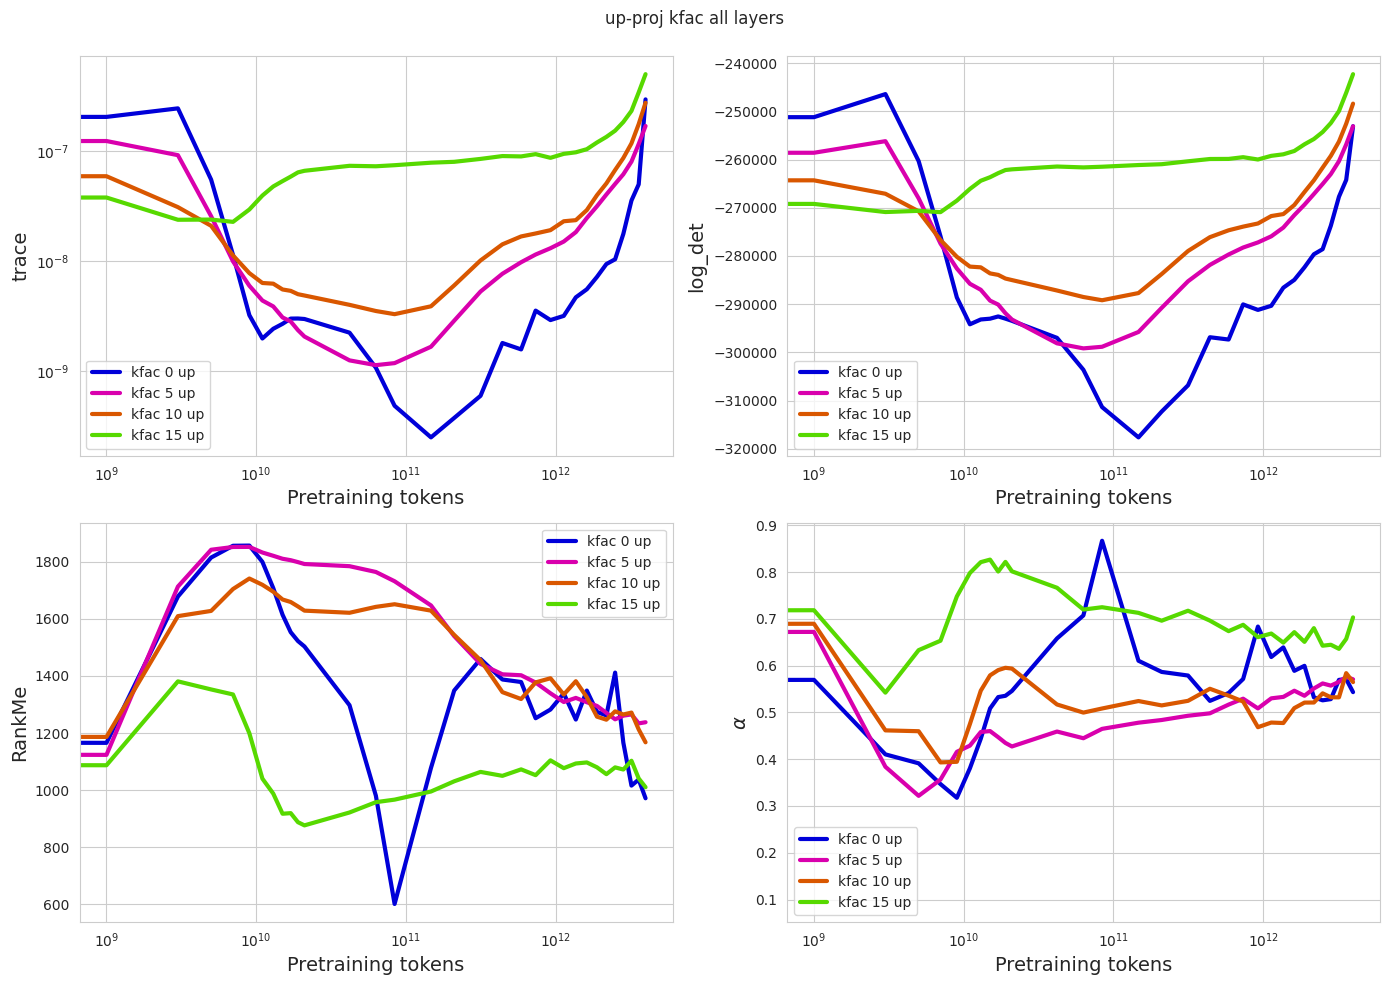

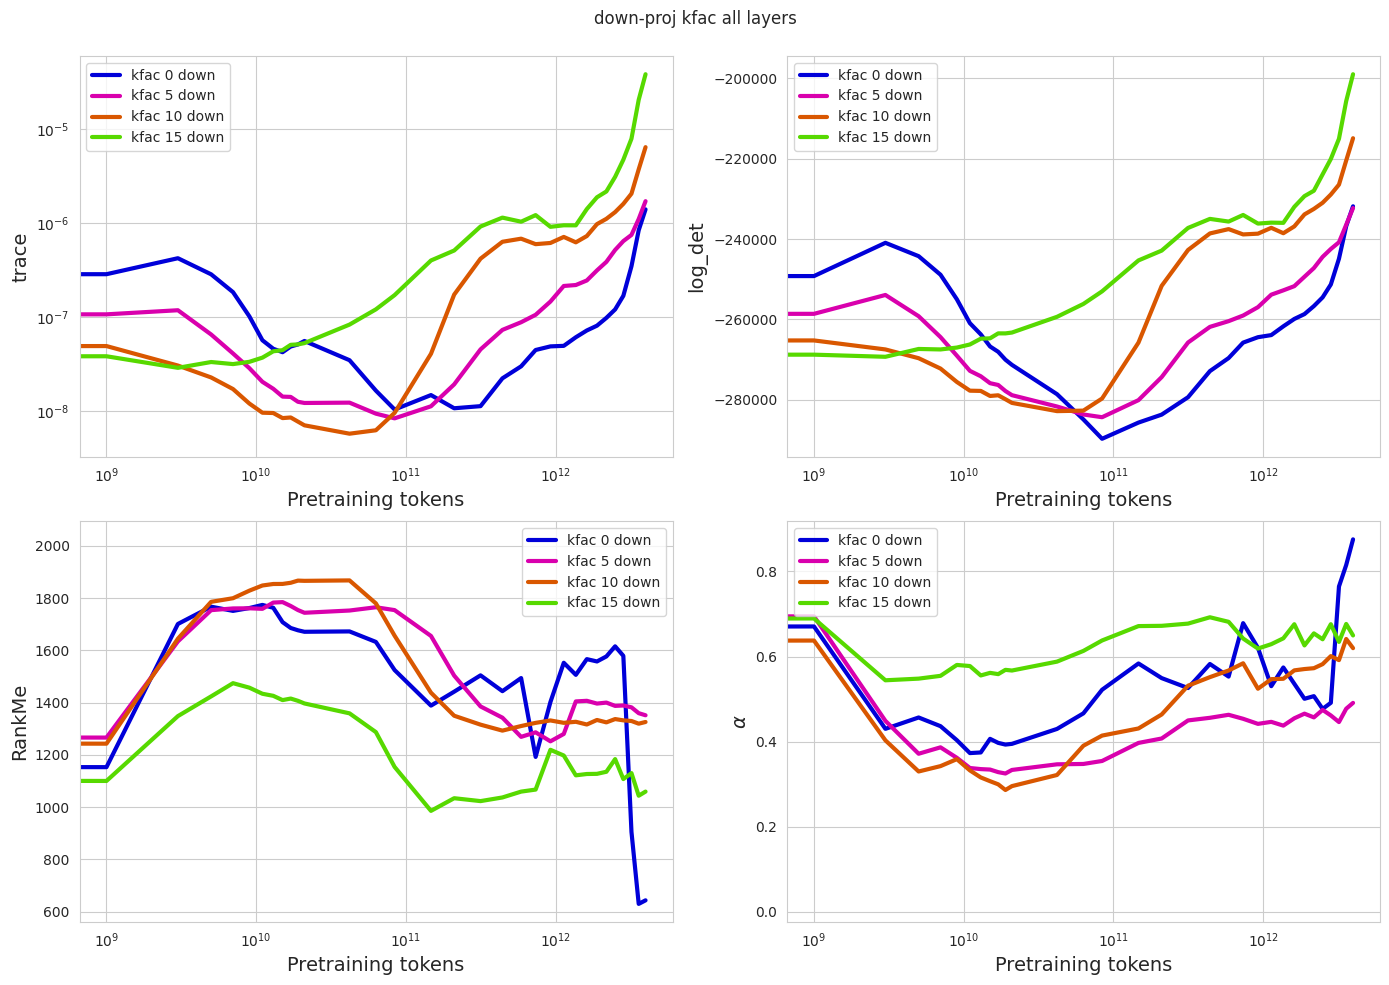

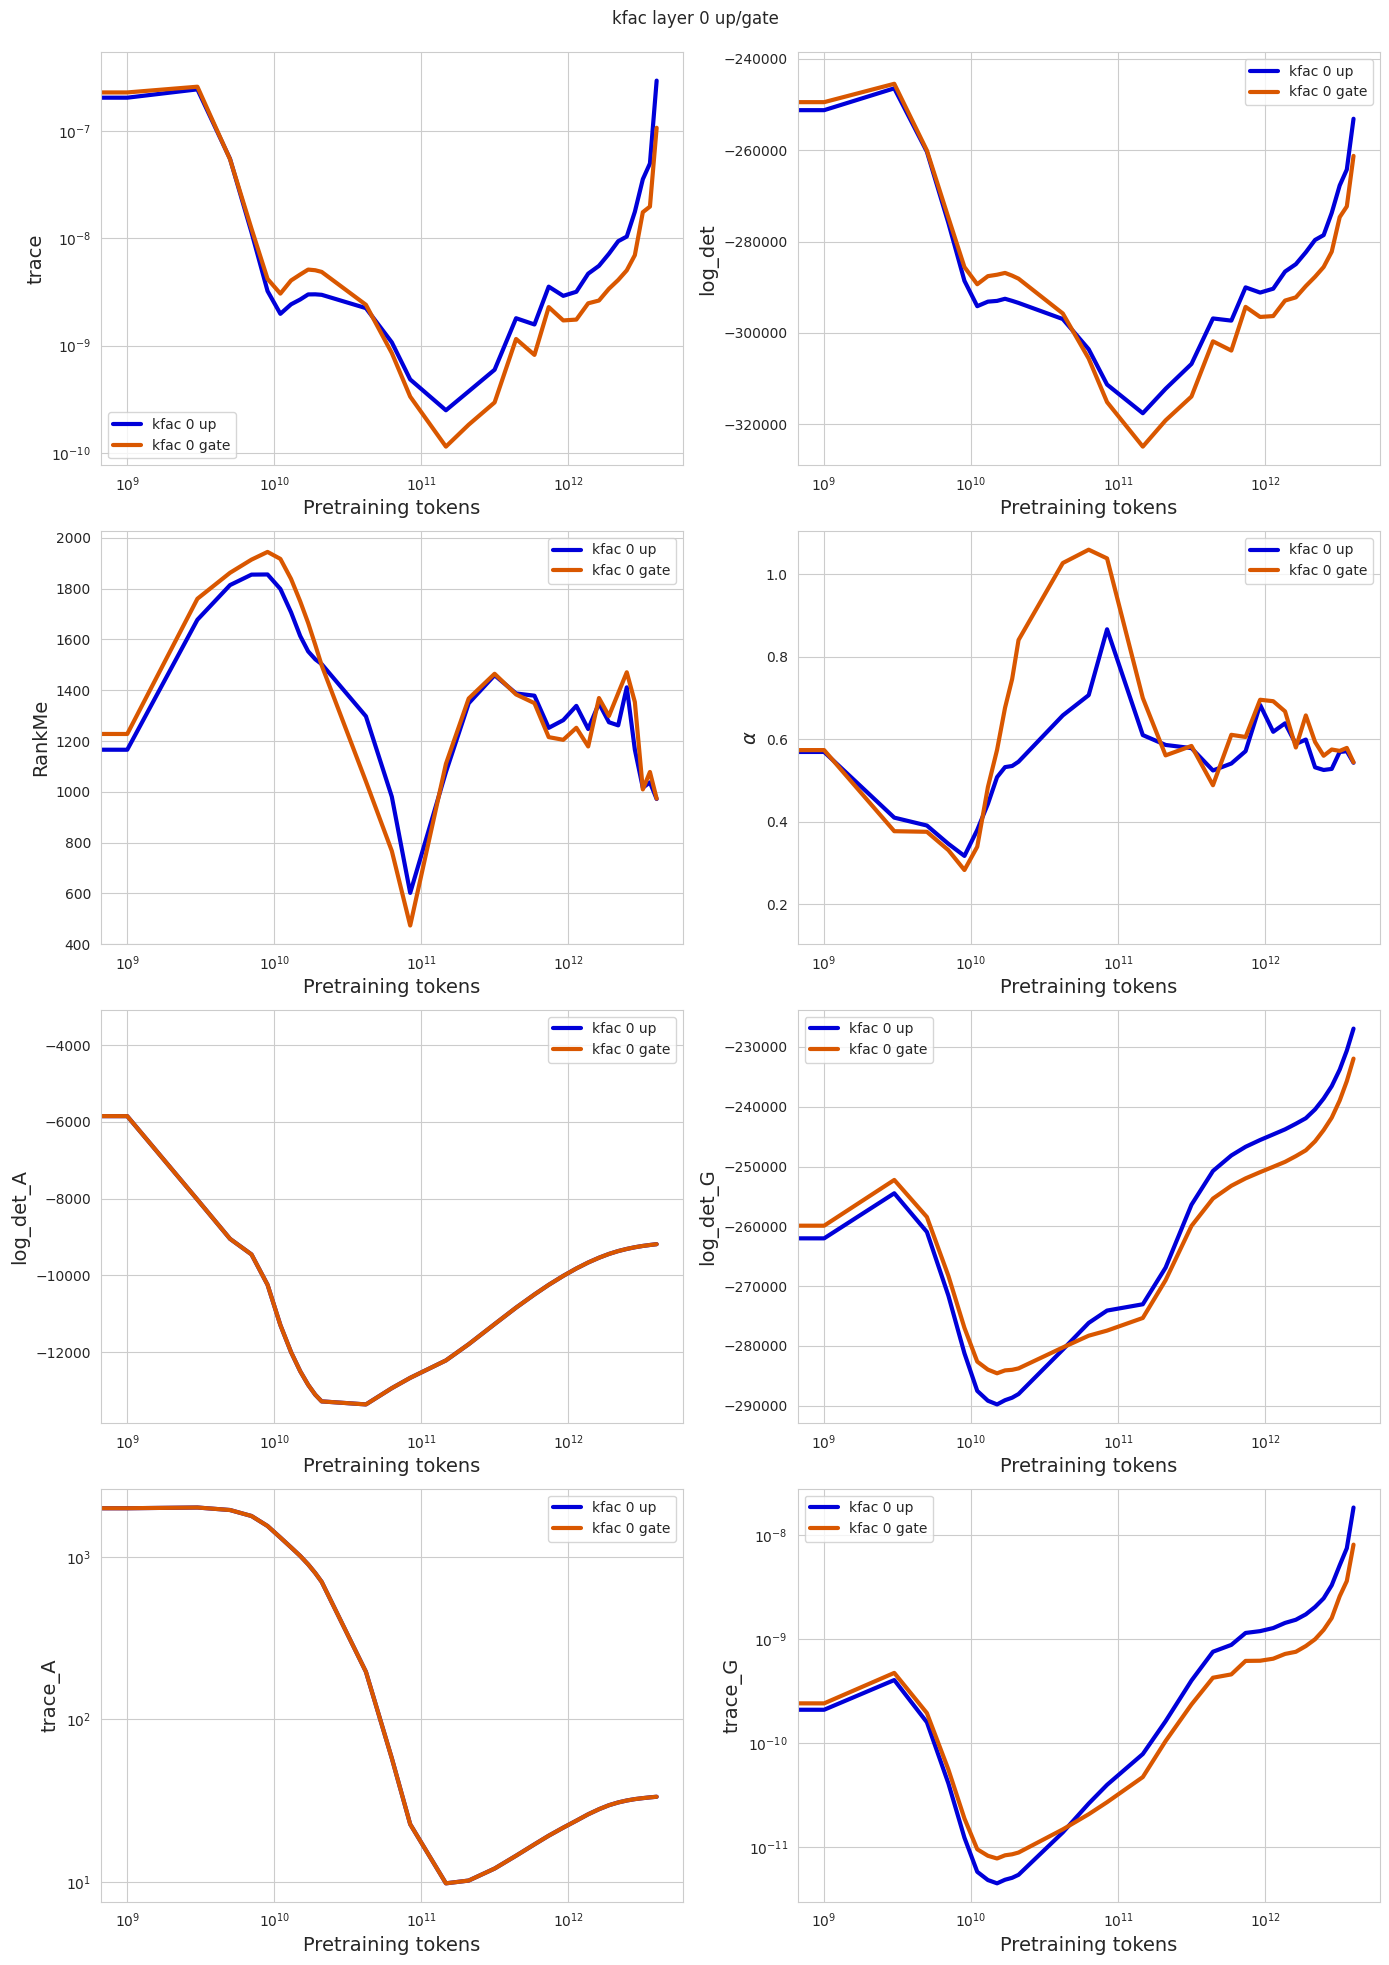

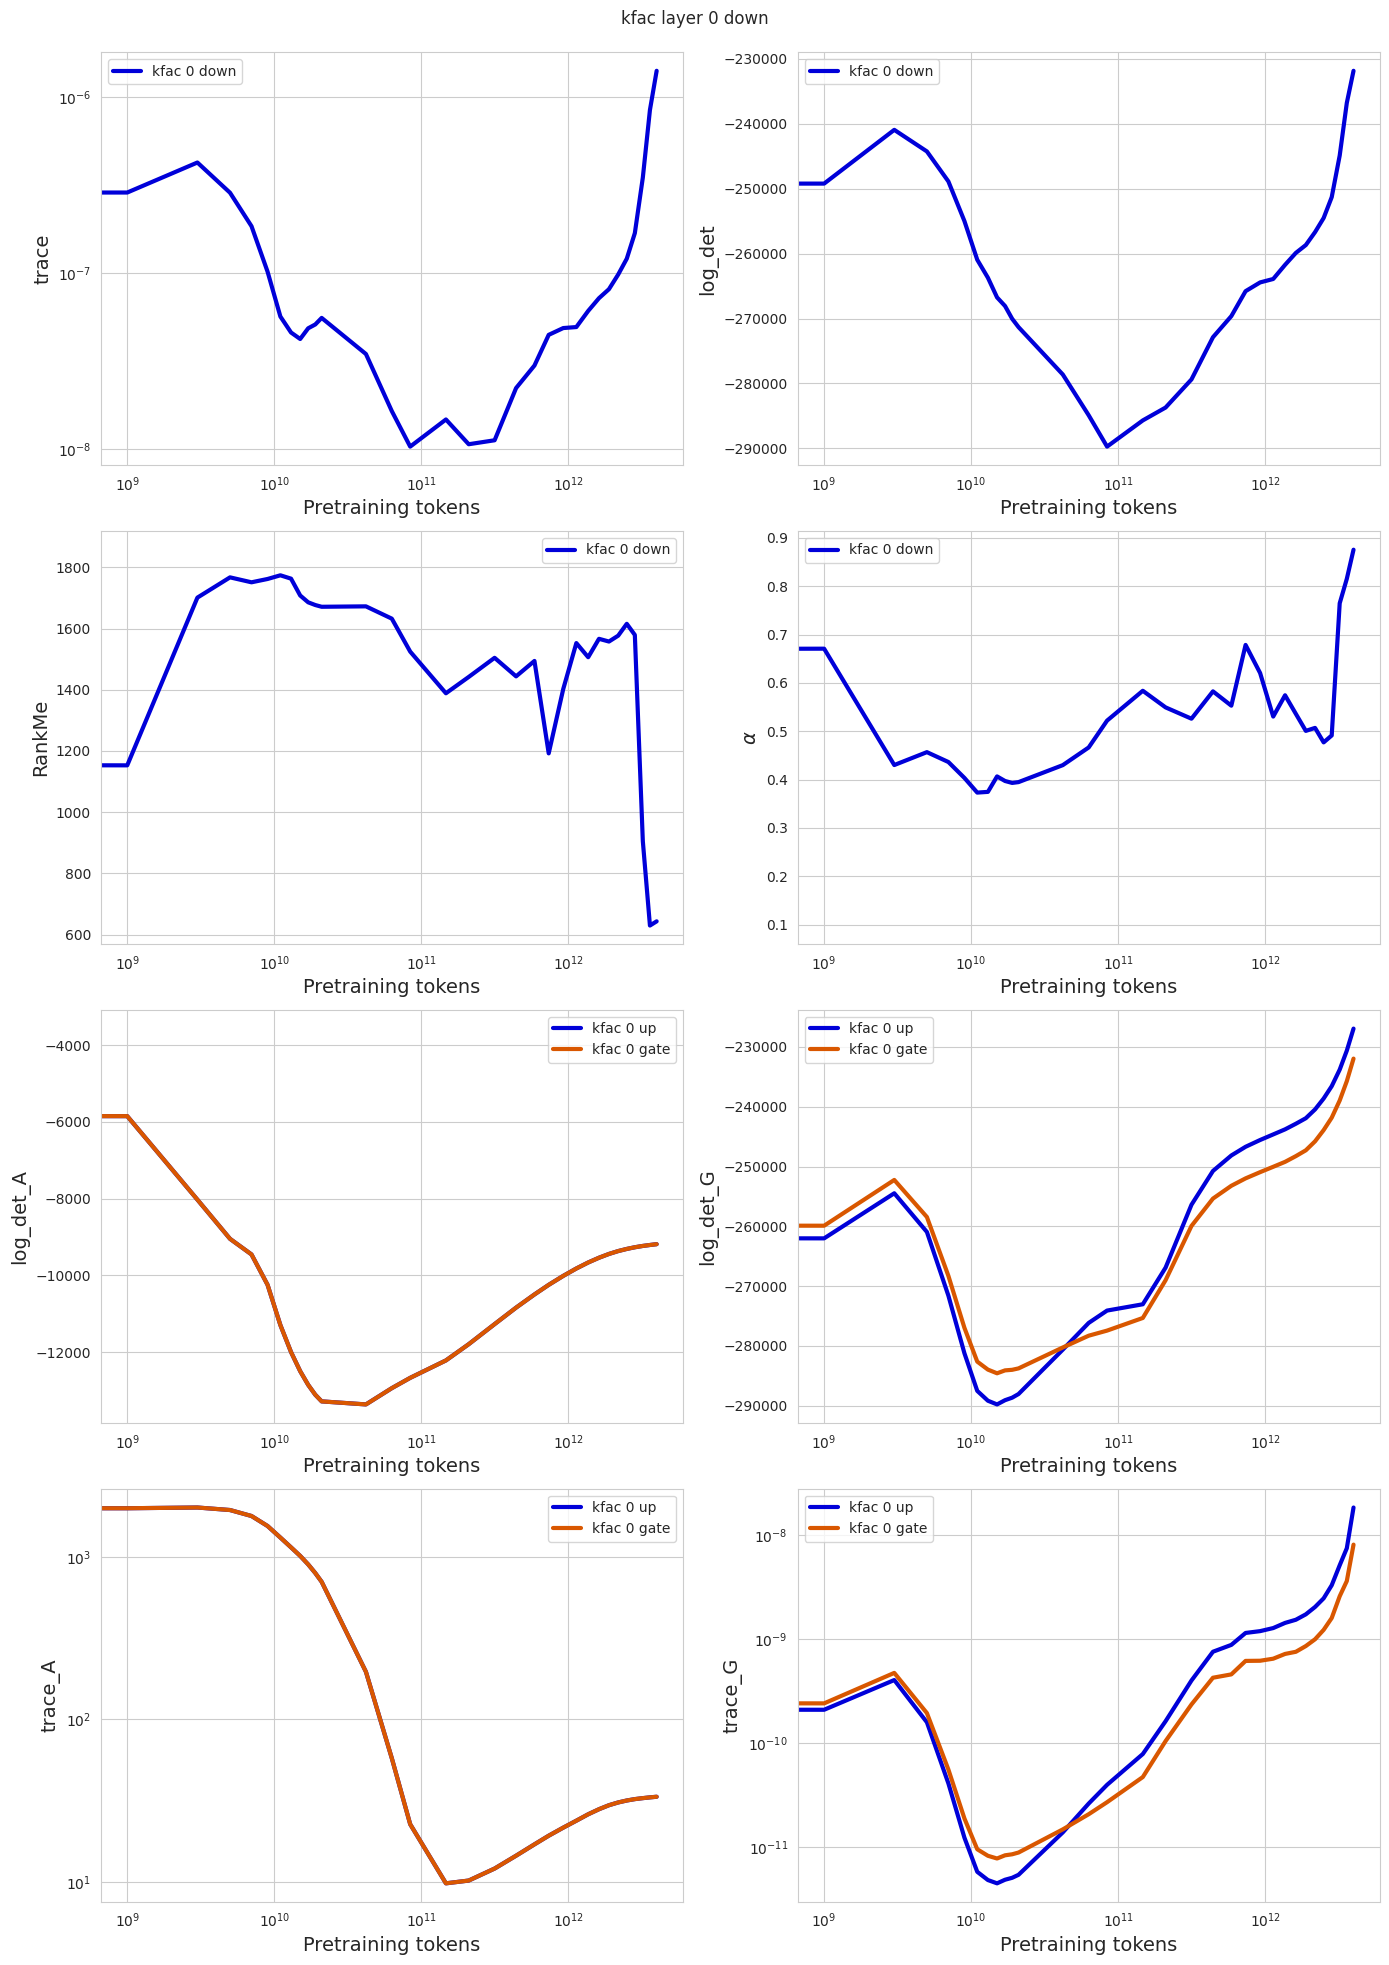

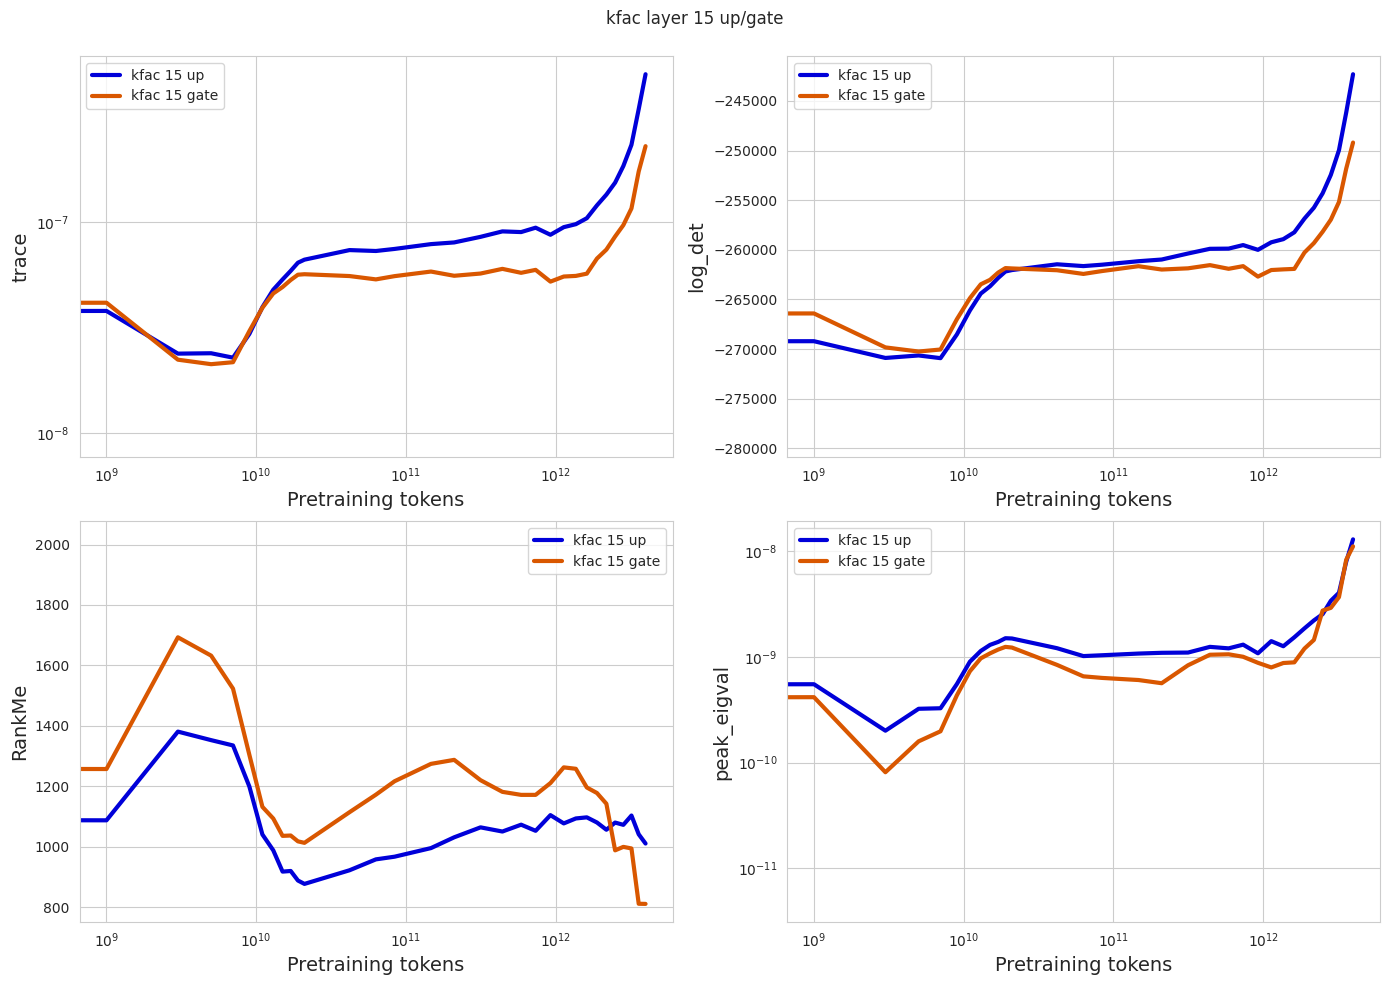

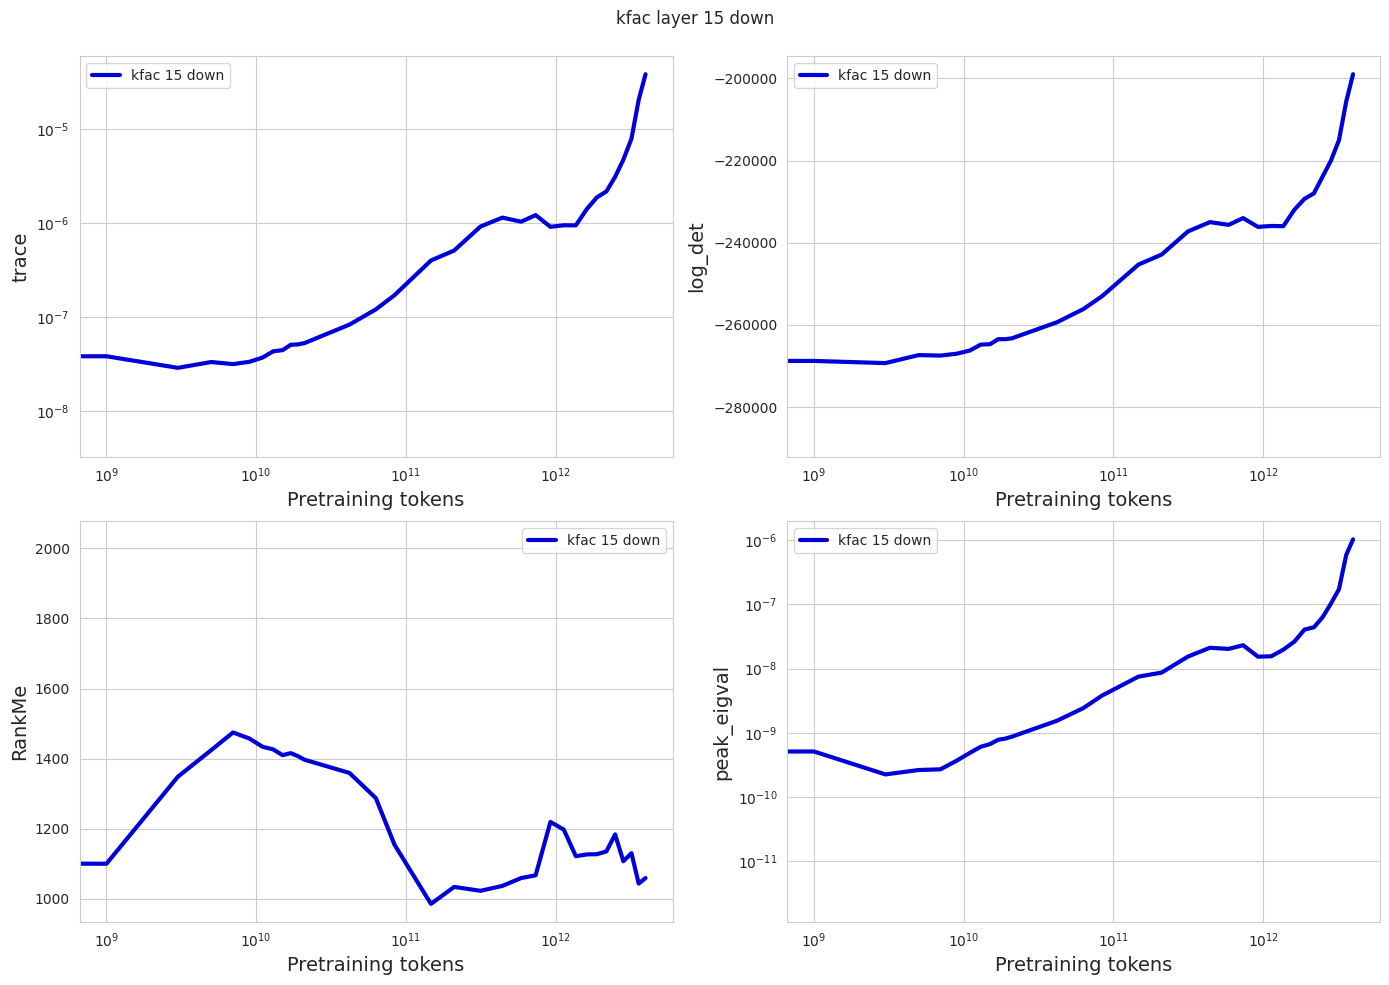

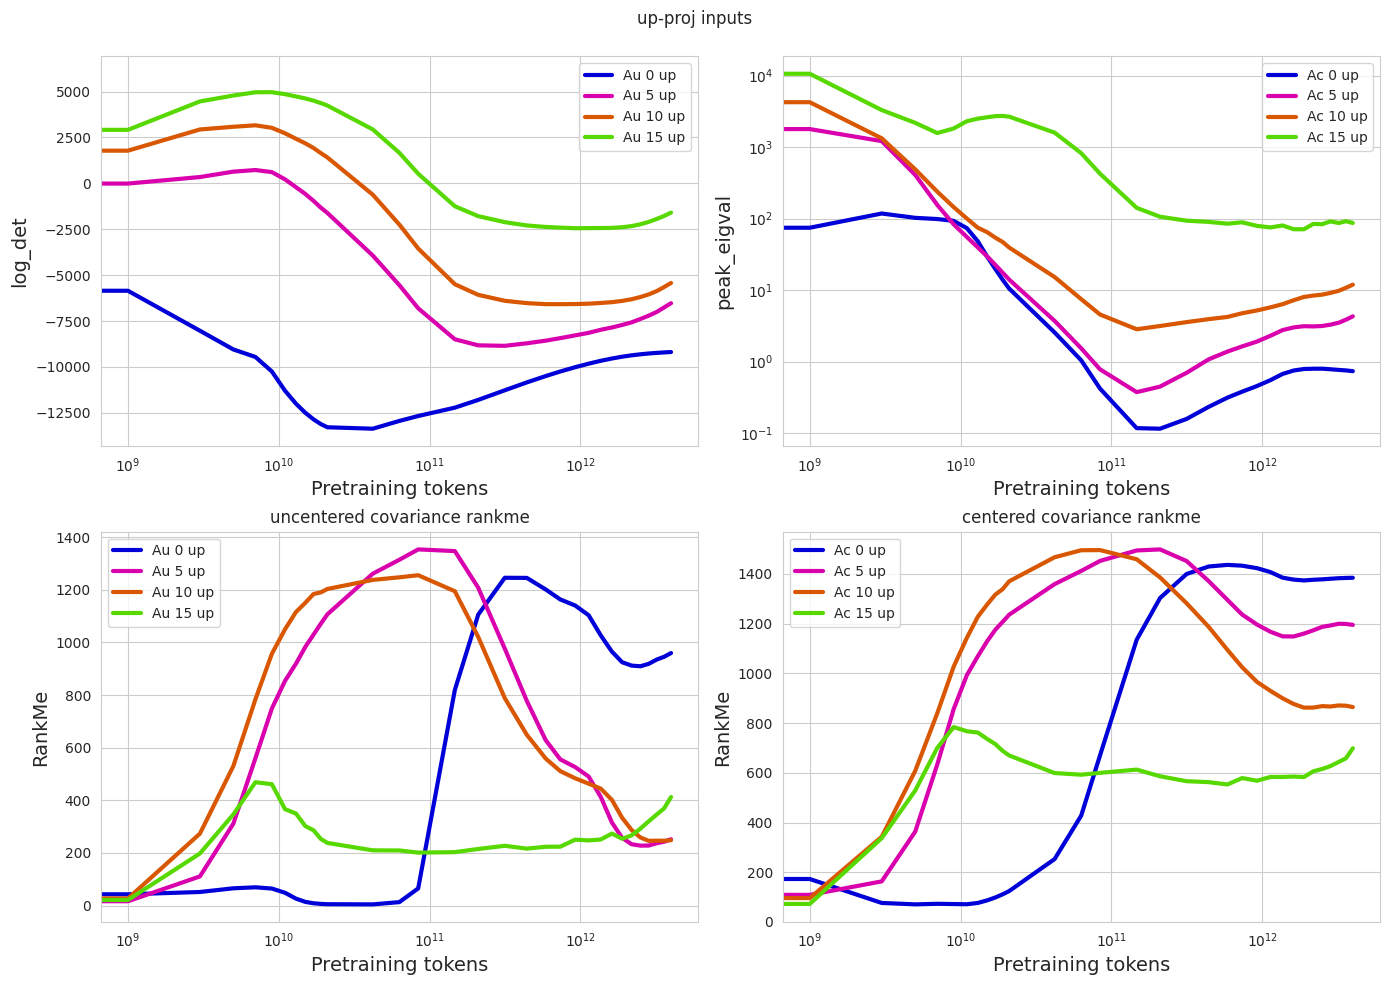

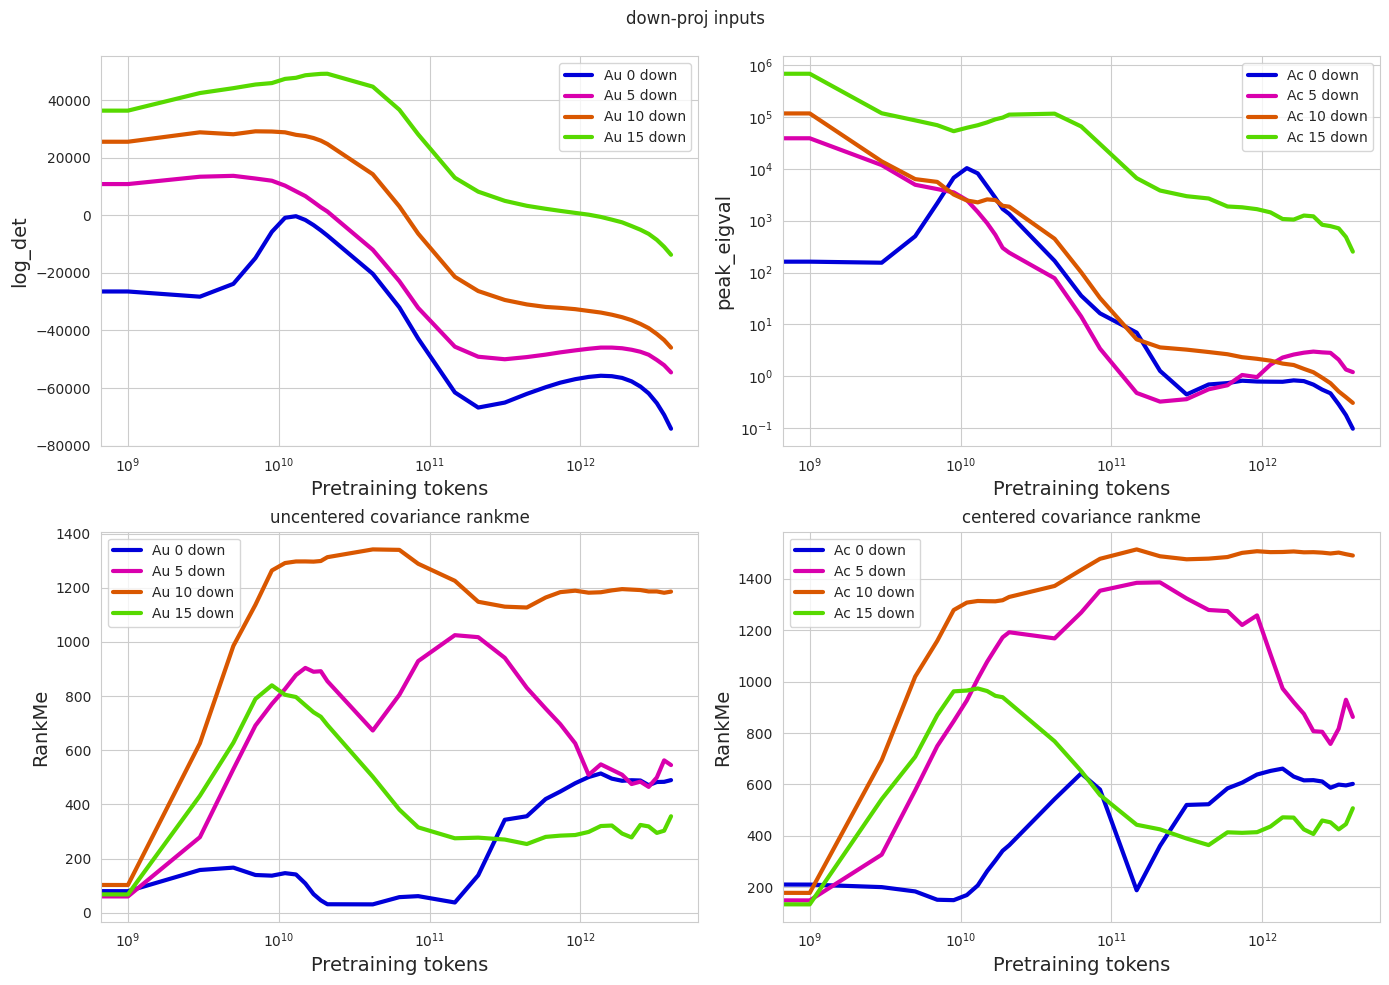

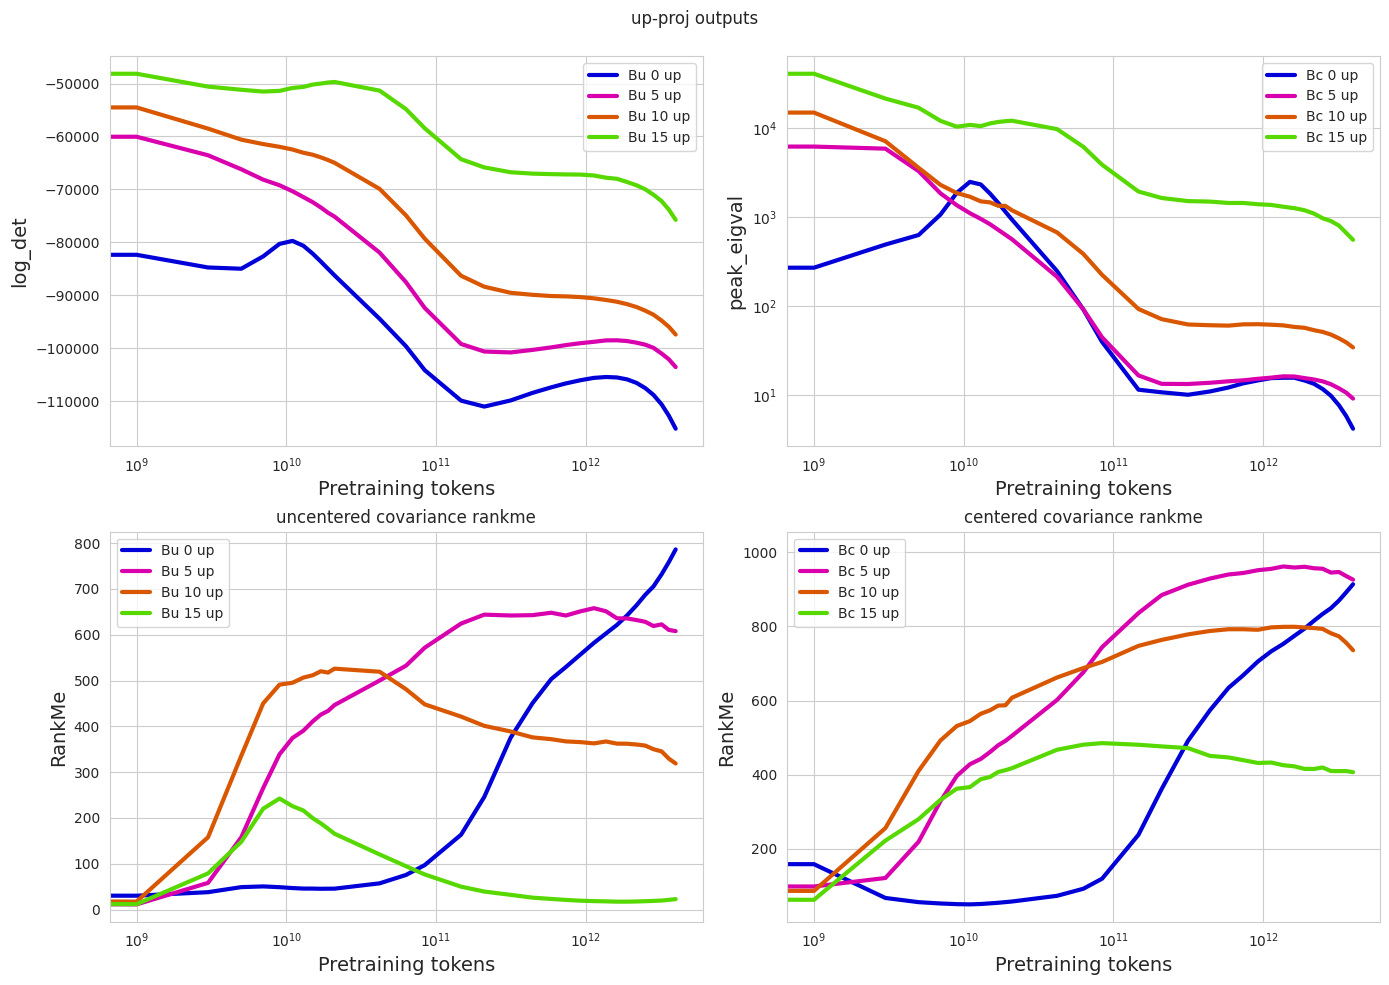

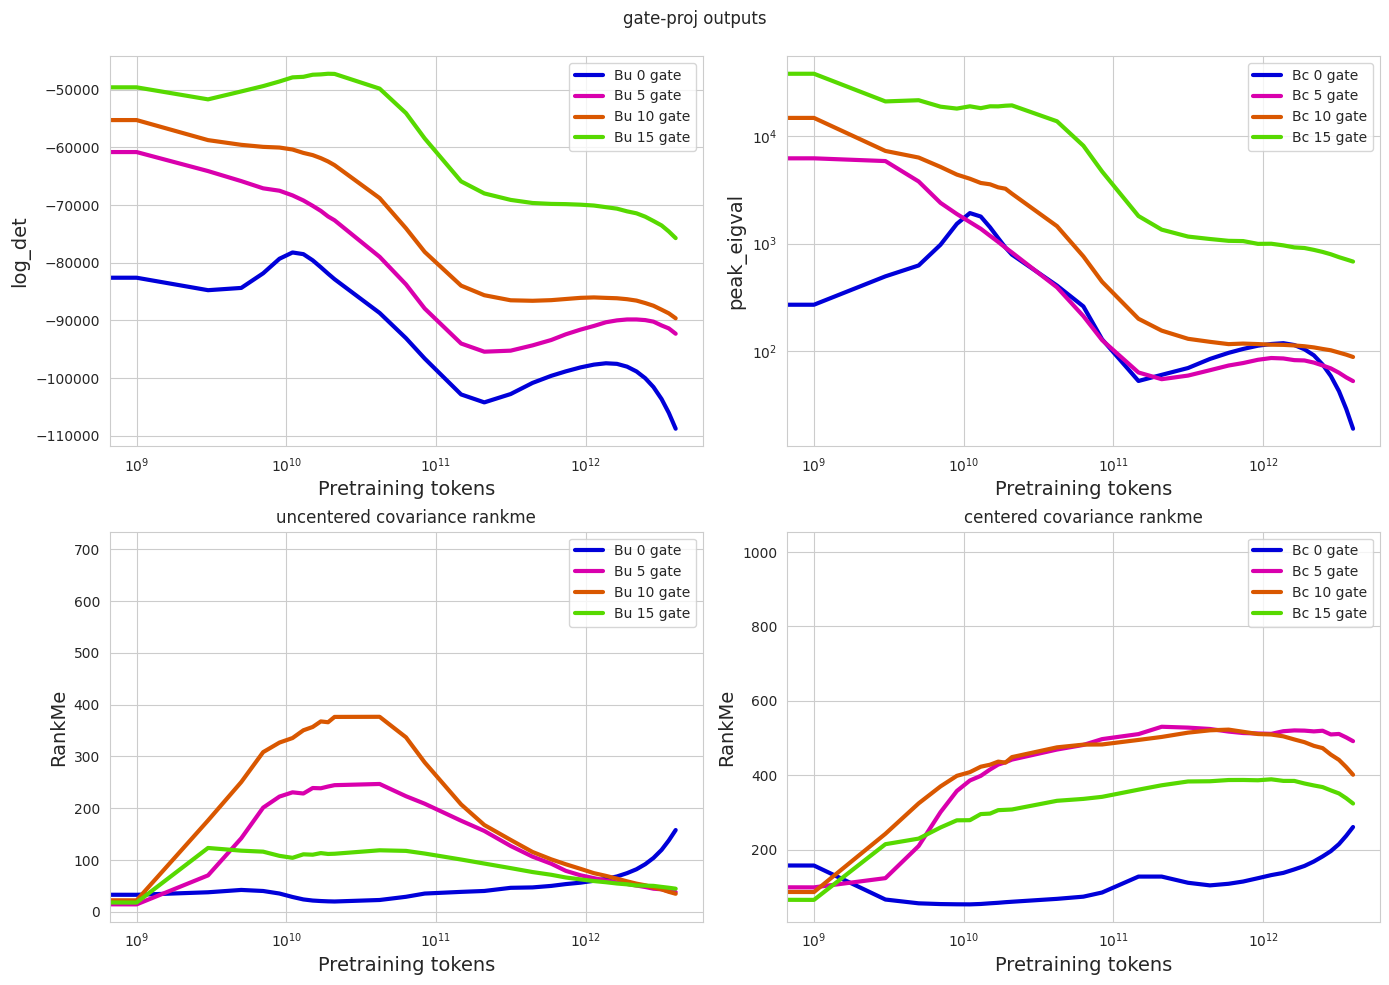

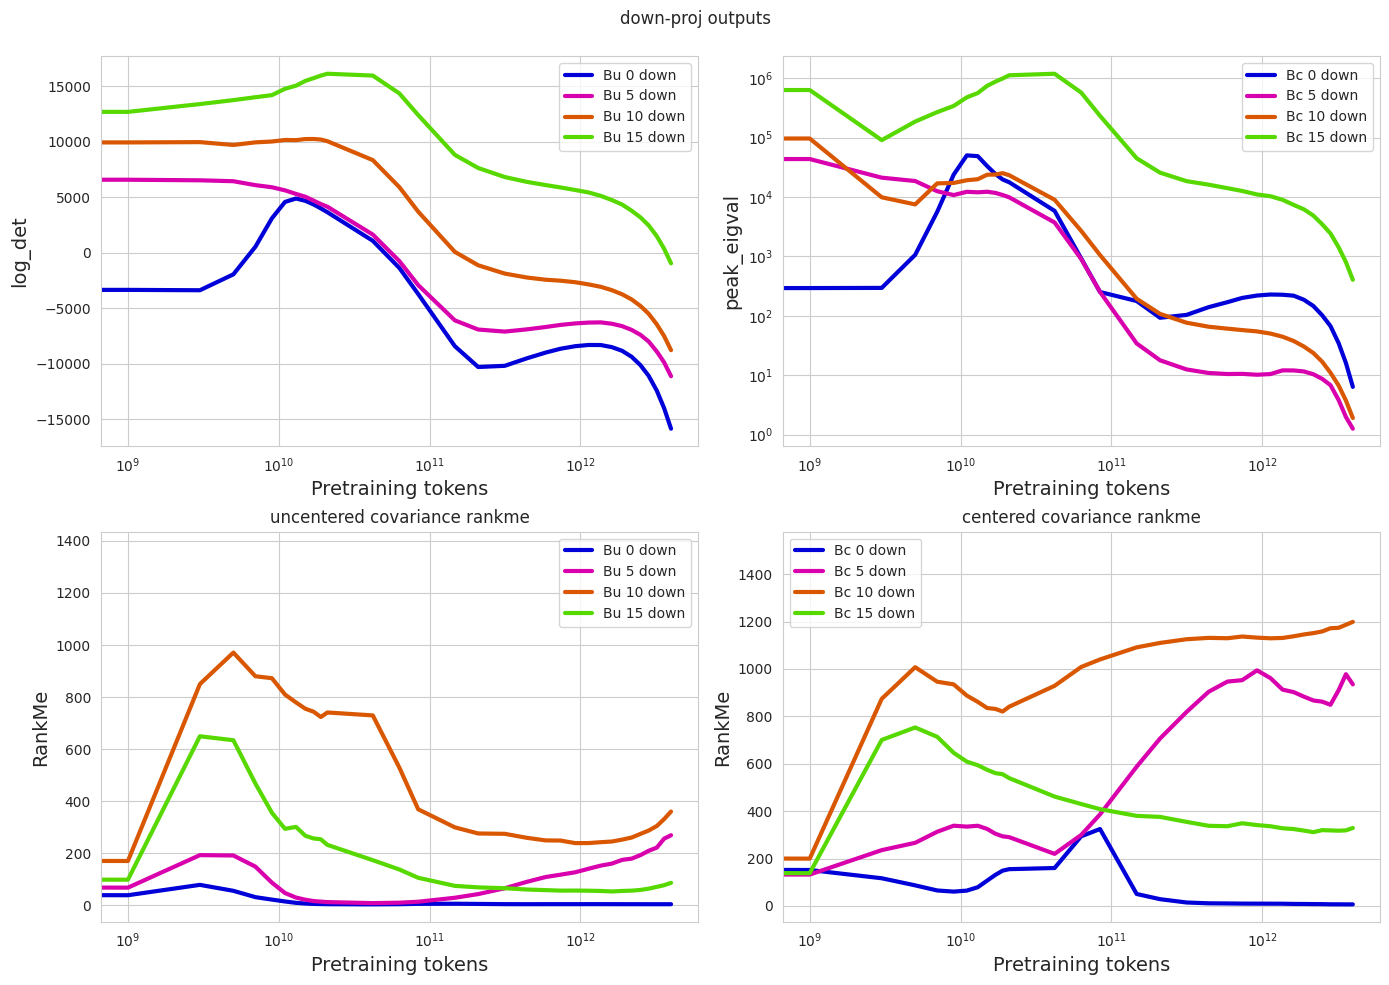

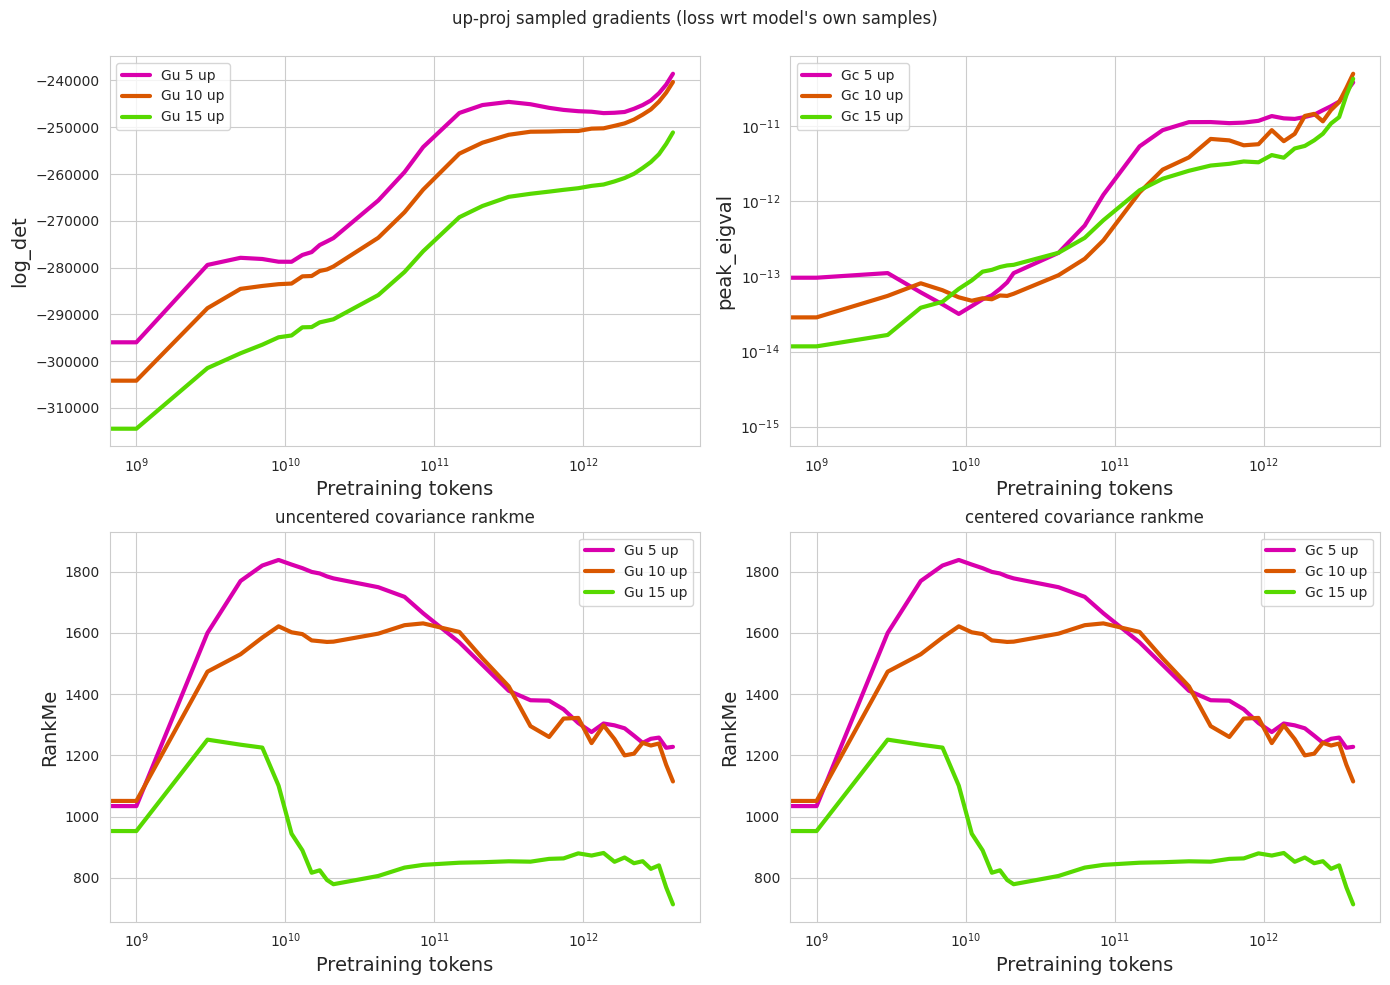

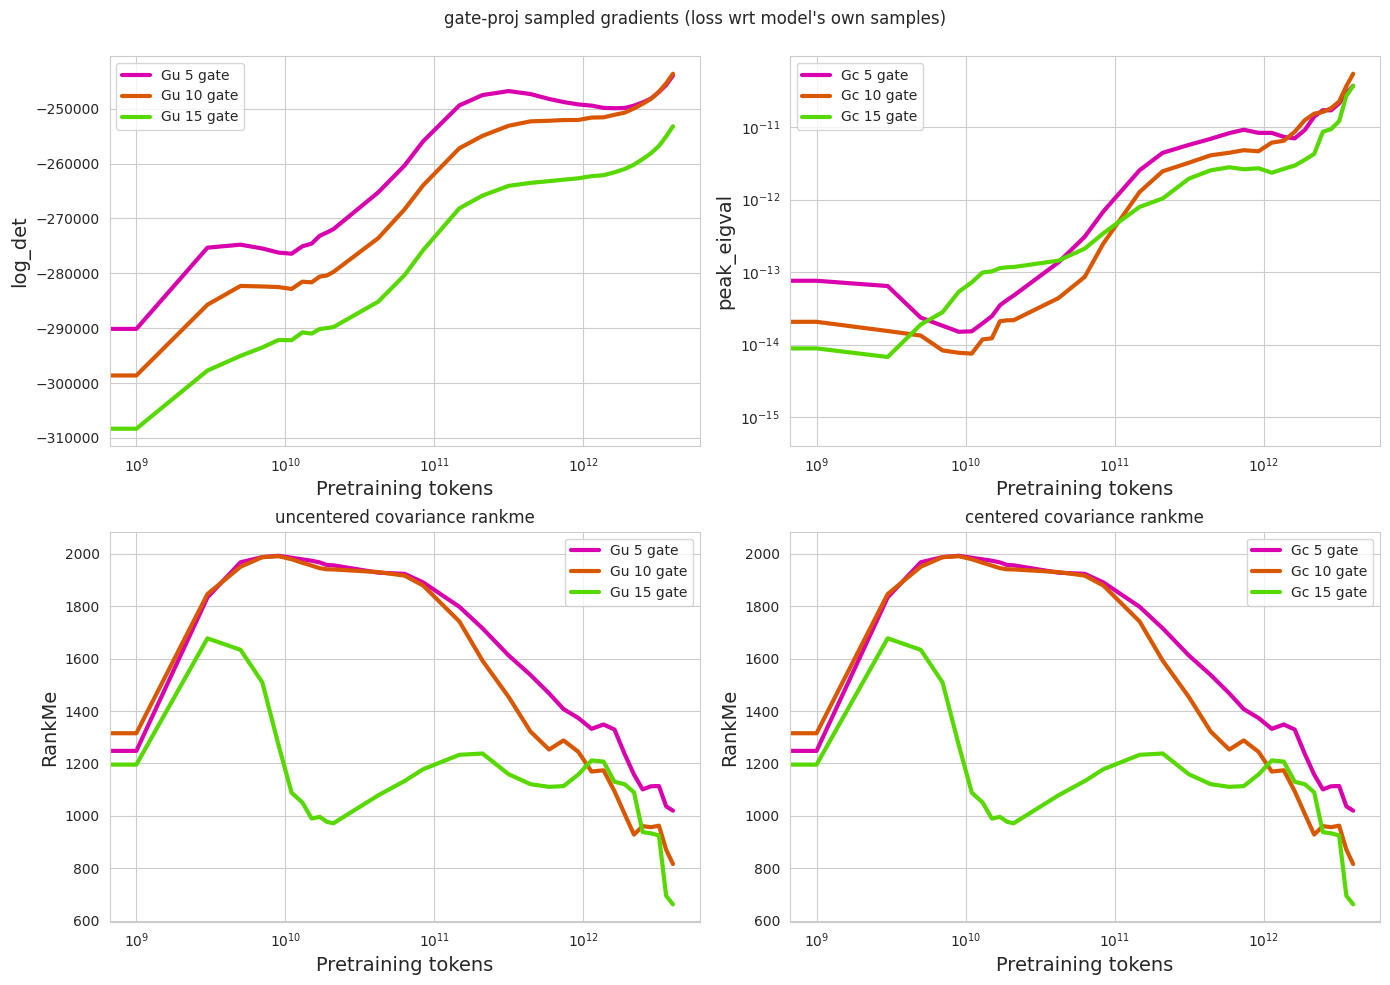

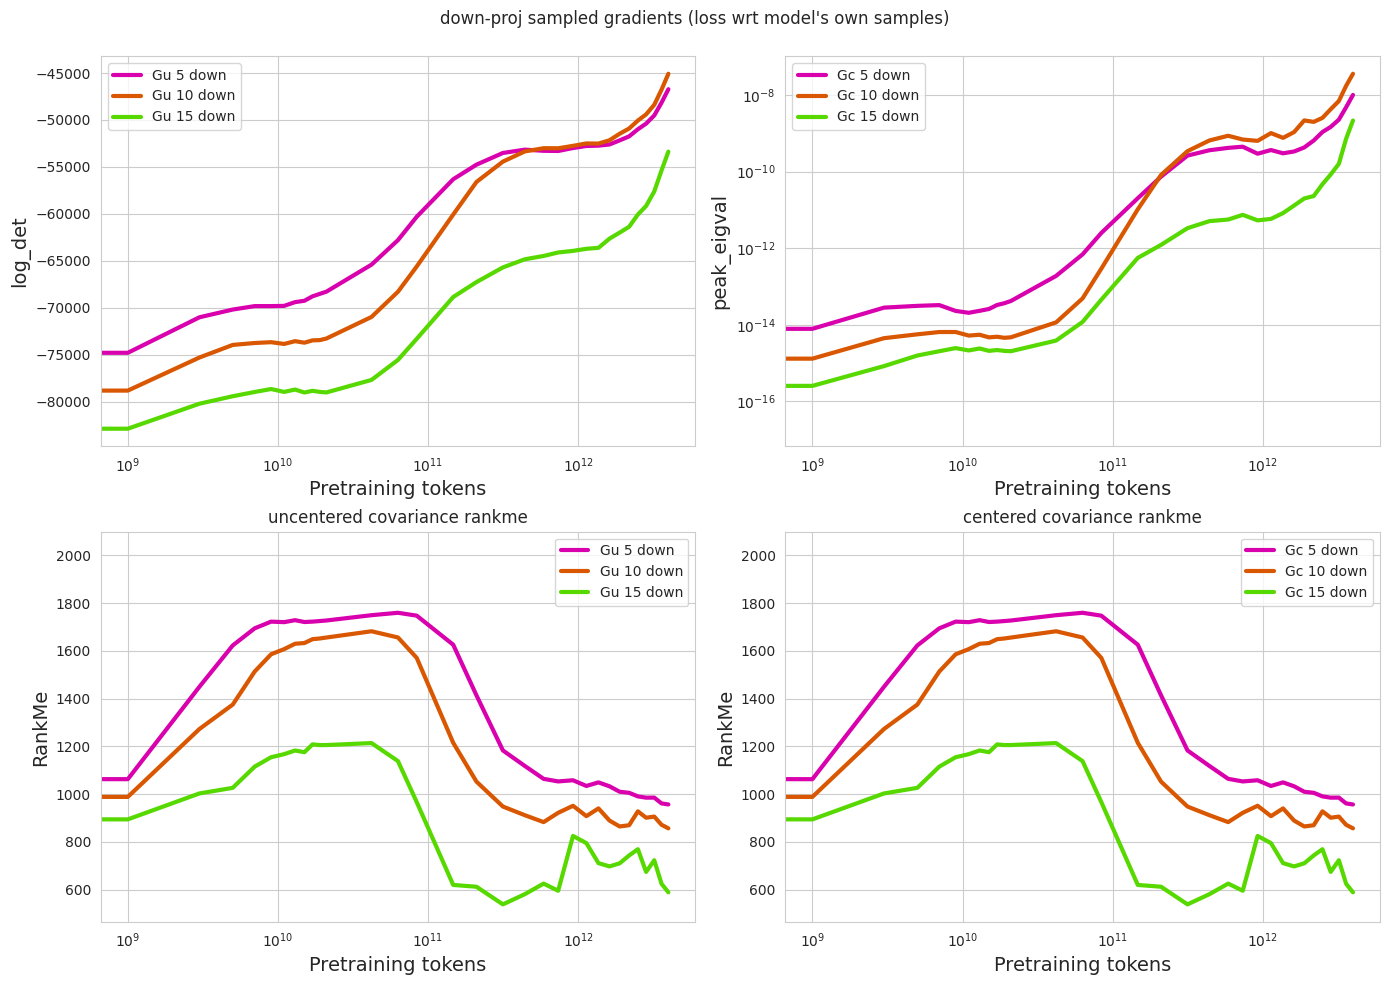

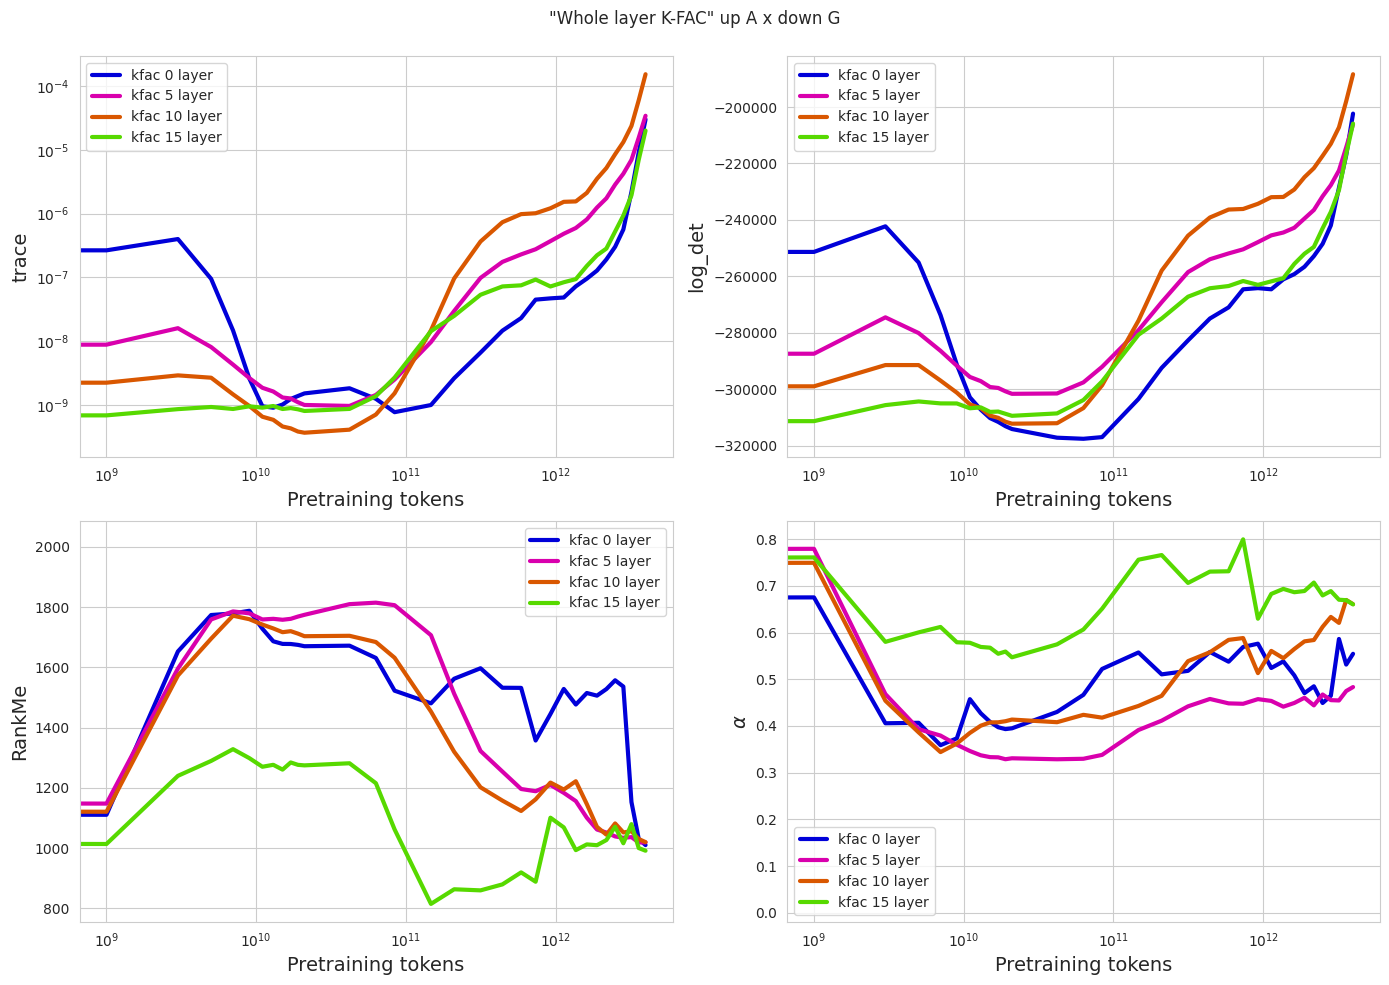

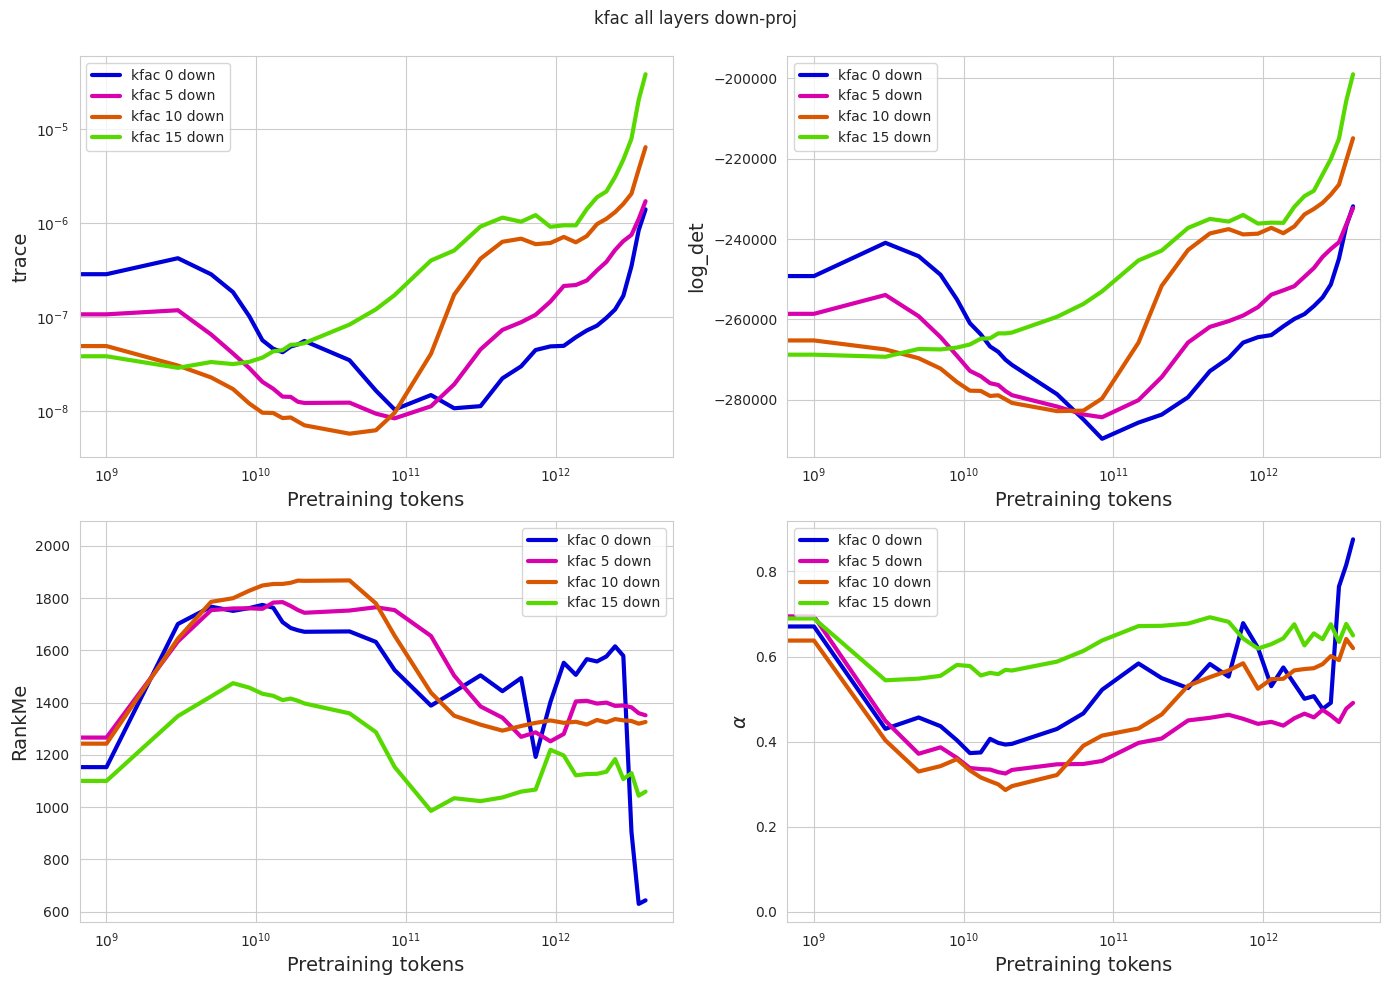

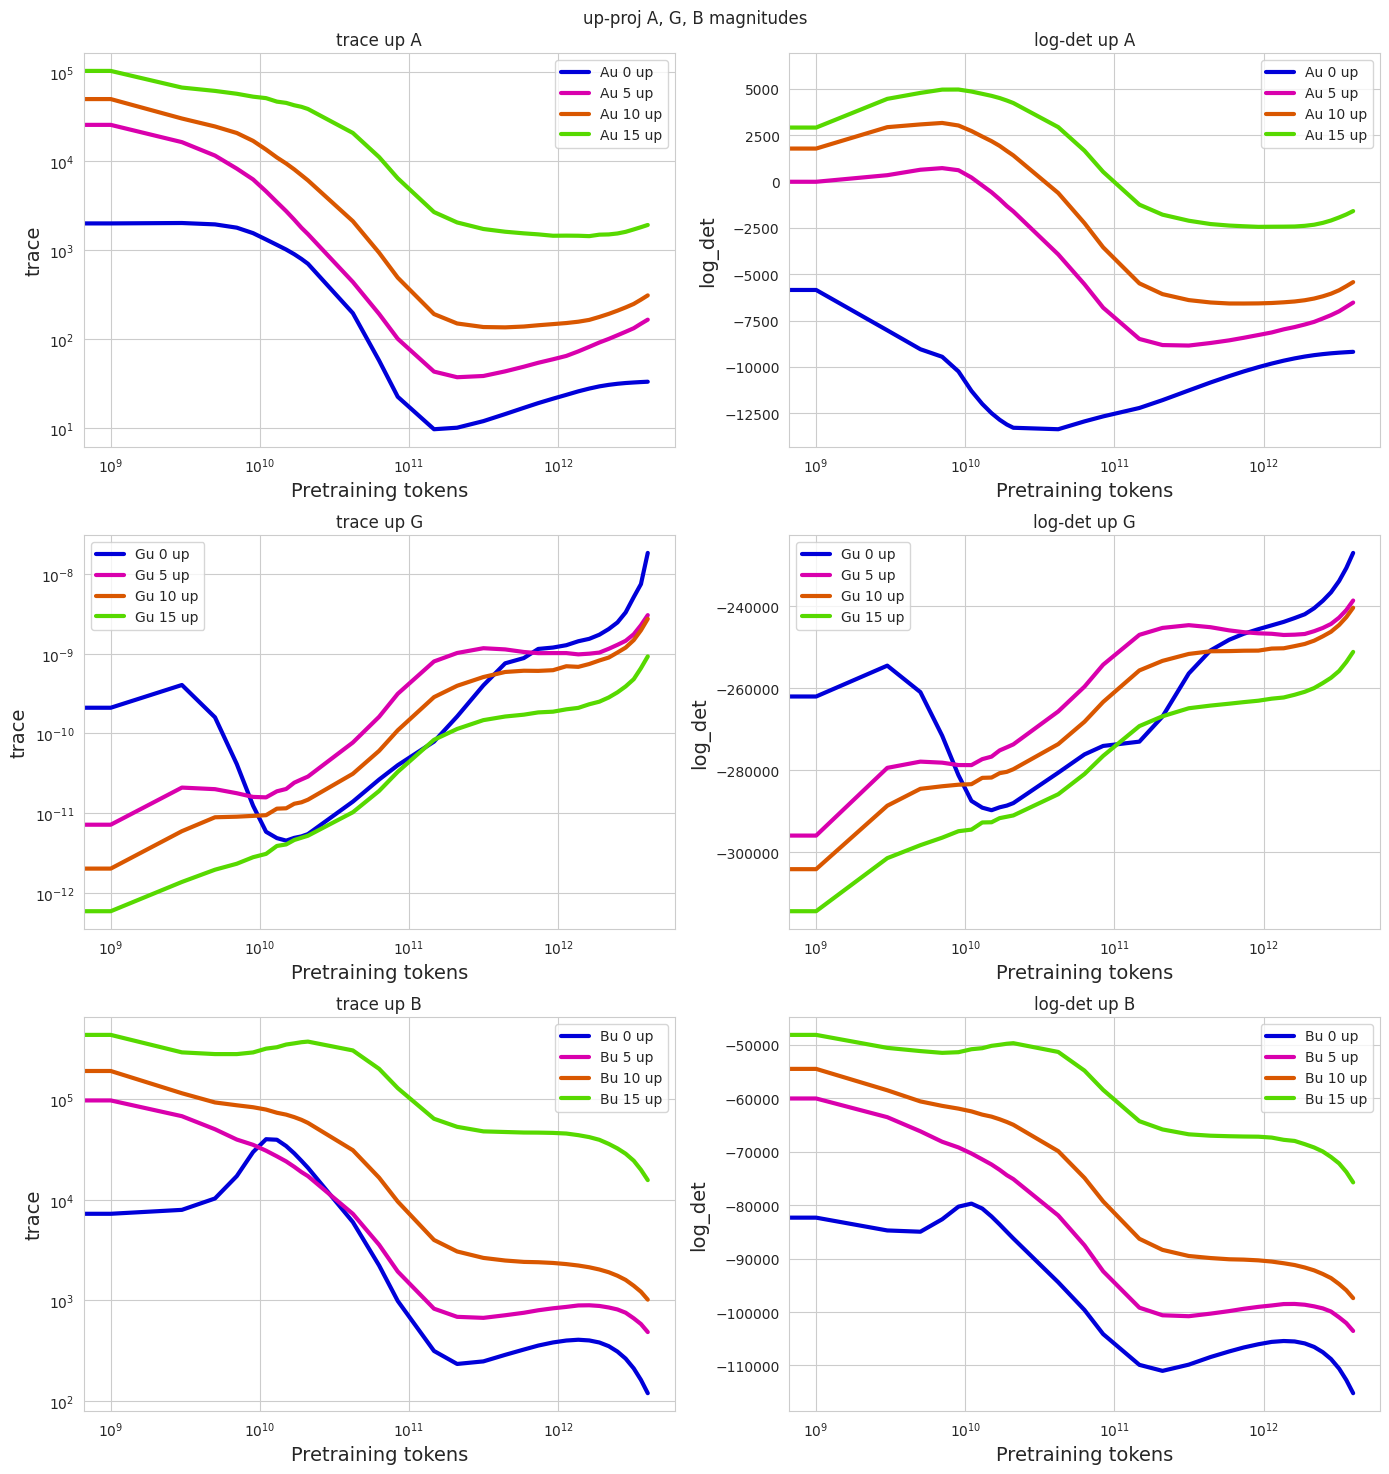

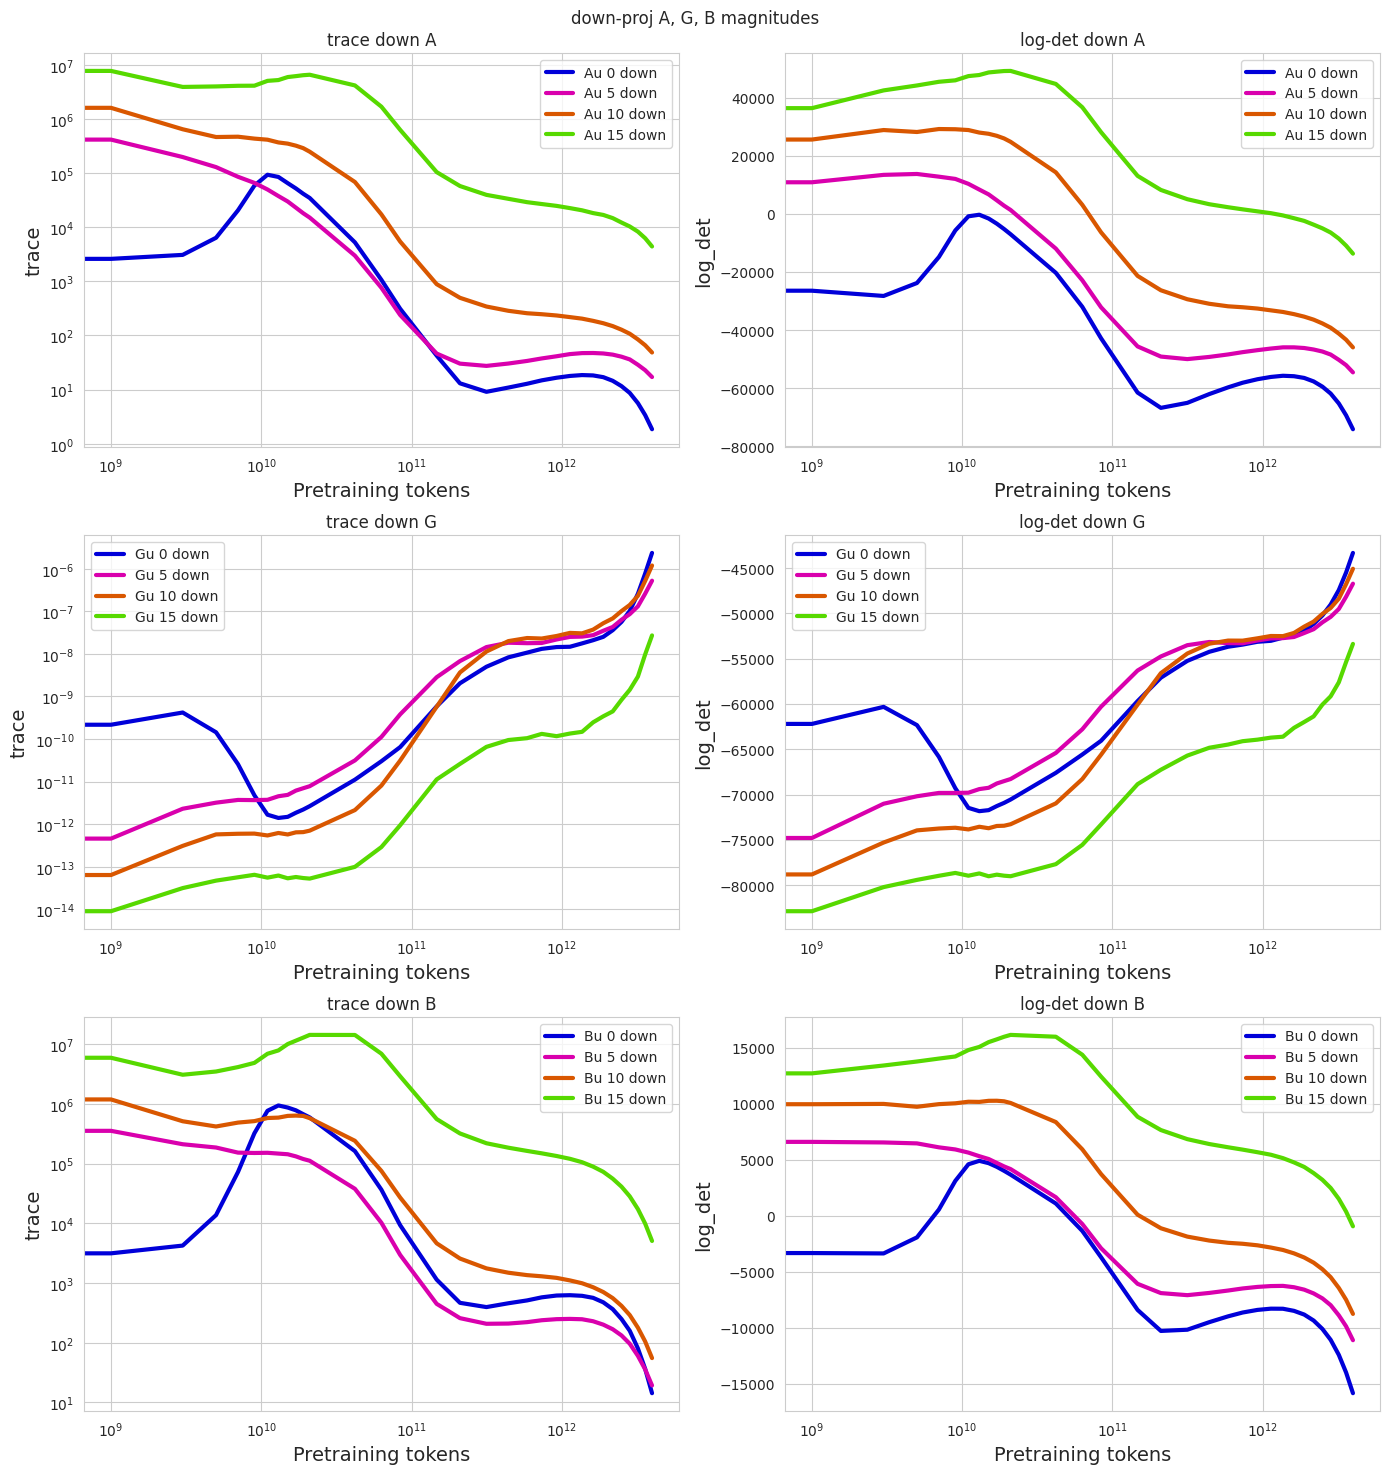

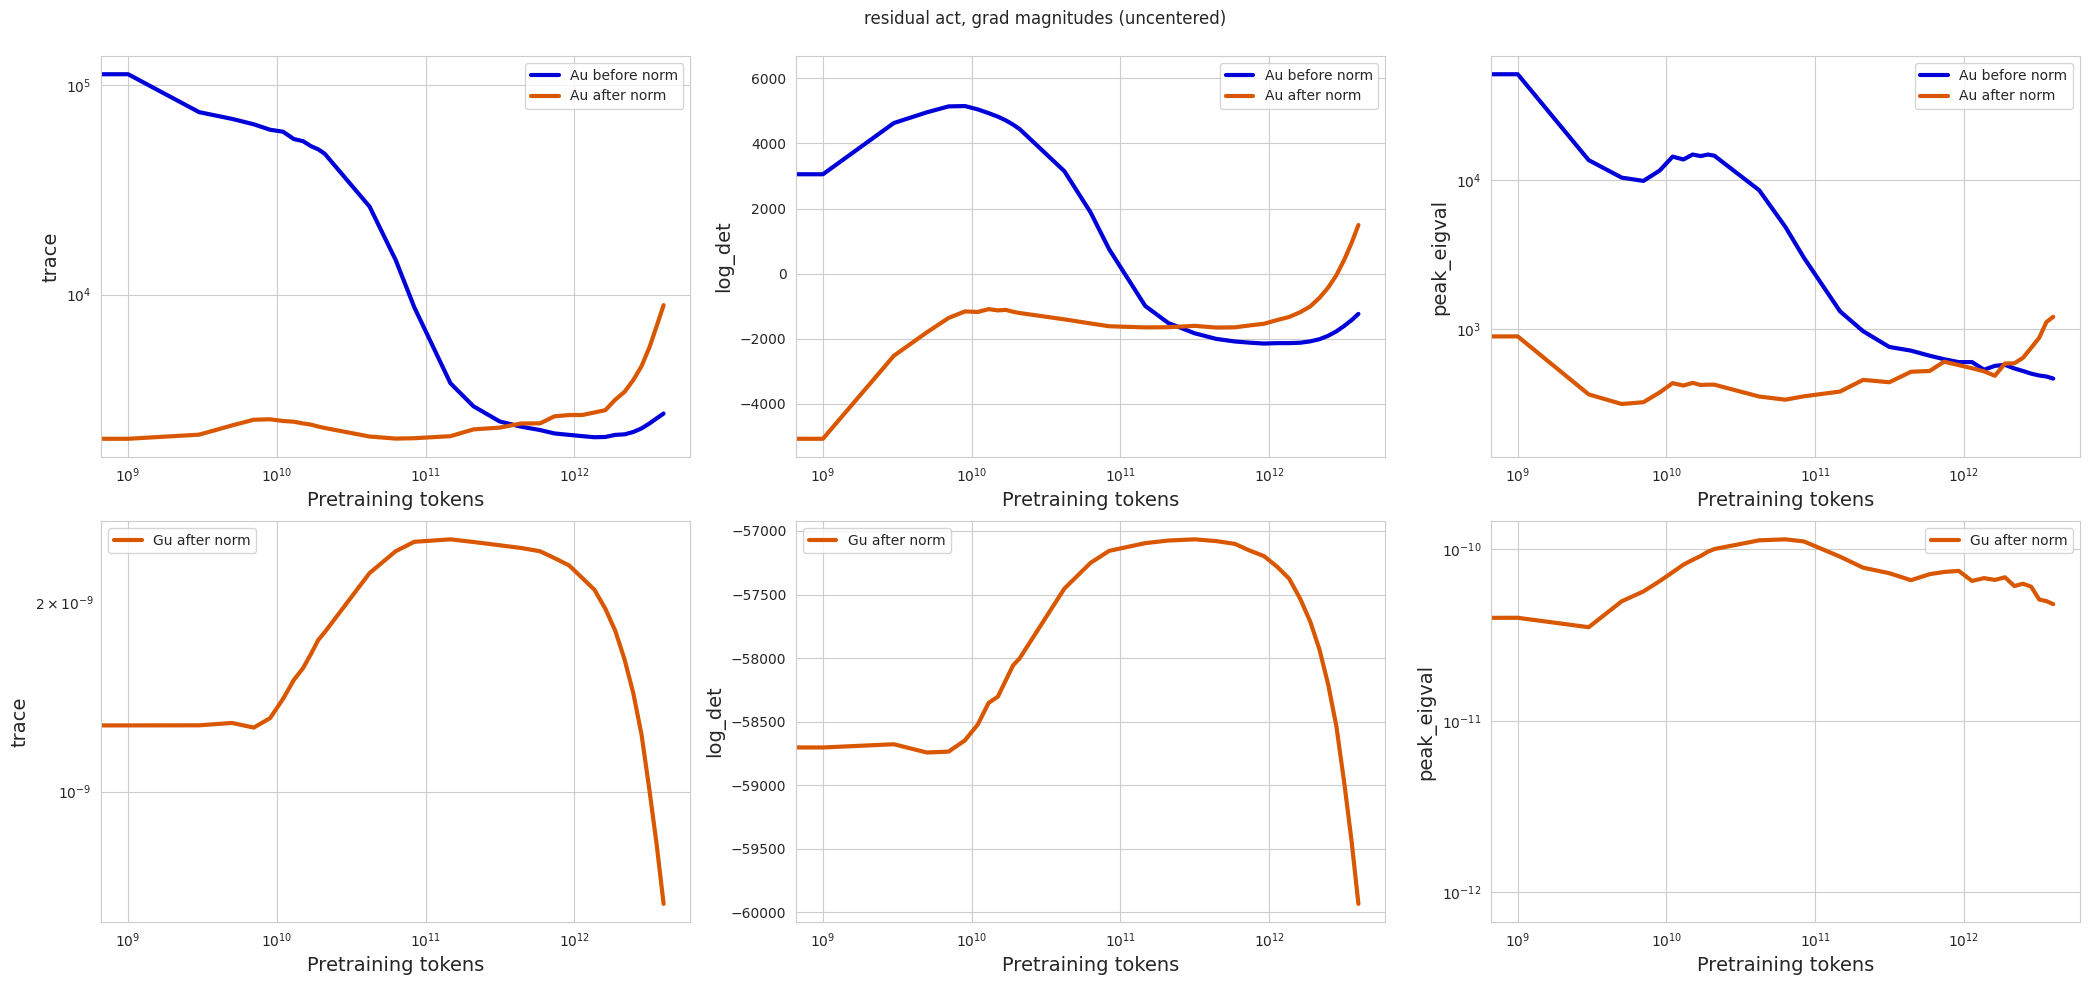

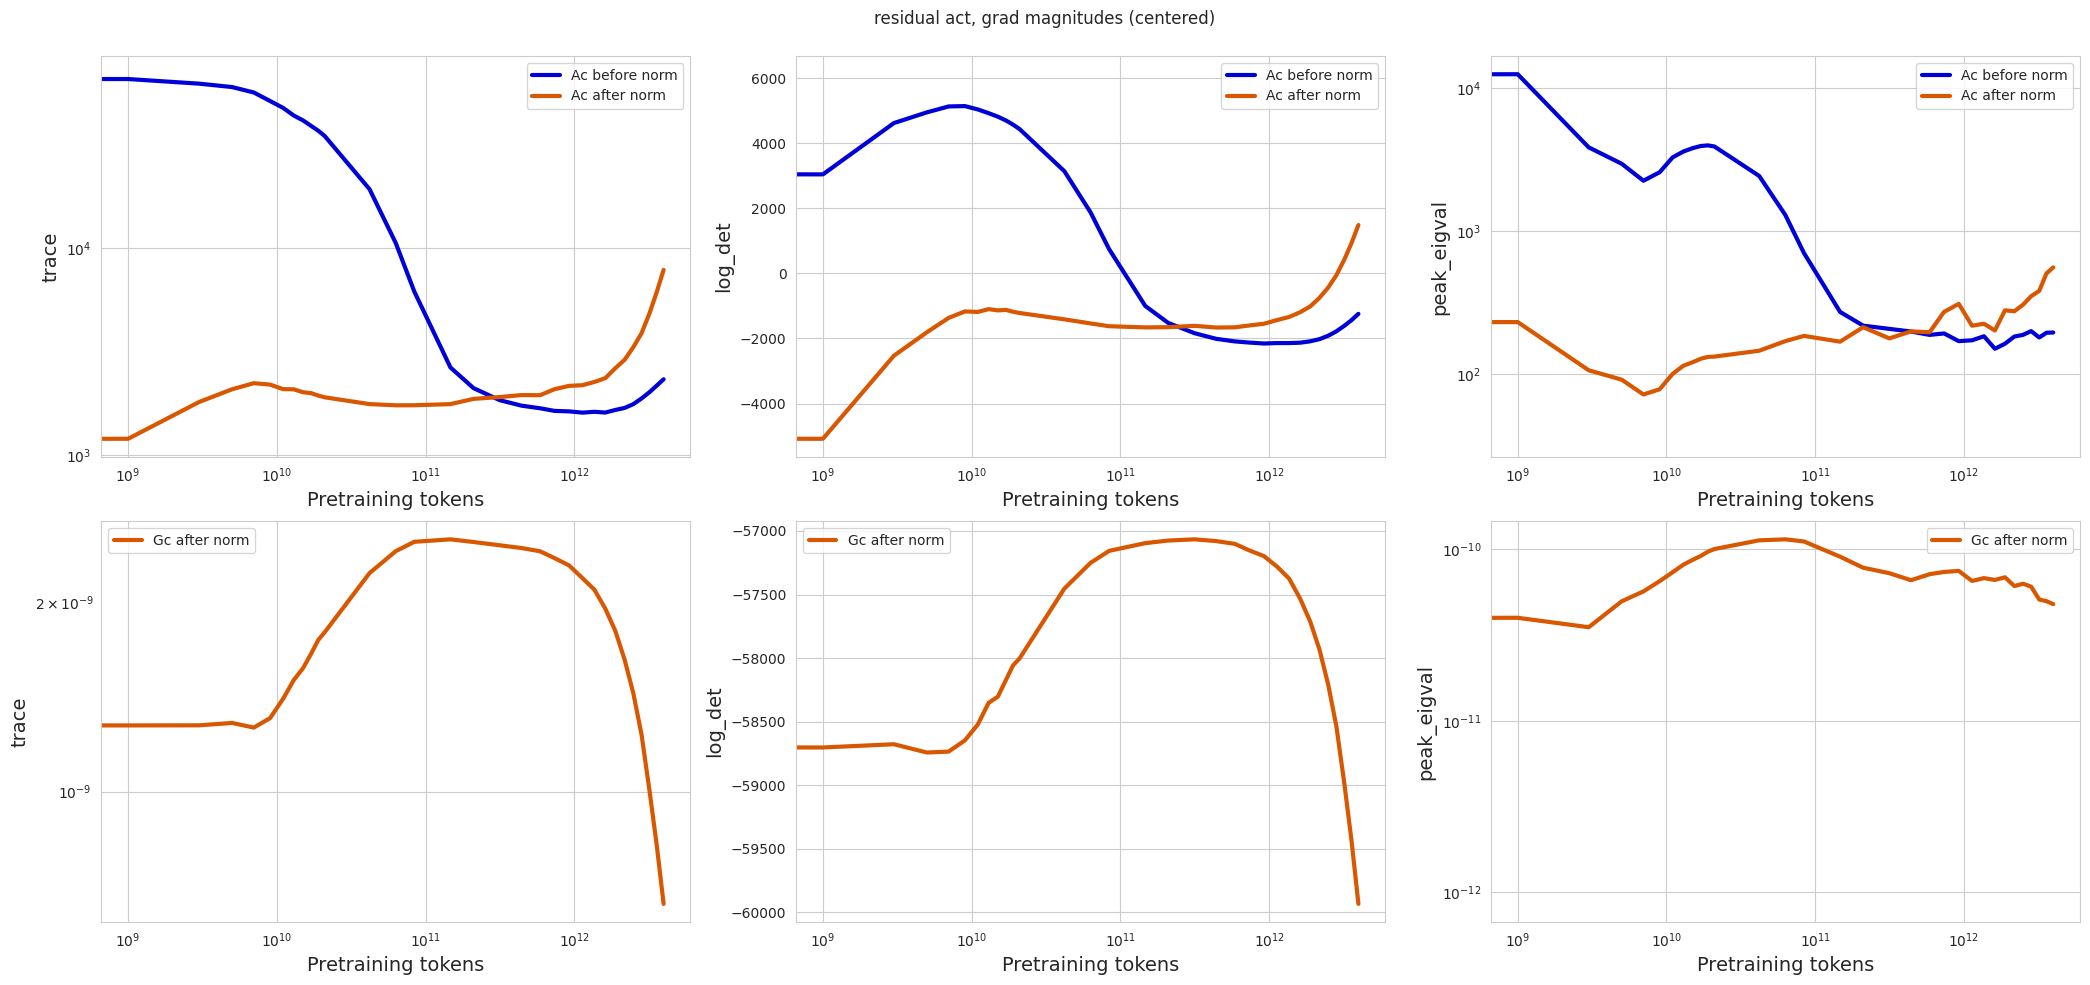

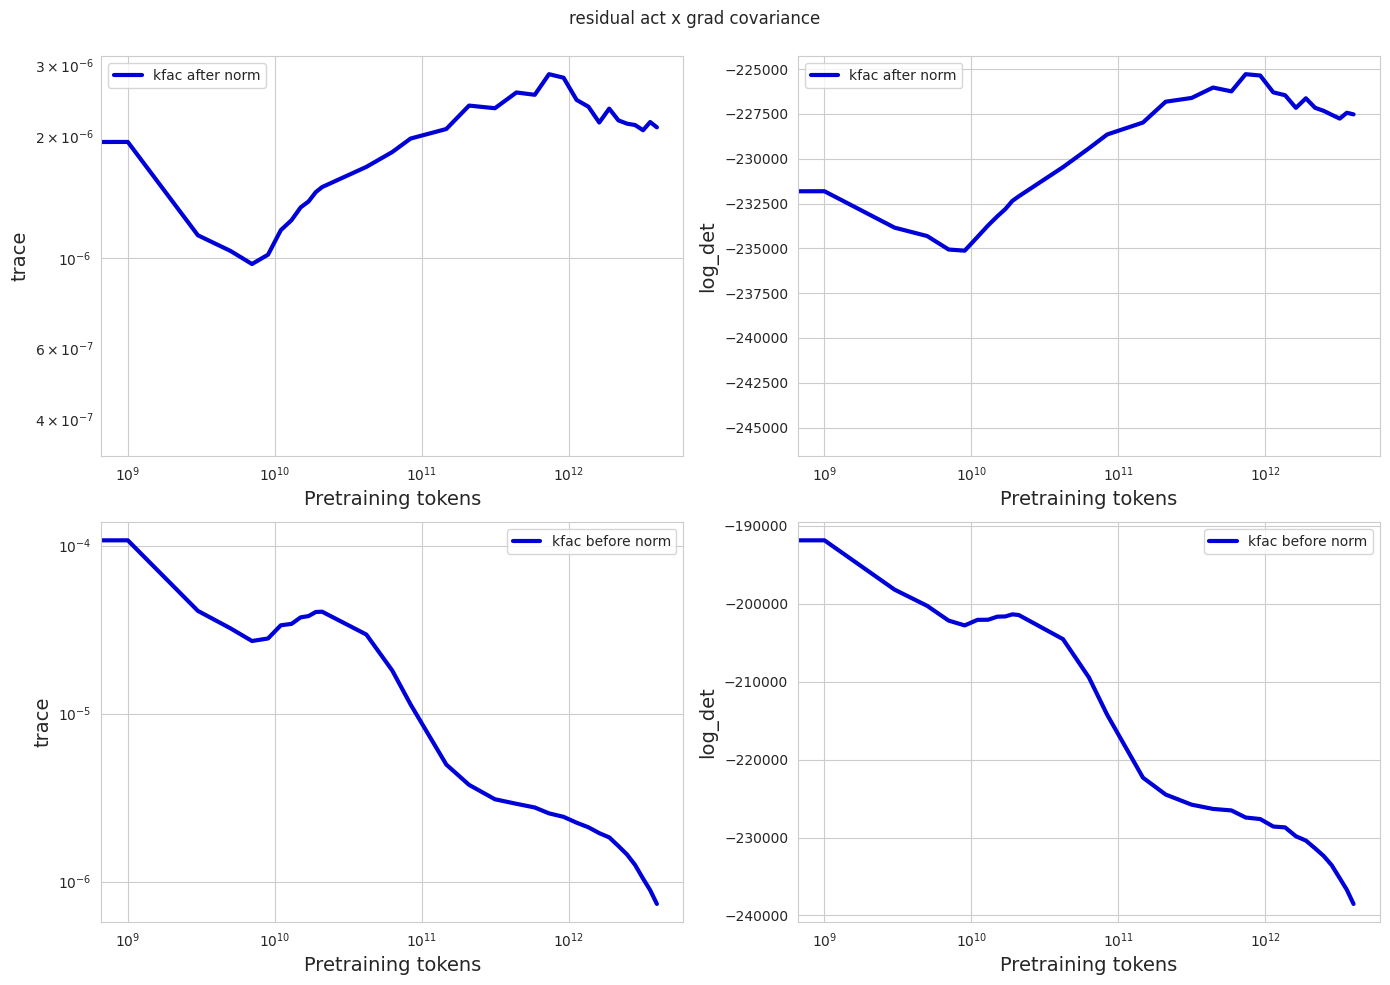

In [12]:
filter_model_names = [
    # 'pythia-14m-deduped',
    # 'pythia-31m-deduped',
    # 'pythia-70m-deduped',
    # 'pythia-160m-deduped',
    # 'pythia-410m-deduped',
    'pythia-1b-deduped',
    # 'pythia-1.4b-deduped',
    # 'pythia-2.8b-deduped',
    # 'pythia-6.9b-deduped',
    # 'pythia-12b-deduped',
    # 'pythia-14m',
    # 'pythia-31m',
    # 'pythia-70m',
    # 'pythia-160m',
    # 'pythia-410m',
    # 'pythia-1b',
    # 'pythia-1.4b',
    # 'pythia-2.8b',
    # 'pythia-6.9b',
    # 'pythia-12b',
    'OLMo-2-0425-1B',
    # 'OLMo-2-1124-7B',
]

data_sources_1 = [
#   Data File          Hook      Label
    (TRAINSET_PACKED,   AFN_AC,   'Trainset centered'),
    (TRAINSET_PACKED,   AFN_AU,   'Trainset uncentered'),
    (FINEWEB_PADDED,    AFN_AC,   'Fineweb  centered'),
    (FINEWEB_PADDED,    AFN_AU,   'Fineweb  uncentered'),
]

data_sources_2 = [
#   Data File          Hook      Label
    (TRAINSET_PACKED,   AFN_AC,   'Trainset'),
    (FINEWEB_PADDED,    AFN_AC,   'Fineweb'),
]
data_sources_3 = [
#   Data File          Hook      Label
    (KF_SMALL,   BFN_AC,   'Before final norm'),
    (KF_SMALL,   AFN_AC,   'After final norm'),
]
data_sources_4 = [
#   Data File          Hook      Label
    (TRAINSET_PACKED,  AFN_AC,   'id head'),
    (KF_SMALL,         AFN_AC,   'kfac run'),
]

wso = 'up', 'gate', 'down'
wsp = 'up', 'down'
ms = 'Ac', 'Au', 'Bc', 'Bu', 'Gc', 'Gu'

def mlp_(src):
    def mlp_src(ws, blks, ms):
        return [(src, globals()[f'{w[0].upper()}{l}_{m.upper()[:2]}'],
                 f'{m} {l} {w}')
                 for l in blks for w in ws for m in ms]
    return mlp_src

def res_(src):
    def res_src(pos, ms):
        return [(src, globals()[f'{p[0].upper()}FN_{m.upper()[:2]}'],
                 f'{m} {p}') for p in pos for m in ms]
    return res_src


mlp_rx = mlp_(KF_ARXIV)
mlp_ts = mlp_(KF_SMALL)
res_ts = res_(KF_SMALL)
mlp_ac_ = mlp_rx(wso, [14,15], ['Ac'])
mlp_au_ = mlp_rx(wso, [14,15], ['Au'])
mlp_bu_ = mlp_rx(wso, [14,15], ['Bu'])
mlp_gu_ = mlp_rx(wso, [14,15], ['Gu'])
mlp_kf_ = mlp_rx(['up', 'gate'], [14,15], ['kfac'])
mlp_kfd_ = mlp_rx(['down'], [14,15], ['kfac'])

mlp_ac = mlp_ts(wso, [0,5,10,15], ['Ac'])
mlp_bc = mlp_ts(wso, [0,5,10,15], ['Bc'])
mlp_gc = mlp_ts(wso, [0,5,10,15], ['Gc'])
mlp_au = mlp_ts(wso, [0,5,10,15], ['Au'])
mlp_bu = mlp_ts(wso, [0,5,10,15], ['Bu'])
mlp_gu = mlp_ts(wso, [0,5,10,15], ['Gu'])
mlp_kf = mlp_ts(['up', 'gate'], [0,5,10,15], ['kfac'])
mlp_kfu = mlp_ts(['up'], [0,5,10,15], ['kfac'])
mlp_kfd = mlp_ts(['down'], [0,5,10,15], ['kfac'])
mlp_kf0 = mlp_ts(['up', 'gate'], [0], ['kfac'])
mlp_kfd0 = mlp_ts(['down'], [0], ['kfac'])
mlp_kf15 = mlp_ts(['up', 'gate'], [15], ['kfac'])
mlp_kfd15 = mlp_ts(['down'], [15], ['kfac'])

mlp_lkf = mlp_ts(['layer'], [0,5,10,15], ['kfac'])

mlp_magu_u = mlp_ts(['up'], [0,5,10,15], ['Au', 'Bu', 'Gu'])
mlp_magu_c = mlp_ts(['up'], [0,5,10,15], ['Ac', 'Bc', 'Gc'])
mlp_magd_u = mlp_ts(['down'], [0,5,10,15], ['Au', 'Bu', 'Gu'])

res_bfn_u = res_ts(['before norm'], ['Au', 'Gu'])
res_bfn_c = res_ts(['before norm'], ['Ac', 'Gc'])
res_afn_u = res_ts(['after norm'], ['Au', 'Gu'])
res_afn_c = res_ts(['after norm'], ['Ac', 'Gc'])
res_fn_u = res_ts(['before norm', 'after norm'], ['Au', 'Gu'])
res_fn_c = res_ts(['before norm', 'after norm'], ['Ac', 'Gc'])

res_bfnk = res_ts(['before norm'], ['kfac'])
res_afnk = res_ts(['after norm'], ['kfac'])


####        #        #        #        #        #        #        ####
####     "Tracing the representation geometry.." reproduction     ####
####        #        #        #        #        #        #        ####
grid_start(ncols=2, title='RankMe reproductions')
plot_group('rankme', data_sources_1, ['OLMo-2-0425-1B'], title='OLMo-2 1B')
plot_group('alpha', data_sources_1, ['OLMo-2-0425-1B'], title='OLMo-2 1B')

plot_group('rankme', data_sources_1, ['pythia-1b-deduped'], title='Pythia 1B Deduped')
plot_group('alpha', data_sources_1, ['pythia-1b-deduped'], title='Pythia 1B Deduped')

plot_group('rankme', data_sources_2, filter_model_names, ls_exceptions={'Pythia':'--'})
plot_group('alpha', data_sources_2, filter_model_names, ls_exceptions={'Pythia':'--'})

plot_group('rankme', data_sources_4, ['OLMo-2-0425-1B'], ls_exceptions={'before':'--'})
plot_group('alpha', data_sources_4, ['OLMo-2-0425-1B'], ls_exceptions={'before':'--'})

plot_group('rankme', data_sources_3, ['OLMo-2-0425-1B'], ls_exceptions={'before':'--'})
plot_group('true_rankme', data_sources_3, ['OLMo-2-0425-1B'], ls_exceptions={'before':'--'})
plot_group('matrix_entropy', data_sources_3, ['OLMo-2-0425-1B'], ls_exceptions={'before':'--'})
plot_group('sv_entropy', data_sources_3, ['OLMo-2-0425-1B'], ls_exceptions={'before':'--'})
plot_group('alpha', data_sources_3, ['OLMo-2-0425-1B'], ls_exceptions={'before':'--'})
grid_show()


####        #        #        #        #        #        #        ####
####                          MLP RankMe                          ####
####        #        #        #        #        #        #        ####
grid_start(ncols=2, title='RankMe/Alpha-ReQ of MLPs (uncentered covariance)')
plot_group('rankme', mlp_au, ['OLMo-2-0425-1B'])
plot_group('alpha', mlp_au, ['OLMo-2-0425-1B'])
plot_group('rankme', mlp_bu, ['OLMo-2-0425-1B'])
plot_group('alpha', mlp_bu, ['OLMo-2-0425-1B'])
plot_group('rankme', mlp_gu, ['OLMo-2-0425-1B'])
plot_group('alpha', mlp_gu, ['OLMo-2-0425-1B'])
grid_show()

grid_start(ncols=2, title='RankMe/Alpha-ReQ of MLPs (centered covariance)')
plot_group('rankme', mlp_ac, ['OLMo-2-0425-1B'])
plot_group('alpha', mlp_ac, ['OLMo-2-0425-1B'])
plot_group('rankme', mlp_bc, ['OLMo-2-0425-1B'])
plot_group('alpha', mlp_bc, ['OLMo-2-0425-1B'])
plot_group('rankme', mlp_gc, ['OLMo-2-0425-1B'])
plot_group('alpha', mlp_gc, ['OLMo-2-0425-1B'])
grid_show()

# grid_start(ncols=2, title='Mean magnitudes (bias)')
# plot_group('mean', mlp_au, ['OLMo-2-0425-1B'])
# plot_group('mean', mlp_bu, ['OLMo-2-0425-1B'])
# plot_group('mean', mlp_gu, ['OLMo-2-0425-1B'])
# grid_show()




####        #        #        #        #        #        #        ####
####                          KFAC Stuff                          ####
####        #        #        #        #        #        #        ####
grid_start(ncols=2, title='up-proj kfac all layers')
plot_group('trace', mlp_kf[::2], ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_kf[::2], ['OLMo-2-0425-1B'])
plot_group('rankme', mlp_kf[::2], ['OLMo-2-0425-1B'])
plot_group('alpha', mlp_kf[::2], ['OLMo-2-0425-1B'])
grid_show()
grid_start(ncols=2, title='down-proj kfac all layers')
plot_group('trace', mlp_kfd, ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_kfd, ['OLMo-2-0425-1B'])
plot_group('rankme', mlp_kfd, ['OLMo-2-0425-1B'])
plot_group('alpha', mlp_kfd, ['OLMo-2-0425-1B'])
grid_show()

grid_start(ncols=2, title='kfac layer 0 up/gate')
plot_group('trace', mlp_kf0, ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_kf0, ['OLMo-2-0425-1B'])
plot_group('rankme', mlp_kf0, ['OLMo-2-0425-1B'])
plot_group('alpha', mlp_kf0, ['OLMo-2-0425-1B'])
plot_group('log_det_A', mlp_kf0, ['OLMo-2-0425-1B'])
plot_group('log_det_G', mlp_kf0, ['OLMo-2-0425-1B'])
plot_group('trace_A', mlp_kf0, ['OLMo-2-0425-1B'], ylog=True)
plot_group('trace_G', mlp_kf0, ['OLMo-2-0425-1B'], ylog=True)
grid_show()

grid_start(ncols=2, title='kfac layer 0 down')
plot_group('trace', mlp_kfd0, ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_kfd0, ['OLMo-2-0425-1B'])
plot_group('rankme', mlp_kfd0, ['OLMo-2-0425-1B'])
plot_group('alpha', mlp_kfd0, ['OLMo-2-0425-1B'])
plot_group('log_det_A', mlp_kf0, ['OLMo-2-0425-1B'])
plot_group('log_det_G', mlp_kf0, ['OLMo-2-0425-1B'])
plot_group('trace_A', mlp_kf0, ['OLMo-2-0425-1B'], ylog=True)
plot_group('trace_G', mlp_kf0, ['OLMo-2-0425-1B'], ylog=True)
grid_show()


grid_start(ncols=2, title='kfac layer 15 up/gate')
plot_group('trace', mlp_kf15, ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_kf15, ['OLMo-2-0425-1B'])
plot_group('rankme', mlp_kf15, ['OLMo-2-0425-1B'])
plot_group('peak_eigval', mlp_kf15, ['OLMo-2-0425-1B'], ylog=True)
grid_show()

grid_start(ncols=2, title='kfac layer 15 down')
plot_group('trace', mlp_kfd15, ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_kfd15, ['OLMo-2-0425-1B'])
plot_group('rankme', mlp_kfd15, ['OLMo-2-0425-1B'])
plot_group('peak_eigval', mlp_kfd15, ['OLMo-2-0425-1B'], ylog=True)
grid_show()

grid_start(ncols=2, title='up-proj inputs')
# plot_group('trace', mlp_au[::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_au[::3], ['OLMo-2-0425-1B'])
plot_group('peak_eigval', mlp_ac[::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('rankme', mlp_au[::3], ['OLMo-2-0425-1B'], title="uncentered covariance rankme")
plot_group('rankme', mlp_ac[::3], ['OLMo-2-0425-1B'], title="centered covariance rankme")
grid_show()

# # plot_group('trace', mlp_au[1::3], ['OLMo-2-0425-1B'], ylog=True)
# plot_group('log_det', mlp_au[1::3], ['OLMo-2-0425-1B'])
# plot_group('peak_eigval', mlp_ac[1::3], ['OLMo-2-0425-1B'], ylog=True)
# plot_group('rankme', mlp_au[1::3], ['OLMo-2-0425-1B'], title="uncentered covariance rankme")
# plot_group('rankme', mlp_ac[1::3], ['OLMo-2-0425-1B'], title="centered covariance rankme")

# plot_group('trace', mlp_au[2::3], ['OLMo-2-0425-1B'], ylog=True)
grid_start(ncols=2, title='down-proj inputs')
plot_group('log_det', mlp_au[2::3], ['OLMo-2-0425-1B'])
plot_group('peak_eigval', mlp_ac[2::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('rankme', mlp_au[2::3], ['OLMo-2-0425-1B'], title="uncentered covariance rankme")
plot_group('rankme', mlp_ac[2::3], ['OLMo-2-0425-1B'], title="centered covariance rankme")
grid_show()


grid_start(ncols=2, title='up-proj outputs')
# plot_group('trace', mlp_bu[::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_bu[::3], ['OLMo-2-0425-1B'])
plot_group('peak_eigval', mlp_bc[::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('rankme', mlp_bu[::3], ['OLMo-2-0425-1B'], title="uncentered covariance rankme")
plot_group('rankme', mlp_bc[::3], ['OLMo-2-0425-1B'], title="centered covariance rankme")
grid_show()

grid_start(ncols=2, title='gate-proj outputs')
# plot_group('trace', mlp_bu[1::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_bu[1::3], ['OLMo-2-0425-1B'])
plot_group('peak_eigval', mlp_bc[1::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('rankme', mlp_bu[1::3], ['OLMo-2-0425-1B'], title="uncentered covariance rankme")
plot_group('rankme', mlp_bc[1::3], ['OLMo-2-0425-1B'], title="centered covariance rankme")
grid_show()

grid_start(ncols=2, title='down-proj outputs')
# plot_group('trace', mlp_bu[2::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_bu[2::3], ['OLMo-2-0425-1B'])
plot_group('peak_eigval', mlp_bc[2::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('rankme', mlp_bu[2::3], ['OLMo-2-0425-1B'], title="uncentered covariance rankme")
plot_group('rankme', mlp_bc[2::3], ['OLMo-2-0425-1B'], title="centered covariance rankme")
grid_show()

grid_start(ncols=2, title='up-proj sampled gradients (loss wrt model\'s own samples)',
           disable_didx=[0]) # omit l0 bc it's too noisy
# plot_group('trace', mlp_gu[::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_gu[::3], ['OLMo-2-0425-1B'])
plot_group('peak_eigval', mlp_gc[::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('rankme', mlp_gu[::3], ['OLMo-2-0425-1B'], title="uncentered covariance rankme")
plot_group('rankme', mlp_gc[::3], ['OLMo-2-0425-1B'], title="centered covariance rankme")
grid_show()

grid_start(ncols=2, title='gate-proj sampled gradients (loss wrt model\'s own samples)',
           disable_didx=[0]) # omit l0 bc it's too noisy
# plot_group('trace', mlp_gu[1::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_gu[1::3], ['OLMo-2-0425-1B'])
plot_group('peak_eigval', mlp_gc[1::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('rankme', mlp_gu[1::3], ['OLMo-2-0425-1B'], title="uncentered covariance rankme")
plot_group('rankme', mlp_gc[1::3], ['OLMo-2-0425-1B'], title="centered covariance rankme")
grid_show()

grid_start(ncols=2, title='down-proj sampled gradients (loss wrt model\'s own samples)',
           disable_didx=[0]) # omit l0 bc it's too noisy
# plot_group('trace', mlp_gu[2::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_gu[2::3], ['OLMo-2-0425-1B'])
plot_group('peak_eigval', mlp_gc[2::3], ['OLMo-2-0425-1B'], ylog=True)
plot_group('rankme', mlp_gu[2::3], ['OLMo-2-0425-1B'], title="uncentered covariance rankme")
plot_group('rankme', mlp_gc[2::3], ['OLMo-2-0425-1B'], title="centered covariance rankme")
grid_show()

grid_start(ncols=2, title='"Whole layer K-FAC" up A x down G')
plot_group('trace', mlp_lkf, ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_lkf, ['OLMo-2-0425-1B'])
plot_group('rankme', mlp_lkf, ['OLMo-2-0425-1B'])
plot_group('alpha', mlp_lkf, ['OLMo-2-0425-1B'])
grid_show()


grid_start(ncols=2, title='kfac all layers down-proj')
plot_group('trace', mlp_kfd, ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', mlp_kfd, ['OLMo-2-0425-1B'])
plot_group('rankme', mlp_kfd, ['OLMo-2-0425-1B'])
plot_group('alpha', mlp_kfd, ['OLMo-2-0425-1B'])
grid_show()


####        #        #        #        #        #        #        ####
####                          Magnitudes                          ####
####        #        #        #        #        #        #        ####
# grid_start(ncols=2, title='up-proj A and G magnitudes')
# plot_group('trace_A', mlp_kf, ['OLMo-2-0425-1B'], ylog=True)
# plot_group('trace_G', mlp_kf, ['OLMo-2-0425-1B'], ylog=True)
# plot_group('log_det_A', mlp_kf, ['OLMo-2-0425-1B'])
# plot_group('log_det_G', mlp_kf, ['OLMo-2-0425-1B'])
# grid_show()

grid_start(ncols=2, title='up-proj A, G, B magnitudes')
plot_group('trace', mlp_magu_u[::3], ['OLMo-2-0425-1B'], title='trace up A', ylog=True)
plot_group('log_det', mlp_magu_u[::3], ['OLMo-2-0425-1B'], title='log-det up A')
plot_group('trace', mlp_magu_u[2::3], ['OLMo-2-0425-1B'], title='trace up G', ylog=True)
plot_group('log_det', mlp_magu_u[2::3], ['OLMo-2-0425-1B'], title='log-det up G')
plot_group('trace', mlp_magu_u[1::3], ['OLMo-2-0425-1B'], title='trace up B', ylog=True)
plot_group('log_det', mlp_magu_u[1::3], ['OLMo-2-0425-1B'], title='log-det up B')

# plot_group('trace', mlp_magu_c[::3], ['OLMo-2-0425-1B'], title='trace up Ac', ylog=True)
# plot_group('log_det', mlp_magu_c[::3], ['OLMo-2-0425-1B'], title='log-det up Ac')
# plot_group('trace', mlp_magu_c[1::3], ['OLMo-2-0425-1B'], title='trace up Bc', ylog=True)
# plot_group('log_det', mlp_magu_c[1::3], ['OLMo-2-0425-1B'], title='log-det up Bc')
# plot_group('trace', mlp_magu_c[2::3], ['OLMo-2-0425-1B'], title='trace up Gc', ylog=True)
# plot_group('log_det', mlp_magu_c[2::3], ['OLMo-2-0425-1B'], title='log-det up Gc')
grid_show()

grid_start(ncols=2, title='down-proj A, G, B magnitudes')
plot_group('trace', mlp_magd_u[::3], ['OLMo-2-0425-1B'], title='trace down A', ylog=True)
plot_group('log_det', mlp_magd_u[::3], ['OLMo-2-0425-1B'], title='log-det down A')
plot_group('trace', mlp_magd_u[2::3], ['OLMo-2-0425-1B'], title='trace down G', ylog=True)
plot_group('log_det', mlp_magd_u[2::3], ['OLMo-2-0425-1B'], title='log-det down G')
plot_group('trace', mlp_magd_u[1::3], ['OLMo-2-0425-1B'], title='trace down B', ylog=True)
plot_group('log_det', mlp_magd_u[1::3], ['OLMo-2-0425-1B'], title='log-det down B')
grid_show()


grid_start(ncols=3, title='residual act, grad magnitudes (uncentered)')
plot_group('trace', res_fn_u[::2], ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', res_fn_u[::2], ['OLMo-2-0425-1B'])
plot_group('peak_eigval', res_fn_u[::2], ['OLMo-2-0425-1B'], ylog=True)
plot_group('trace', res_fn_u[1::2], ['OLMo-2-0425-1B'], ylog=True, disable_didx=[0])
plot_group('log_det', res_fn_u[1::2], ['OLMo-2-0425-1B'], disable_didx=[0])
plot_group('peak_eigval', res_fn_u[1::2], ['OLMo-2-0425-1B'], ylog=True, disable_didx=[0])
grid_show()

grid_start(ncols=3, title='residual act, grad magnitudes (centered)')
plot_group('trace', res_fn_c[::2], ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', res_fn_c[::2], ['OLMo-2-0425-1B'])
plot_group('peak_eigval', res_fn_c[::2], ['OLMo-2-0425-1B'], ylog=True)
plot_group('trace', res_fn_c[1::2], ['OLMo-2-0425-1B'], ylog=True, disable_didx=[0])
plot_group('log_det', res_fn_c[1::2], ['OLMo-2-0425-1B'], disable_didx=[0])
plot_group('peak_eigval', res_fn_c[1::2], ['OLMo-2-0425-1B'], ylog=True, disable_didx=[0])
grid_show()

grid_start(ncols=2, title='residual act x grad covariance')
plot_group('trace', res_afnk, ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', res_afnk, ['OLMo-2-0425-1B'])
plot_group('trace', res_bfnk, ['OLMo-2-0425-1B'], ylog=True)
plot_group('log_det', res_bfnk, ['OLMo-2-0425-1B'])
grid_show()


